# Análisis Exploratorio de Datos (EDA)
Este EDA tiene como propósito comprender la estructura, calidad y características del conjunto de datos para sustentar tres objetivos investigativos:

1. **Objetivo 1:** Analizar la relación entre la marca/modelo del vehículo y la gravedad del accidente para identificar patrones de riesgo.
2. **Objetivo 2:** Evaluar los factores asociados a la edad del vehículo y su relación con la gravedad del accidente.
3. **Objetivo 3:** Identificar la concentración espacial y los patrones temporales (semanal, mensual y anual) de los siniestros en Colombia.

El análisis sigue la siguiente estructura:
1. Carga y exploración inicial
2. Calidad de datos (nulos, tipos, duplicados)
3. Tratamiento de datos (imputación, outliers, filtros)
4. Ingeniería de variables derivadas
5. Distribuciones univariadas
6. Análisis bivariado (variable a variable con la gravedad)
7. Análisis temporal
8. Análisis geográfico
9. Análisis inferencial (pruebas estadísticas formales)
10. Conclusiones, limitaciones y preparación para modelado

---
## 1. Carga y exploración inicial

### 1.1 Librerías

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import scipy.stats as stats
from itertools import combinations
from statsmodels.stats.proportion import proportion_confint

plt.style.use('ggplot')
%matplotlib inline
sns.set_palette("Blues")
import warnings
warnings.filterwarnings("ignore")

### 1.2 Carga del dataset

In [19]:
df = pd.read_csv(
    'VEHICULOS_INVOLUCRADOS_EN_UN_ACCIDENTE_DE_TRANSITO_LEY_2251-2022_20260205.csv',
    encoding='latin-1'
)
print(f"Dimensiones del dataset: {df.shape[0]:,} registros × {df.shape[1]} variables")
df.head()

Dimensiones del dataset: 406,540 registros × 9 variables


,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO
0,HONDA,2017,MOTOCICLETA,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
1,CHEVROLET,2007,CAMION,20.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
2,JEEP,2017,CAMPERO,9.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
3,CHEVROLET,2023,CAMIONETA,2.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA
4,HONDA,2026,MOTOCICLETA,1.0,12/2025,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406540 entries, 0 to 406539
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   MARCA_VEHICULO          406496 non-null  object
 1   MODELO_VEHICULO         406540 non-null  int64 
 2   TIPO_VEHICULO           406540 non-null  object
 3   EDAD_VEHICULO           406520 non-null  object
 4   FECHA_ACCIDENTE         406540 non-null  object
 5   GRAVEDAD_ACCIDENTE      406540 non-null  object
 6   DEPARTAMENTO_ACCIDENTE  406540 non-null  object
 7   MUNICIPIO_ACCIDENTE     406540 non-null  object
 8   AUTORIDAD_DE_TRANSITO   406540 non-null  object
dtypes: int64(1), object(8)
memory usage: 27.9+ MB


El dataset cuenta con **406,540 registros** y **9 variables**. Cada registro representa un vehículo involucrado en un accidente, no un accidente como evento único.

La mayoría de las variables son de tipo `object` (categóricas), pero para las variables `EDAD_VEHICULO` y `MODELO_VEHICULO` están cargadas como `object` pero deberían ser numéricas.

La variable `FECHA_ACCIDENTE` está en formato texto y debe convertirse a `datetime`.

Y se detectan valores faltantes en `MARCA_VEHICULO` y `EDAD_VEHICULO` que se analizarán en detalle.

**Nota:** El hecho de que la unidad de análisis sea el *vehículo* y no el *accidente* implica que un choque entre tres vehículos genera tres registros independientes. Esto es una limitación estructural del dataset que debe tenerse en cuenta al interpretar los conteos.

In [21]:
# Corrección de tipos de datos
df['EDAD_VEHICULO']   = pd.to_numeric(df['EDAD_VEHICULO'],   errors='coerce')
df['MODELO_VEHICULO'] = pd.to_numeric(df['MODELO_VEHICULO'], errors='coerce')
df['FECHA_ACCIDENTE'] = pd.to_datetime('01/' + df['FECHA_ACCIDENTE'], format='%d/%m/%Y')

print("Tipos de datos corregidos:")
print(df[['EDAD_VEHICULO','MODELO_VEHICULO','FECHA_ACCIDENTE']].dtypes)

Tipos de datos corregidos:
EDAD_VEHICULO             float64
MODELO_VEHICULO             int64
FECHA_ACCIDENTE    datetime64[ns]
dtype: object


In [22]:
df.describe()

,MODELO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE
count,406540.000000,406519.000000,406540
mean,2015.587573,10.465449,2023-10-07 08:50:42.015054080
min,1937.000000,0.000000,2022-01-01 00:00:00
25%,2012.000000,5.000000,2022-11-01 00:00:00
50%,2017.000000,9.000000,2023-10-01 00:00:00
75%,2021.000000,14.000000,2024-07-01 00:00:00
max,2027.000000,126.000000,2026-02-01 00:00:00
std,7.817606,7.461105,NaN


En `MODELO_VEHICULO` vemos que va de **1937 a 2027** — hay años futuros e históricos extremos que son errores de registro. 
En `EDAD_VEHICULO` alcanza **126 años**, físicamente imposible en el contexto vial colombiano.

La **media de edad** es ≈10.5 años y la mediana es 9 años, indicando que la mitad de los vehículos accidentados tienen menos de 9 años.

---
## 2. Calidad de datos

### 2.1 Valores nulos

In [23]:
# Resumen de nulos
def resumen_nulos(df):
    total = df.isnull().sum()
    pct   = (total / len(df)) * 100
    return pd.DataFrame({'Nulos': total, 'Porcentaje (%)': pct.round(4)}).query('Nulos > 0')

resumen_nulos(df)

,Nulos,Porcentaje (%)
MARCA_VEHICULO,44,0.0108
EDAD_VEHICULO,21,0.0052


In [24]:
# Patrón de nulos por tipo de vehículo
nulos_por_tipo = df.isnull().groupby(df['TIPO_VEHICULO']).sum()
print("Nulos en MARCA_VEHICULO y EDAD_VEHICULO por tipo de vehículo:")
print(nulos_por_tipo[['MARCA_VEHICULO', 'EDAD_VEHICULO']].query('MARCA_VEHICULO > 0 or EDAD_VEHICULO > 0'))

Nulos en MARCA_VEHICULO y EDAD_VEHICULO por tipo de vehículo:
                 MARCA_VEHICULO  EDAD_VEHICULO
TIPO_VEHICULO                                 
AUTOMOVIL                     0              5
CAMIONETA                     0              3
CARGADOR                      3              0
COMPACTADOR                   1              0
EXCAVADORA                    2              0
FRESADORA                     2              0
MINICARGADOR                  3              0
MONTACARGAS                   8              0
MOTOCICLETA                   0             13
MOTONIVELADORA                1              0
PAVIMENTADORA                 1              0
REMOLQUE                      1              0
RETROEXCAVADORA               5              0
SEMIREMOLQUE                  1              0
TRACTOR                      16              0


Los nulos en `MARCA_VEHICULO` (0.01%) se concentran exclusivamente en tipos como TRACTOR, MONTACARGAS y RETROEXCAVADORA. Estos vehículos de maquinaria industrial no tienen una "marca comercial" estándar en el registro de tránsito, por lo que el valor faltante es **estructural, no un error de captura**. La estrategia es rellenar con `"Sin información"`.

Los nulos en `EDAD_VEHICULO` (0.005%) aparecen en MOTOCICLETA, AUTOMÓVIL y CAMIONETA, lo que sugiere omisión en la digitación o ausencia del campo `MODELO_VEHICULO` que sirve para calcularla. La estrategia es **imputar con la mediana por tipo de vehículo** (ver Sección 3).

### 2.2 Duplicados

In [25]:
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados:,} ({duplicados/len(df)*100:.4f}%)")

Registros duplicados: 147,575 (36.3002%)


### 2.3 Distribución de la variable objetivo

In [26]:
print("Distribución de GRAVEDAD_ACCIDENTE:")
g = df['GRAVEDAD_ACCIDENTE'].value_counts()
for cat, cnt in g.items():
    print(f"  {cat:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")

Distribución de GRAVEDAD_ACCIDENTE:
  CON HERIDOS             385,881  (94.92%)
  CON MUERTOS              20,659  (5.08%)


**La variable objetivo presenta desbalanceo de clases:** CON HERIDOS representa ~95% y CON MUERTOS ~5%. Esto es análogo al problema descrito en el paper portugués de referencia (Sustainable Road Safety, 2025) y deberá considerarse en el modelado predictivo mediante técnicas como SMOTE, ponderación de clases o submuestreo.

---
## 3. Tratamiento de datos

### 3.1 Imputación de valores nulos

In [27]:
# MARCA_VEHICULO: nulos estructurales → "Sin información"
df['MARCA_VEHICULO'] = df['MARCA_VEHICULO'].fillna("Sin información")

# EDAD_VEHICULO: imputar con mediana por TIPO_VEHICULO
# Justificación: diferentes tipos de vehículo tienen distribuciones de edad muy distintas.
# Una mediana global introduciría sesgo (ej. la edad típica de una moto ≠ la de un camión).
df['EDAD_VEHICULO'] = df.groupby('TIPO_VEHICULO')['EDAD_VEHICULO'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback global para tipos con todos los valores nulos
df['EDAD_VEHICULO'] = df['EDAD_VEHICULO'].fillna(df['EDAD_VEHICULO'].median())

print("Nulos después de imputación:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos después de imputación:
Series([], dtype: int64)


### 3.2 Detección y tratamiento de outliers

**EDAD_VEHICULO**

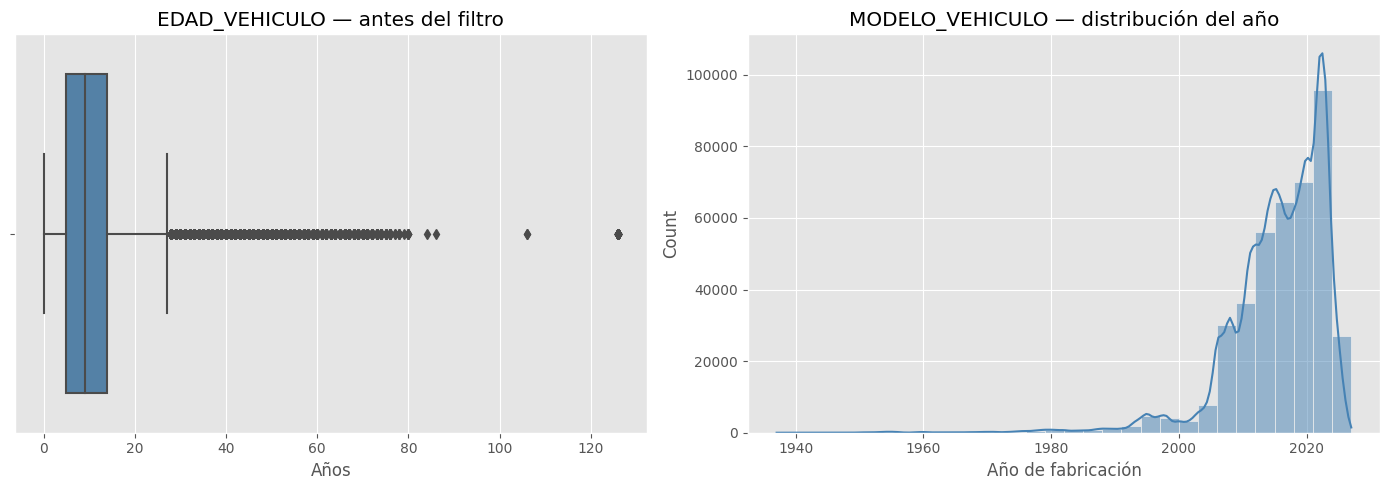

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['EDAD_VEHICULO'], ax=axes[0], color='steelblue')
axes[0].set_title('EDAD_VEHICULO — antes del filtro')
axes[0].set_xlabel('Años')

sns.histplot(df['MODELO_VEHICULO'], bins=30, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('MODELO_VEHICULO — distribución del año')
axes[1].set_xlabel('Año de fabricación')

plt.tight_layout()
plt.show()

En la variable `EDAD_VEHICULO` muestra valores de hasta 126 años — físicamente imposibles.
En `MODELO_VEHICULO` presenta años anteriores a 1940 (errores de digitación) y años de 2026-2027 (la fecha más reciente del dataset es diciembre de 2025, por lo que esos modelos son inválidos).

Es posible que existan vehículos clásicos de colección en circulación, pero los registros de las décadas de 1930-1940 son sospechosos de error de captura. Se establece **1950 como límite inferior** para `MODELO_VEHICULO`.

Para `EDAD_VEHICULO` se aplica un **cap de 60 años**, umbral que cubre incluso los vehículos de colección más longevos que razonablemente circulan.

In [29]:
antes = len(df)

# Filtros de MODELO_VEHICULO
df = df[(df['MODELO_VEHICULO'] >= 1950) & (df['MODELO_VEHICULO'] <= 2025)]
print(f"Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: {antes - len(df):,}")

# Cap de EDAD_VEHICULO
antes2 = len(df)
df = df[df['EDAD_VEHICULO'] <= 60]
print(f"Eliminados por EDAD_VEHICULO > 60 años: {antes2 - len(df):,}")
print(f"Registros restantes: {len(df):,}")

Eliminados por MODELO_VEHICULO fuera de [1950, 2025]: 2,964
Eliminados por EDAD_VEHICULO > 60 años: 449
Registros restantes: 403,127


### 3.3 Filtros de calidad temporal

Se identificaron dos problemas de calidad en la dimensión temporal que requieren tratamiento antes del análisis:

In [30]:
# Extraer componentes temporales (necesarios para los filtros)
df['AÑO']      = df['FECHA_ACCIDENTE'].dt.year
df['MES']      = df['FECHA_ACCIDENTE'].dt.month
df['MES_NOMBRE'] = df['FECHA_ACCIDENTE'].dt.month_name()
df['TRIMESTRE']  = df['FECHA_ACCIDENTE'].dt.quarter
df['SEMESTRE']   = df['FECHA_ACCIDENTE'].apply(lambda x: 1 if x.month <= 6 else 2)
df['DIA_SEMANA'] = df['FECHA_ACCIDENTE'].dt.day_name()  # Para análisis semanal (Objetivo 3)

print("Componentes temporales extraídos correctamente.")
print(df[['FECHA_ACCIDENTE','AÑO','MES','DIA_SEMANA']].head(3))

Componentes temporales extraídos correctamente.
  FECHA_ACCIDENTE   AÑO  MES DIA_SEMANA
0      2025-12-01  2025   12     Monday
1      2025-12-01  2025   12     Monday
2      2025-12-01  2025   12     Monday


In [31]:
# ── Filtro 1: Excluir 2026 (año incompleto, distorsiona tasas de mortalidad) ──
df = df[df['AÑO'] <= 2025]
print(f"Registros tras excluir 2026: {len(df):,}")

# ── Filtro 2: Excluir anomalía julio 2024 ──
# El 78.7% de los 28,794 registros de julio 2024 provienen de un único reportante
# ('STRIA DE TTOyTTE MEDELLIN'), con una tasa de mortalidad que cayó de 4.24% a 1.38%
# mientras el volumen se triplicaba — relación inversa incompatible con un fenómeno real.
# Conclusión: error de carga masiva de registros.
mascara_anomalia = ~(
    (df['AÑO'] == 2024) &
    (df['MES'] == 7) &
    (df['AUTORIDAD_DE_TRANSITO'] == 'STRIA DE TTOyTTE MEDELLIN')
)
antes = len(df)
df = df[mascara_anomalia]
print(f"Eliminados por anomalía julio 2024: {antes - len(df):,}")
print(f"Dataset final para análisis: {len(df):,} registros")

Registros tras excluir 2026: 401,137
Eliminados por anomalía julio 2024: 22,667
Dataset final para análisis: 378,470 registros


---
## 4. Variables derivadas

Se crean nuevas variables que enriquecen el análisis y son relevantes para los tres objetivos.

In [32]:
# ── Objetivo 1: MODELO_ESPECIFICO (marca + año de fabricación) ──
# La marca sola tiene baja asociación con la gravedad (V de Cramér débil).
# Al combinarla con el año se captura la variación dentro de cada marca.
df['MODELO_ESPECIFICO'] = df['MARCA_VEHICULO'].astype(str) + ' ' + df['MODELO_VEHICULO'].astype(str)

# ── Objetivo 2: ANTIGÜEDAD_VEHICULO y su categorización ──
# ANTIGÜEDAD es el cálculo preciso desde el año del accidente,
# mientras que EDAD_VEHICULO es la variable original (con errores ya filtrados).
df['ANTIGÜEDAD_VEHICULO'] = df['FECHA_ACCIDENTE'].dt.year - df['MODELO_VEHICULO']

bins_edad   = [0, 5, 10, 20, float('inf')]
labels_edad = ['0-5 años', '6-10 años', '11-20 años', '>20 años']
df['CAT_EDAD_VEHICULO'] = pd.cut(df['ANTIGÜEDAD_VEHICULO'], bins=bins_edad, labels=labels_edad)

# ── Objetivo 3: Variables temporales adicionales ──
meses_vacaciones  = [1, 6, 7, 12]
meses_alto_riesgo = [7, 9, 3, 5]   # Basado en estacionalidad observada
df['ES_VACACIONES']     = df['MES'].isin(meses_vacaciones).astype(int)
df['ES_MES_ALTO_RIESGO'] = df['MES'].isin(meses_alto_riesgo).astype(int)

print("Variables derivadas creadas:")
print(f"  MODELO_ESPECIFICO   → {df['MODELO_ESPECIFICO'].nunique():,} combinaciones únicas")
print(f"  ANTIGÜEDAD_VEHICULO → media = {df['ANTIGÜEDAD_VEHICULO'].mean():.1f} años")
print(f"  CAT_EDAD_VEHICULO   → {df['CAT_EDAD_VEHICULO'].value_counts().to_dict()}")
print(f"  ES_VACACIONES       → {df['ES_VACACIONES'].sum():,} registros en períodos vacacionales")

Variables derivadas creadas:
  MODELO_ESPECIFICO   → 2,977 combinaciones únicas
  ANTIGÜEDAD_VEHICULO → media = 7.5 años
  CAT_EDAD_VEHICULO   → {'0-5 años': 128889, '6-10 años': 98880, '11-20 años': 82077, '>20 años': 18627}
  ES_VACACIONES       → 120,672 registros en períodos vacacionales


---
## 5. Distribuciones univariadas

Análisis de cada variable de forma individual, sin cruzar con la variable objetivo.

### 5.1 Variables categóricas

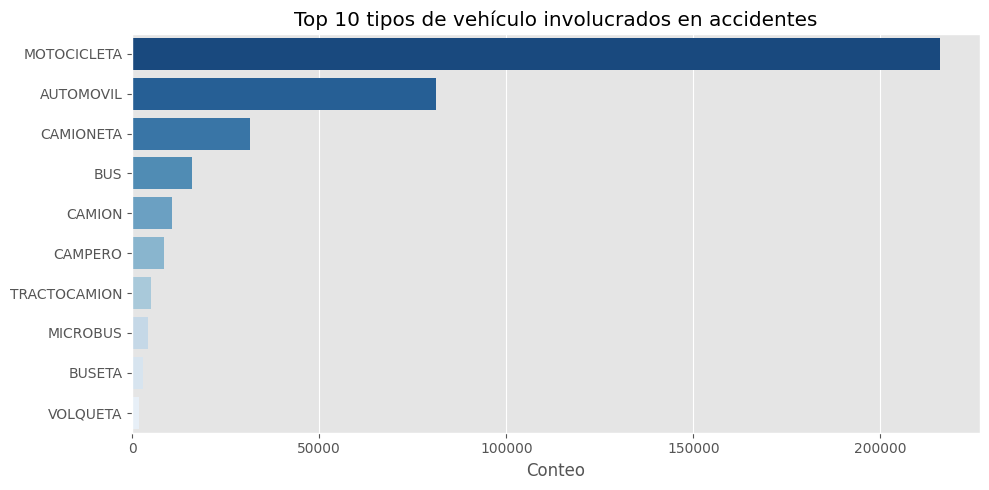

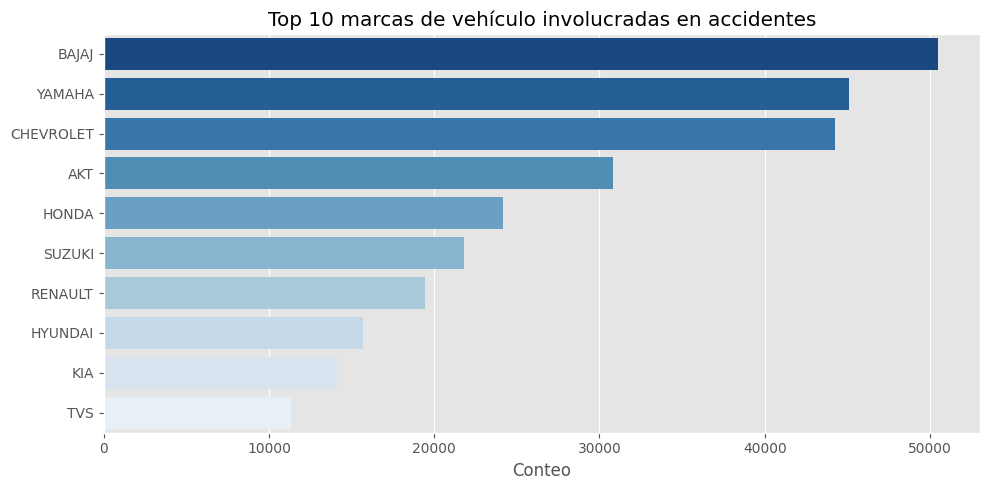

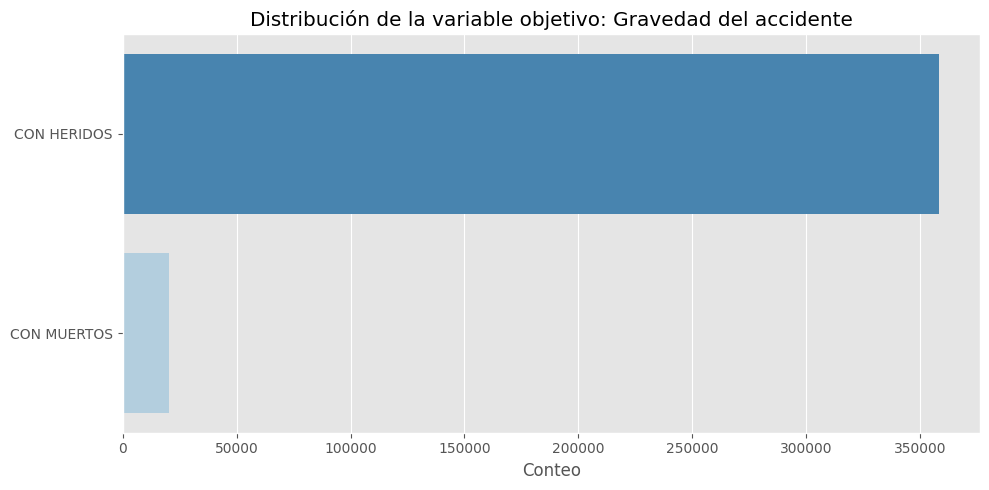

In [33]:
def distribucion_categorica(df, columna, top_n=None, titulo=None):
    if top_n:
        top_cats = df[columna].value_counts().nlargest(top_n).index
        data, order = df[df[columna].isin(top_cats)], top_cats
    else:
        data, order = df, df[columna].value_counts().index
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.countplot(data=data, y=columna, order=order, palette='Blues_r', ax=ax)
    ax.set_title(titulo or f'Distribución de {columna}')
    ax.set_xlabel('Conteo')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

distribucion_categorica(df, 'TIPO_VEHICULO', top_n=10, titulo='Top 10 tipos de vehículo involucrados en accidentes')
distribucion_categorica(df, 'MARCA_VEHICULO', top_n=10, titulo='Top 10 marcas de vehículo involucradas en accidentes')
distribucion_categorica(df, 'GRAVEDAD_ACCIDENTE', titulo='Distribución de la variable objetivo: Gravedad del accidente')

**Hallazgos univariados — categóricas:**
- **Tipo de vehículo:** Las motocicletas dominan con una cifra que supera la suma de los siguientes nueve tipos combinados. Automóviles y camionetas conforman el segundo y tercer lugar.
- **Marca:** El top 10 está liderado por marcas de motocicletas (BAJAJ, YAMAHA, AKT, HONDA, SUZUKI), seguidas por automóviles (CHEVROLET, RENAULT, HYUNDAI, KIA). Esta distribución refleja el parque automotor colombiano, no un riesgo inherente de la marca.
- **Variable objetivo:** Marcado desbalanceo — CON HERIDOS ~95%, CON MUERTOS ~5%. Este desbalanceo deberá manejarse en el modelado.

### 5.2 Variables numéricas

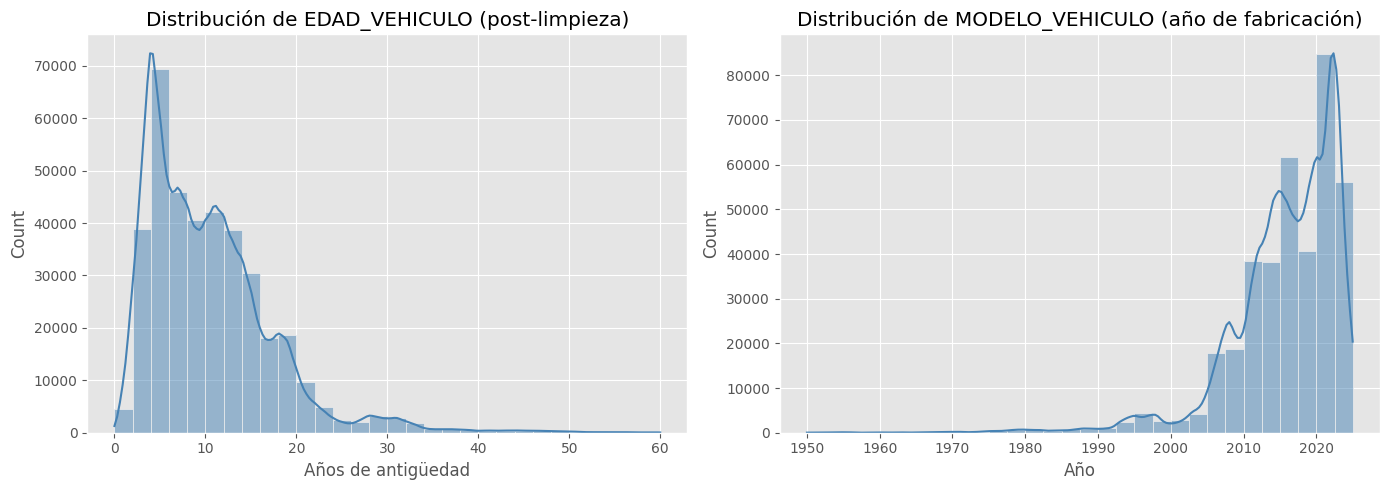

EDAD_VEHICULO  → Media: 10.3 años | Mediana: 9.0 años
MODELO_VEHICULO → Rango: 1950 – 2025


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# EDAD_VEHICULO (después del cap)
sns.histplot(df['EDAD_VEHICULO'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribución de EDAD_VEHICULO (post-limpieza)')
axes[0].set_xlabel('Años de antigüedad')

# MODELO_VEHICULO
sns.histplot(df['MODELO_VEHICULO'], bins=30, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('Distribución de MODELO_VEHICULO (año de fabricación)')
axes[1].set_xlabel('Año')

plt.tight_layout()
plt.show()

print(f"EDAD_VEHICULO  → Media: {df['EDAD_VEHICULO'].mean():.1f} años | Mediana: {df['EDAD_VEHICULO'].median():.1f} años")
print(f"MODELO_VEHICULO → Rango: {int(df['MODELO_VEHICULO'].min())} – {int(df['MODELO_VEHICULO'].max())}")

En `EDAD_VEHICULO` muestra una distribución con **sesgo positivo** (cola a la derecha): la mayoría de los vehículos involucrados en accidentes tienen entre 0 y 20 años.
Y en `MODELO_VEHICULO` concentra la masa entre 2005 y 2023, coherente con el parque automotor activo en Colombia.

---
## 6. Análisis bivariado

Cruce de cada variable explicativa con `GRAVEDAD_ACCIDENTE`. Esta sección sustenta directamente los tres objetivos.

### 6.1 Tipo de vehículo vs. Gravedad 

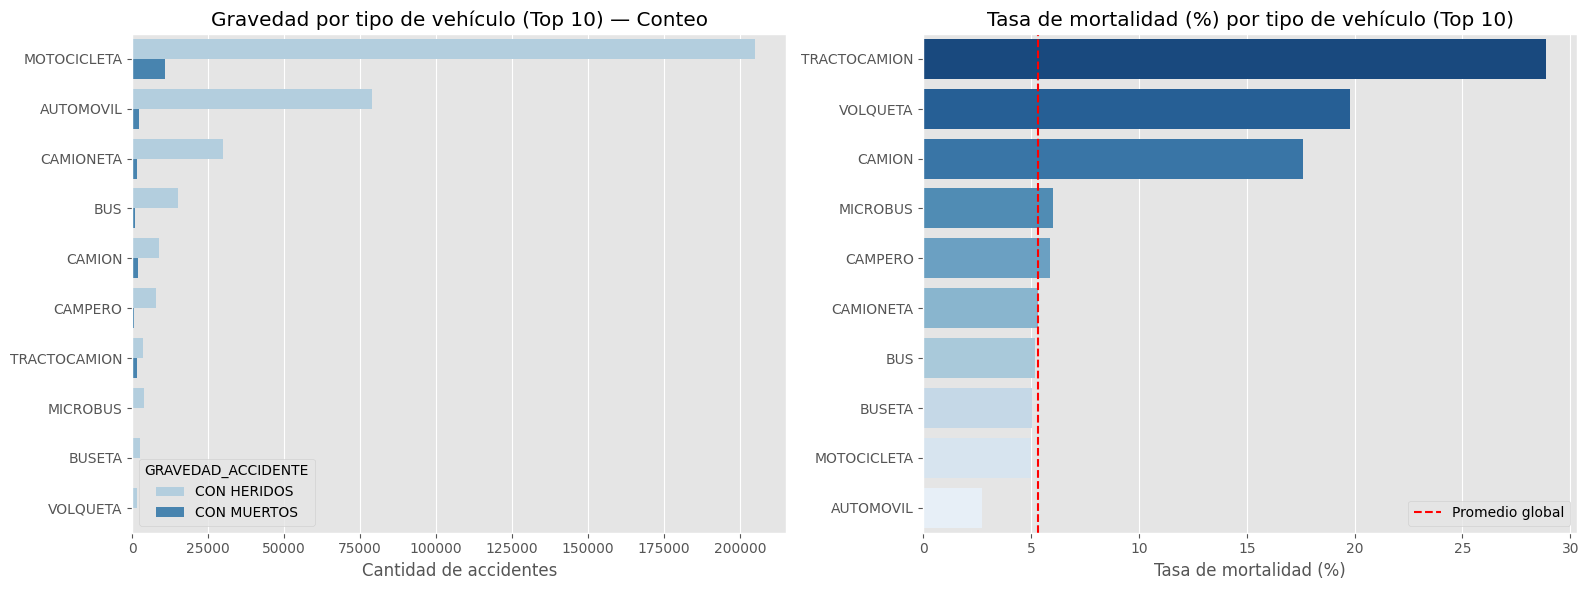

In [35]:
top_tipos = df['TIPO_VEHICULO'].value_counts().nlargest(10).index
df_tipos_top = df[df['TIPO_VEHICULO'].isin(top_tipos)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Conteo absoluto
sns.countplot(data=df_tipos_top, y='TIPO_VEHICULO', hue='GRAVEDAD_ACCIDENTE',
              order=top_tipos, palette='Blues', ax=axes[0])
axes[0].set_title('Gravedad por tipo de vehículo (Top 10) — Conteo')
axes[0].set_xlabel('Cantidad de accidentes')
axes[0].set_ylabel('')

# Tasa de mortalidad
tasa_tipo = df_tipos_top.groupby('TIPO_VEHICULO')['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reindex(top_tipos).sort_values(ascending=False)

sns.barplot(x=tasa_tipo.values, y=tasa_tipo.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Tasa de mortalidad (%) por tipo de vehículo (Top 10)')
axes[1].set_xlabel('Tasa de mortalidad (%)')
axes[1].set_ylabel('')
axes[1].axvline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.2 Marca y modelo vs. Gravedad

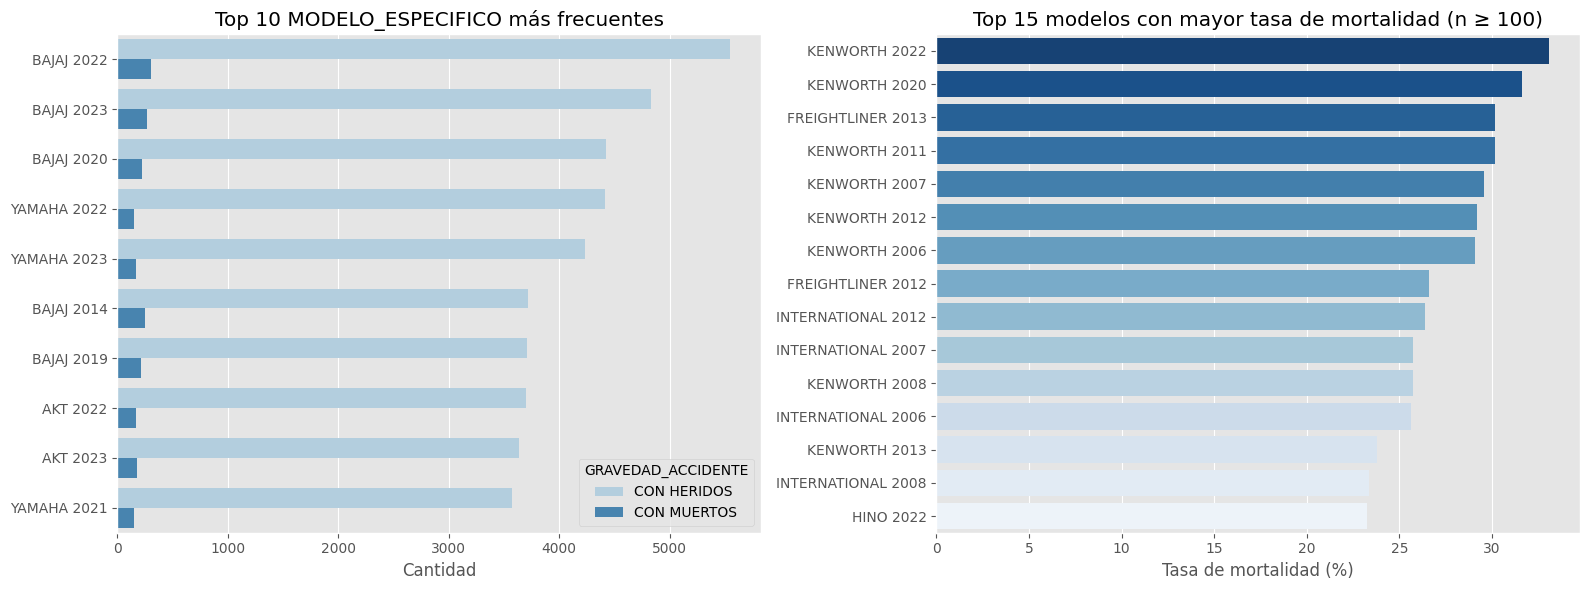

In [36]:
top_modelos = df['MODELO_ESPECIFICO'].value_counts().nlargest(10).index
df_modelos_top = df[df['MODELO_ESPECIFICO'].isin(top_modelos)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 modelos más frecuentes
sns.countplot(data=df_modelos_top, y='MODELO_ESPECIFICO', hue='GRAVEDAD_ACCIDENTE',
              order=top_modelos, palette='Blues', ax=axes[0])
axes[0].set_title('Top 10 MODELO_ESPECIFICO más frecuentes')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('')

# Top 20 modelos con mayor tasa de mortalidad (mínimo 100 registros)
tasa_modelos = df.groupby('MODELO_ESPECIFICO').agg(
    n=('GRAVEDAD_ACCIDENTE', 'count'),
    muertos=('GRAVEDAD_ACCIDENTE', lambda x: (x == 'CON MUERTOS').sum())
)
tasa_modelos['tasa'] = tasa_modelos['muertos'] / tasa_modelos['n'] * 100
top_letales = tasa_modelos[tasa_modelos['n'] >= 100].nlargest(15, 'tasa')

sns.barplot(x=top_letales['tasa'], y=top_letales.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 15 modelos con mayor tasa de mortalidad (n ≥ 100)')
axes[1].set_xlabel('Tasa de mortalidad (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

**Hallazgos relacionados con el Objetivo 1:**
- Los **vehículos de carga pesada** (volqueta, tractocamión, camión) presentan las tasas de mortalidad más altas, superando ampliamente el promedio global, a pesar de tener frecuencias bajas de accidentalidad.
- Las **motocicletas** son el tipo con mayor volumen absoluto de accidentes, pero su tasa de mortalidad es cercana al promedio global.
- Los **automóviles y camionetas** tienen frecuencias altas pero tasas de mortalidad relativamente bajas, posiblemente por mejores sistemas de seguridad pasiva (airbags, estructura).
- Los **10 modelos más frecuentes** son en su totalidad motocicletas (BAJAJ, YAMAHA, AKT) de años recientes (2018-2023), coherente con el parque de motos en Colombia.
- Los **modelos con mayor tasa de mortalidad** (con al menos 100 registros para garantizar confiabilidad estadística) corresponden a camiones y tractocamiones de marcas como KENWORTH, FREIGHTLINER e INTERNATIONAL, con tasas cercanas al 40%.
- Existe una **paradoja de volumen vs. letalidad**: los modelos más accidentados (motos) no son los más letales, y los más letales (carga pesada) no son los más frecuentes.

### 6.3 Edad del vehículo vs. Gravedad 

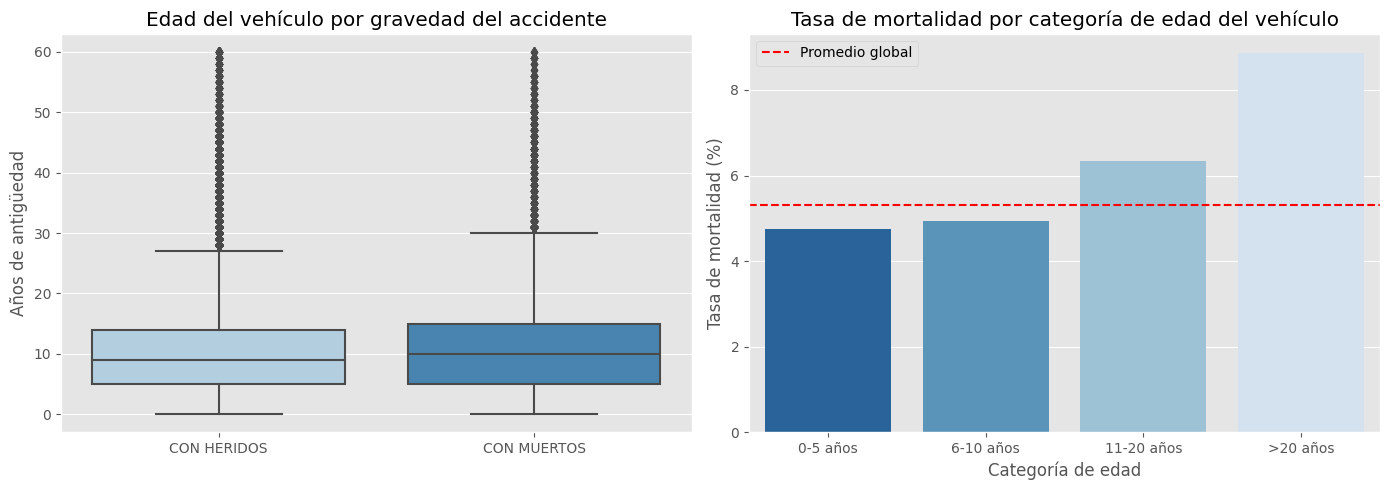

Estadísticas de EDAD_VEHICULO por GRAVEDAD_ACCIDENTE:
                     mean  median   std
GRAVEDAD_ACCIDENTE                     
CON HERIDOS         10.25     9.0  7.00
CON MUERTOS         11.55    10.0  8.55


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: EDAD_VEHICULO por gravedad
sns.boxplot(data=df, x='GRAVEDAD_ACCIDENTE', y='EDAD_VEHICULO',
            palette='Blues', ax=axes[0])
axes[0].set_title('Edad del vehículo por gravedad del accidente')
axes[0].set_xlabel('')
axes[0].set_ylabel('Años de antigüedad')

# Distribución por categoría de edad
tasa_cat = df.groupby('CAT_EDAD_VEHICULO', observed=True)['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reset_index()
tasa_cat.columns = ['Categoría', 'Tasa de mortalidad (%)']

sns.barplot(data=tasa_cat, x='Categoría', y='Tasa de mortalidad (%)',
            palette='Blues_r', ax=axes[1])
axes[1].set_title('Tasa de mortalidad por categoría de edad del vehículo')
axes[1].set_xlabel('Categoría de edad')
axes[1].axhline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadísticas descriptivas por grupo
print("Estadísticas de EDAD_VEHICULO por GRAVEDAD_ACCIDENTE:")
print(df.groupby('GRAVEDAD_ACCIDENTE')['EDAD_VEHICULO'].agg(['mean','median','std']).round(2))

**Hallazgos relacionados con el Objetivo 2:**
- Los vehículos en accidentes **fatales tienen una mediana de edad mayor** (≈11-12 años) que los de accidentes con heridos (≈9-10 años).
- La tasa de mortalidad **aumenta progresivamente con la antigüedad del vehículo**: los vehículos de más de 20 años tienen tasas notablemente superiores al promedio.
- Esto puede atribuirse a menor mantenimiento mecánico, ausencia de sistemas de seguridad modernos (ABS, airbags, asistencia de frenado) y mayor desgaste estructural.

### 6.4 Departamento y autoridad vs. Gravedad 

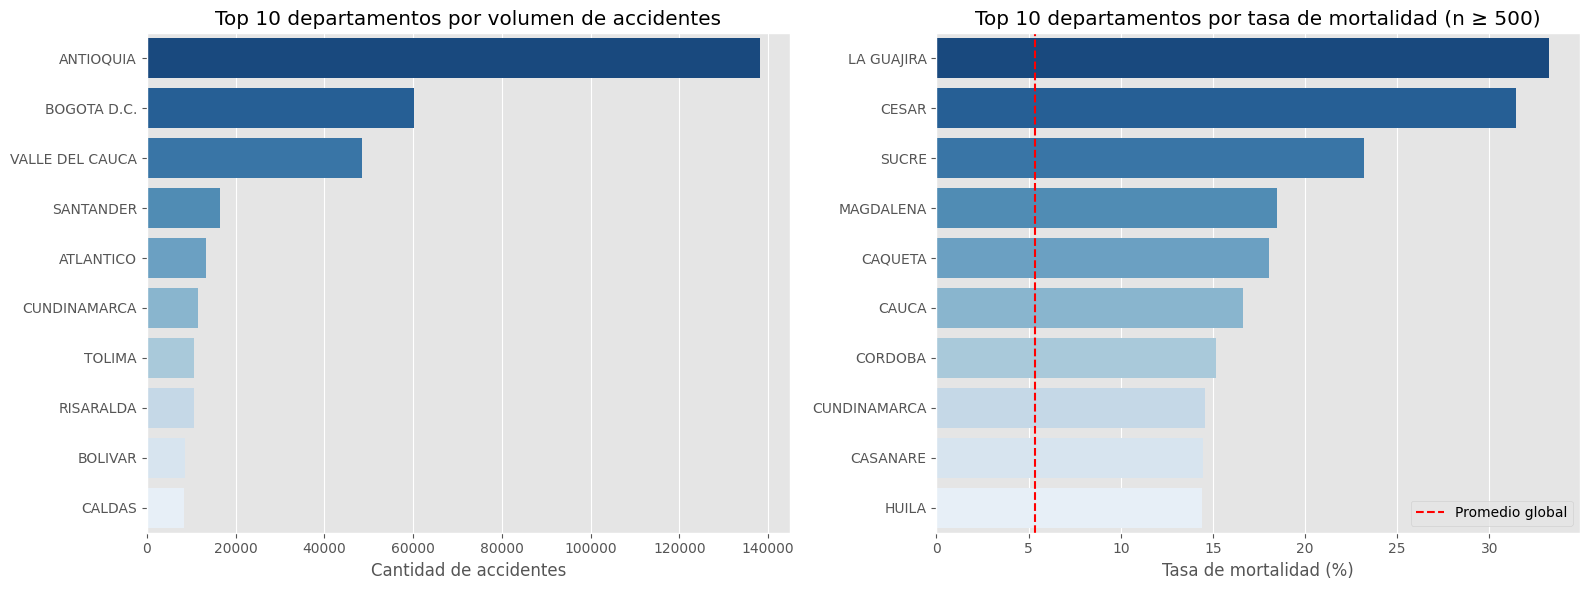

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 departamentos — volumen
top_dep = df['DEPARTAMENTO_ACCIDENTE'].value_counts().nlargest(10)
sns.barplot(x=top_dep.values, y=top_dep.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 departamentos por volumen de accidentes')
axes[0].set_xlabel('Cantidad de accidentes')
axes[0].set_ylabel('')

# Top 10 departamentos — tasa de mortalidad (mínimo 500 registros)
tasa_dep = df.groupby('DEPARTAMENTO_ACCIDENTE').agg(
    n=('GRAVEDAD_ACCIDENTE','count'),
    muertos=('GRAVEDAD_ACCIDENTE', lambda x: (x=='CON MUERTOS').sum())
)
tasa_dep['tasa'] = tasa_dep['muertos'] / tasa_dep['n'] * 100
top_dep_mort = tasa_dep[tasa_dep['n'] >= 500].nlargest(10, 'tasa')

sns.barplot(x=top_dep_mort['tasa'], y=top_dep_mort.index, palette='Blues_r', ax=axes[1])
axes[1].set_title('Top 10 departamentos por tasa de mortalidad (n ≥ 500)')
axes[1].set_xlabel('Tasa de mortalidad (%)')
axes[1].set_ylabel('')
axes[1].axvline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.show()

**Hallazgos relacionados con el Objetivo 3 (espacial):**
- **Antioquia, Bogotá y Valle del Cauca** concentran el mayor volumen de accidentes, coherente con su densidad poblacional y actividad vehicular.
- Pero **alta frecuencia ≠ alta mortalidad**: los departamentos periféricos y rurales (como los de la Orinoquía y la Amazonía) presentan las tasas de mortalidad más altas, posiblemente por mayor distancia a centros de atención médica y carreteras de mayor velocidad.
- Este contraste entre **volumen vs. letalidad** es el hallazgo geográfico clave del análisis.

---
## 7. Análisis temporal 

Se analiza la dimensión temporal en cuatro niveles: anual, mensual, por día de la semana y la interacción mes × año.

### 7.1 Evolución anual

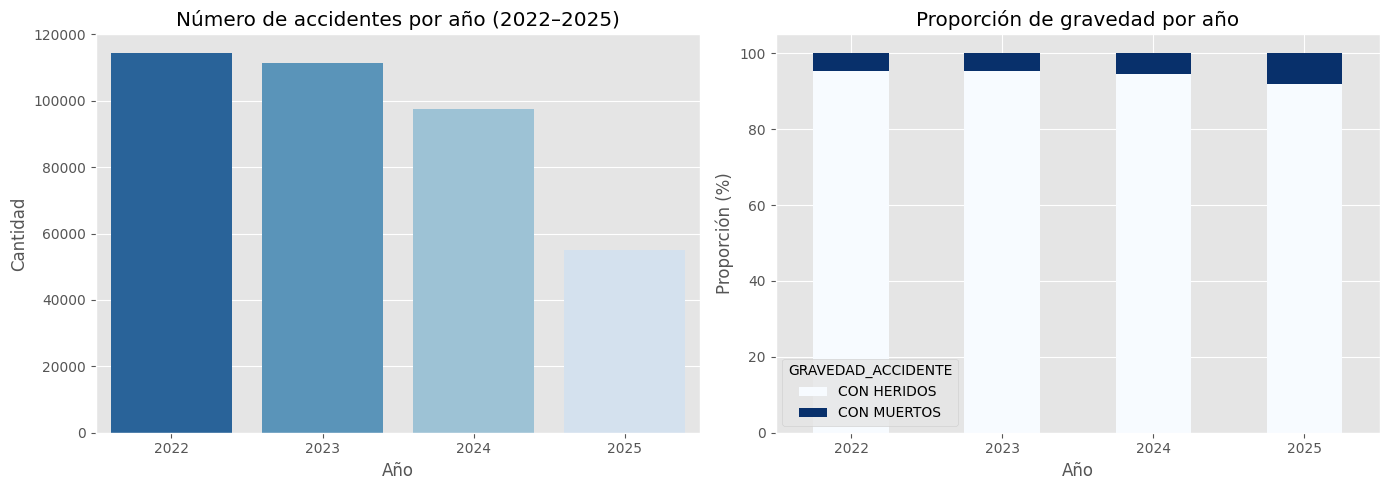

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por año
años_counts = df['AÑO'].value_counts().sort_index()
sns.barplot(x=años_counts.index, y=años_counts.values, palette='Blues_r', ax=axes[0])
axes[0].set_title('Número de accidentes por año (2022–2025)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Cantidad')

# Proporción de gravedad por año
tabla_años = pd.crosstab(df['AÑO'], df['GRAVEDAD_ACCIDENTE'], normalize='index') * 100
tabla_años.plot(kind='bar', stacked=True, colormap='Blues', ax=axes[1])
axes[1].set_title('Proporción de gravedad por año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Proporción (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 7.2 Estacionalidad mensual

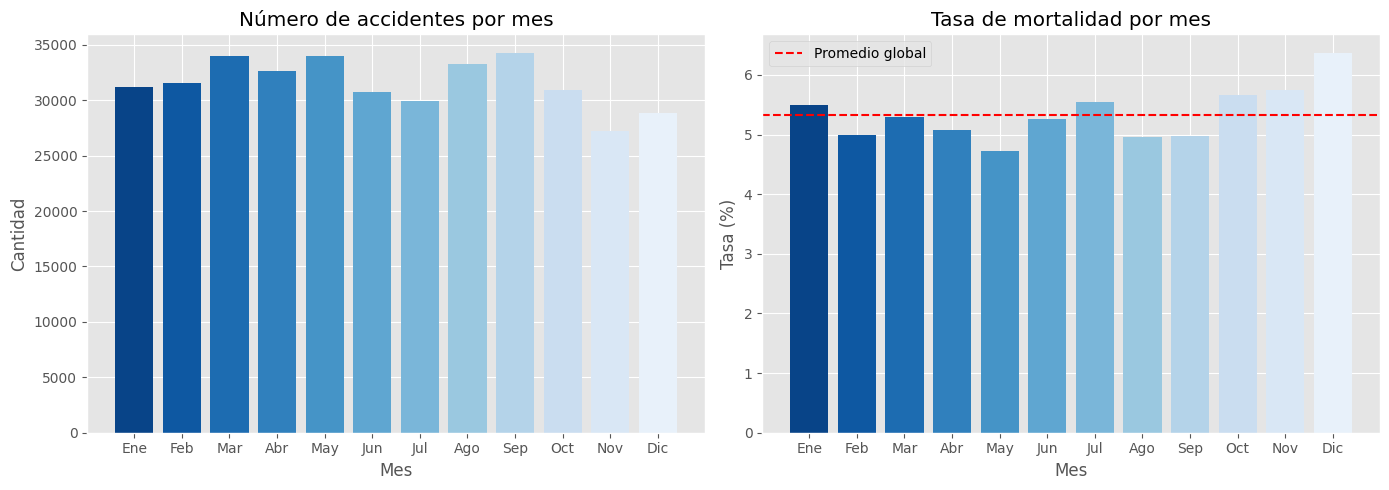

In [40]:
orden_meses = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
nombres_es  = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

meses_counts = df['MES_NOMBRE'].value_counts().reindex(orden_meses)
axes[0].bar(nombres_es, meses_counts.values, color=sns.color_palette('Blues_r', 12))
axes[0].set_title('Número de accidentes por mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Cantidad')

tasa_mes = df.groupby('MES_NOMBRE')['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reindex(orden_meses)
axes[1].bar(nombres_es, tasa_mes.values, color=sns.color_palette('Blues_r', 12))
axes[1].axhline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].set_title('Tasa de mortalidad por mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Tasa (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 7.3 Patrones semanales 

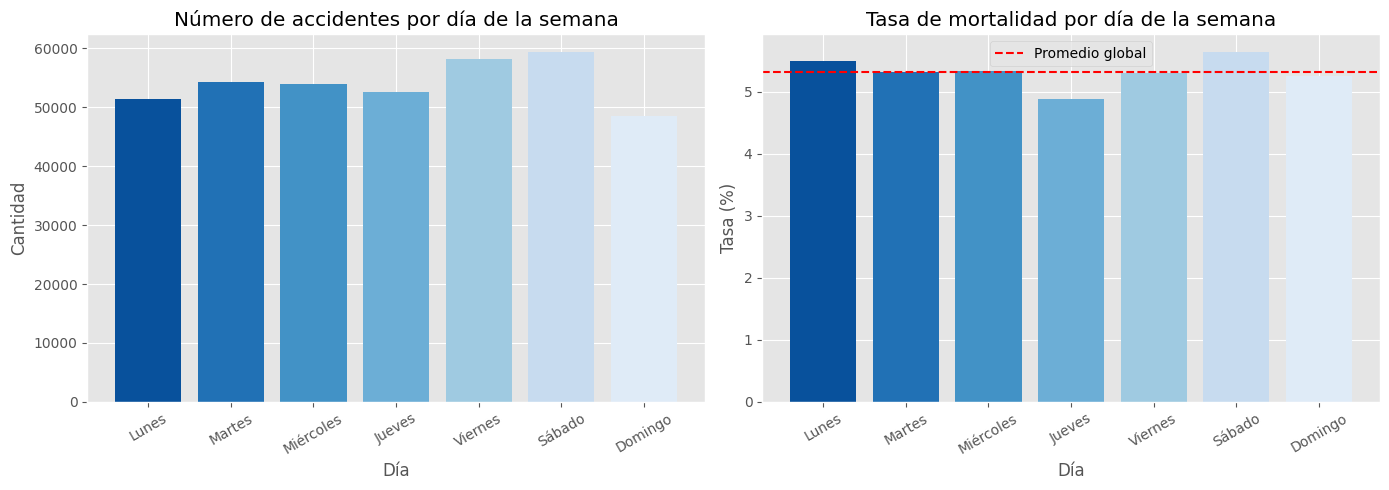

In [41]:
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nombres_dias_es = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dias_counts = df['DIA_SEMANA'].value_counts().reindex(orden_dias)
colores_dias = sns.color_palette('Blues_r', 7)
axes[0].bar(nombres_dias_es, dias_counts.values, color=colores_dias)
axes[0].set_title('Número de accidentes por día de la semana')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=30)

tasa_dia = df.groupby('DIA_SEMANA')['GRAVEDAD_ACCIDENTE'].apply(
    lambda x: (x == 'CON MUERTOS').mean() * 100
).reindex(orden_dias)
axes[1].bar(nombres_dias_es, tasa_dia.values, color=colores_dias)
axes[1].axhline(df['GRAVEDAD_ACCIDENTE'].eq('CON MUERTOS').mean()*100,
                color='red', linestyle='--', label='Promedio global')
axes[1].set_title('Tasa de mortalidad por día de la semana')
axes[1].set_xlabel('Día')
axes[1].set_ylabel('Tasa (%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 7.4 Heatmap mes × año y serie de tiempo por tipo de vehículo

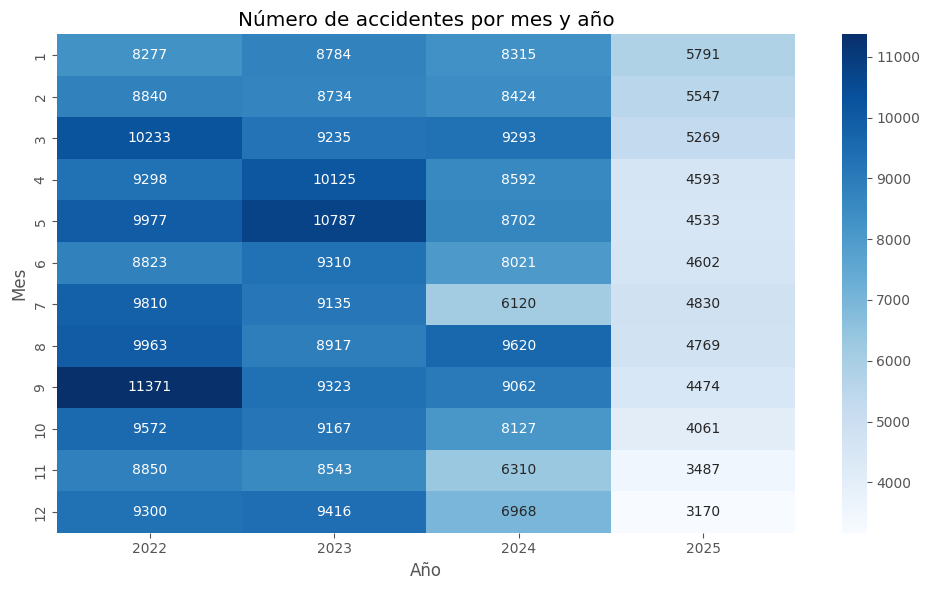

In [42]:
pivot_meses = pd.pivot_table(
    df, values='FECHA_ACCIDENTE', index='MES',
    columns='AÑO', aggfunc='count', fill_value=0
).reindex(range(1, 13))

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_meses, annot=True, fmt='d', cmap='Blues')
plt.title('Número de accidentes por mes y año')
plt.xlabel('Año')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

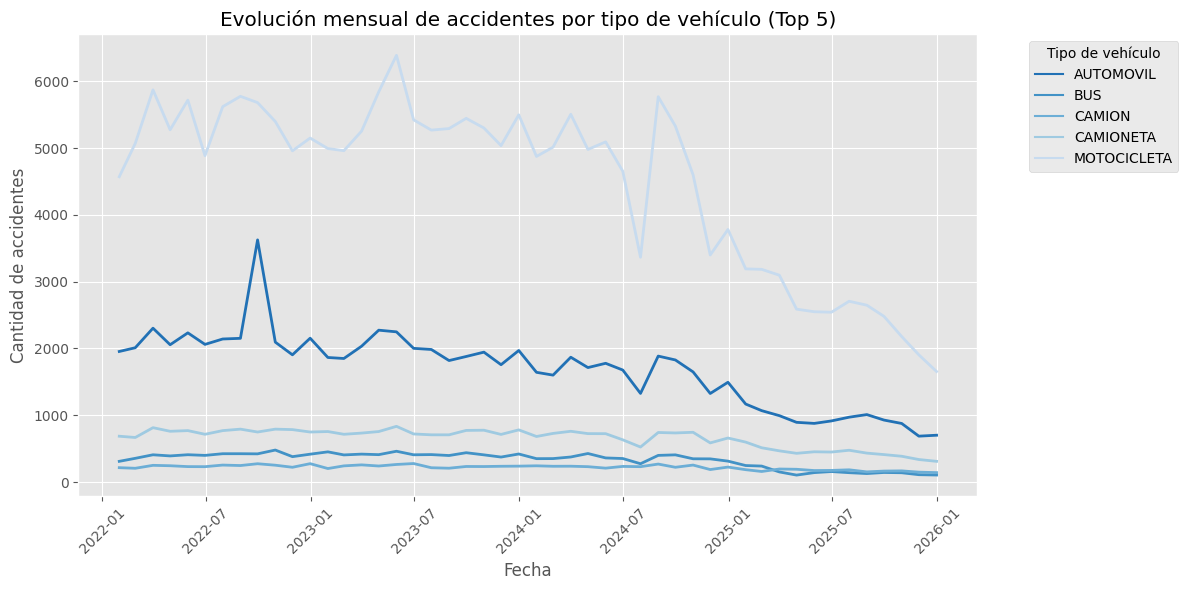

In [43]:
# Serie de tiempo mensual por tipo de vehículo (Top 5)
top5_tipos = df['TIPO_VEHICULO'].value_counts().nlargest(5).index
df_top5 = df[df['TIPO_VEHICULO'].isin(top5_tipos)]

serie = df_top5.groupby([
    pd.Grouper(key='FECHA_ACCIDENTE', freq='ME'),
    'TIPO_VEHICULO'
]).size().reset_index(name='CANTIDAD')

plt.figure(figsize=(12, 6))
colores = sns.color_palette('Blues_r', 7)[1:6]
sns.lineplot(data=serie, x='FECHA_ACCIDENTE', y='CANTIDAD',
             hue='TIPO_VEHICULO', palette=colores, linewidth=2)
plt.title('Evolución mensual de accidentes por tipo de vehículo (Top 5)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de accidentes')
plt.xticks(rotation=45)
plt.legend(title='Tipo de vehículo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Hallazgos relacionados con el Objetivo 3 (temporal):**
- **Nivel mensual:** Julio es el mes con mayor volumen de accidentes. Meses como marzo y septiembre presentan picos en la tasa de mortalidad, posiblemente asociados a temporadas de lluvia y movilidad recreativa.
- **Nivel semanal:** Los fines de semana (sábado y domingo) concentran una mayor tasa de mortalidad, coherente con el aumento de conducción recreativa y nocturna.
- **Serie de tiempo:** Las motocicletas mantienen un dominio absoluto y estable. Se observan picos recurrentes en julio (vacaciones de mitad de año) y diciembre-enero (temporada navideña).

---
## 8. Análisis geográfico 

Se analizan las diferencias territoriales en volumen de accidentes y tasa de mortalidad, incluyendo el cruce con tipo de vehículo.

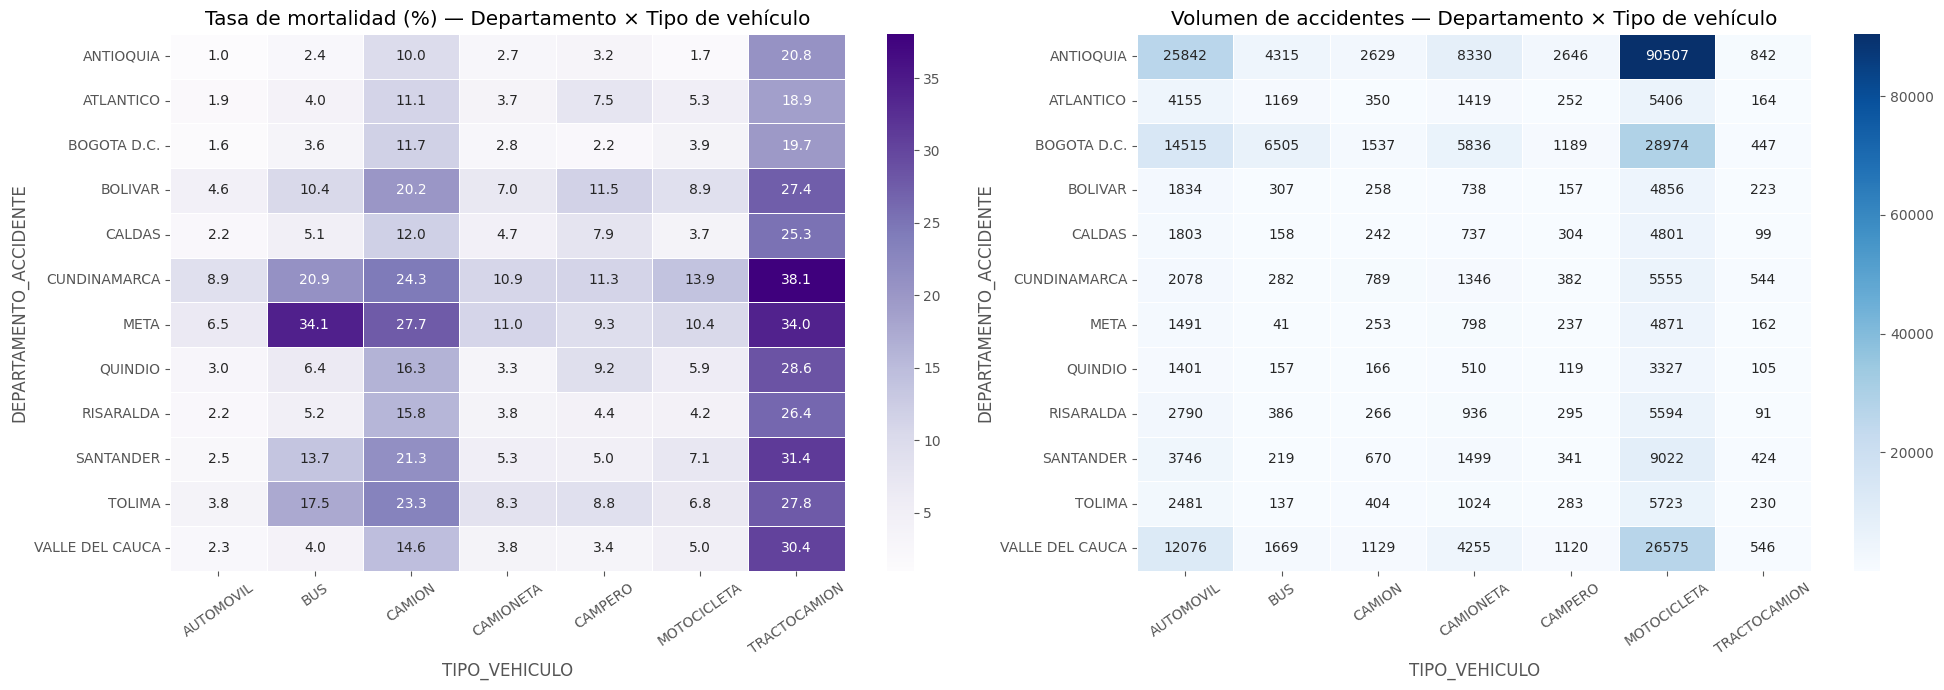

In [44]:
# Heatmap: Tasa de mortalidad y volumen por departamento × tipo de vehículo
top_dep_p2   = df['DEPARTAMENTO_ACCIDENTE'].value_counts().nlargest(12).index
top_tipos_p2 = df['TIPO_VEHICULO'].value_counts().nlargest(7).index

df_cruce = df[
    df['DEPARTAMENTO_ACCIDENTE'].isin(top_dep_p2) &
    df['TIPO_VEHICULO'].isin(top_tipos_p2)
]

pivot_mort = df_cruce.pivot_table(
    index='DEPARTAMENTO_ACCIDENTE', columns='TIPO_VEHICULO',
    values='GRAVEDAD_ACCIDENTE',
    aggfunc=lambda x: (x == 'CON MUERTOS').mean() * 100
)
pivot_cont = df_cruce.pivot_table(
    index='DEPARTAMENTO_ACCIDENTE', columns='TIPO_VEHICULO',
    values='GRAVEDAD_ACCIDENTE', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(pivot_mort, annot=True, fmt='.1f', cmap='Purples', linewidths=0.5, ax=axes[0])
axes[0].set_title('Tasa de mortalidad (%) — Departamento × Tipo de vehículo')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(pivot_cont, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=axes[1])
axes[1].set_title('Volumen de accidentes — Departamento × Tipo de vehículo')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

---
## 9. Análisis inferencial

Se aplican pruebas estadísticas formales para validar las tendencias observadas en las secciones anteriores.

### 9.1 Asociación entre variables categóricas y gravedad — V de Cramér

Asociación de variables categóricas con GRAVEDAD_ACCIDENTE (V de Cramér):
              Variable  V_de_Cramer Asociación
   MUNICIPIO_ACCIDENTE       0.3243     Fuerte
 AUTORIDAD_DE_TRANSITO       0.3229     Fuerte
DEPARTAMENTO_ACCIDENTE       0.2110   Moderada
     MODELO_ESPECIFICO       0.1933      Débil
         TIPO_VEHICULO       0.1678      Débil
        MARCA_VEHICULO       0.1467      Débil
     CAT_EDAD_VEHICULO       0.0469  Muy débil
            MES_NOMBRE       0.0189  Muy débil
            DIA_SEMANA       0.0097  Muy débil


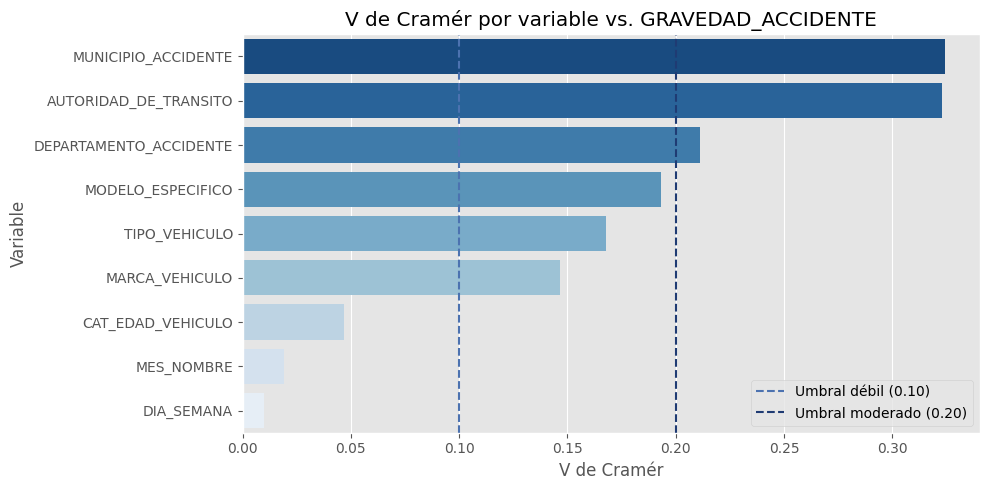

In [45]:
def evaluar_asociacion(df, variable_objetivo):
    resultados = []
    cols = [c for c in df.select_dtypes(include=['object','category']).columns if c != variable_objetivo]
    for col in cols:
        tabla = pd.crosstab(df[col], df[variable_objetivo])
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
        chi2 = ss.chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        r, k = tabla.shape
        v = np.sqrt(chi2 / (n * min(r-1, k-1))) if min(r-1, k-1) > 0 else 0
        fuerza = ('Muy débil' if v < 0.10 else 'Débil' if v < 0.20
                  else 'Moderada' if v < 0.30 else 'Fuerte')
        resultados.append({'Variable': col, 'V_de_Cramer': round(v, 4), 'Asociación': fuerza})
    return pd.DataFrame(resultados).sort_values('V_de_Cramer', ascending=False).reset_index(drop=True)

tabla_v = evaluar_asociacion(df, 'GRAVEDAD_ACCIDENTE')
print("Asociación de variables categóricas con GRAVEDAD_ACCIDENTE (V de Cramér):")
print(tabla_v.to_string(index=False))

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=tabla_v, x='V_de_Cramer', y='Variable', palette='Blues_r')
plt.axvline(0.10, color='#4C72B0', linestyle='--', label='Umbral débil (0.10)')
plt.axvline(0.20, color='#1F3B73', linestyle='--', label='Umbral moderado (0.20)')
plt.title('V de Cramér por variable vs. GRAVEDAD_ACCIDENTE')
plt.xlabel('V de Cramér')
plt.legend()
plt.tight_layout()
plt.show()

Asociación de variables categóricas con GRAVEDAD_ACCIDENTE (V de Cramér):
              Variable  V_de_Cramer Asociación
 AUTORIDAD_DE_TRANSITO       0.3212     Fuerte
   MUNICIPIO_ACCIDENTE       0.3118     Fuerte
DEPARTAMENTO_ACCIDENTE       0.2110   Moderada
         TIPO_VEHICULO       0.1673      Débil
     MODELO_ESPECIFICO       0.1577      Débil
        MARCA_VEHICULO       0.1416      Débil
     CAT_EDAD_VEHICULO       0.0469  Muy débil
            MES_NOMBRE       0.0189  Muy débil
            DIA_SEMANA       0.0097  Muy débil


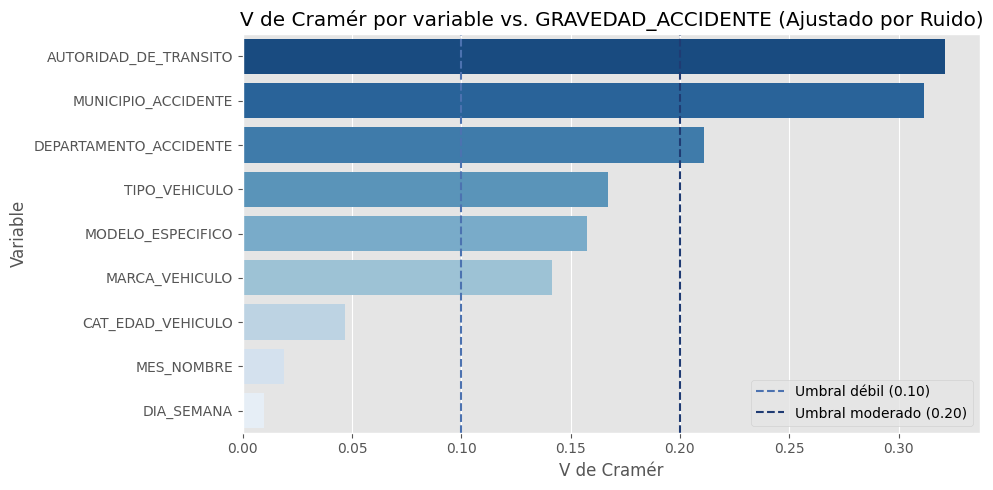

In [46]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_asociacion_robusta(df, variable_objetivo, umbral_frecuencia=30):
    resultados = []
    # Seleccionamos variables categóricas o de texto
    cols = [c for c in df.select_dtypes(include=['object','category']).columns if c != variable_objetivo]
    
    for col in cols:
        # 1. Identificar las categorías raras (las que están por debajo del umbral)
        frecuencias = df[col].value_counts()
        categorias_raras = frecuencias[frecuencias < umbral_frecuencia].index
        
        # 2. Crear una serie temporal reemplazando el ruido por 'OTROS'
        serie_limpia = df[col].copy()
        if len(categorias_raras) > 0:
            serie_limpia = serie_limpia.replace(categorias_raras, 'OTROS')
            
        # 3. Crear la tabla cruzada ya limpia de ruido
        tabla = pd.crosstab(serie_limpia, df[variable_objetivo])
        
        # Validación de seguridad: si la tabla es menor a 2x2, la ignoramos
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
            
        # 4. Calcular Chi-cuadrado y V de Cramér
        chi2 = ss.chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        r, k = tabla.shape
        
        # Calcular V de Cramér (con protección de división por 0)
        min_dim = min(r-1, k-1)
        v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        
        # 5. Etiquetar la fuerza
        fuerza = ('Muy débil' if v < 0.10 else 'Débil' if v < 0.20 
                  else 'Moderada' if v < 0.30 else 'Fuerte')
                  
        resultados.append({'Variable': col, 'V_de_Cramer': round(v, 4), 'Asociación': fuerza})
        
    return pd.DataFrame(resultados).sort_values('V_de_Cramer', ascending=False).reset_index(drop=True)

# EJECUCIÓN DEL CÓDIGO
# Le pasamos el dataframe, la variable objetivo y el umbral de 30 que recomendó tu amigo
tabla_v = evaluar_asociacion_robusta(df, 'GRAVEDAD_ACCIDENTE', umbral_frecuencia=30)

print("Asociación de variables categóricas con GRAVEDAD_ACCIDENTE (V de Cramér):")
print(tabla_v.to_string(index=False))

# Tu código de visualización original funciona perfecto con esta nueva tabla
plt.figure(figsize=(10, 5))
sns.barplot(data=tabla_v, x='V_de_Cramer', y='Variable', palette='Blues_r')
plt.axvline(0.10, color='#4C72B0', linestyle='--', label='Umbral débil (0.10)')
plt.axvline(0.20, color='#1F3B73', linestyle='--', label='Umbral moderado (0.20)')
plt.title('V de Cramér por variable vs. GRAVEDAD_ACCIDENTE (Ajustado por Ruido)')
plt.xlabel('V de Cramér')
plt.legend()
plt.tight_layout()
plt.show()

              Variable  V_de_Cramer Asociación_Real  Umbral_Fuerte_Req
 AUTORIDAD_DE_TRANSITO       0.3212        Moderada                0.5
   MUNICIPIO_ACCIDENTE       0.3118        Moderada                0.5
DEPARTAMENTO_ACCIDENTE       0.2110           Débil                0.5
         TIPO_VEHICULO       0.1673           Débil                0.5
     MODELO_ESPECIFICO       0.1577           Débil                0.5
        MARCA_VEHICULO       0.1416           Débil                0.5
     CAT_EDAD_VEHICULO       0.0469       Muy débil                0.5
            MES_NOMBRE       0.0189       Muy débil                0.5
            DIA_SEMANA       0.0097       Muy débil                0.5


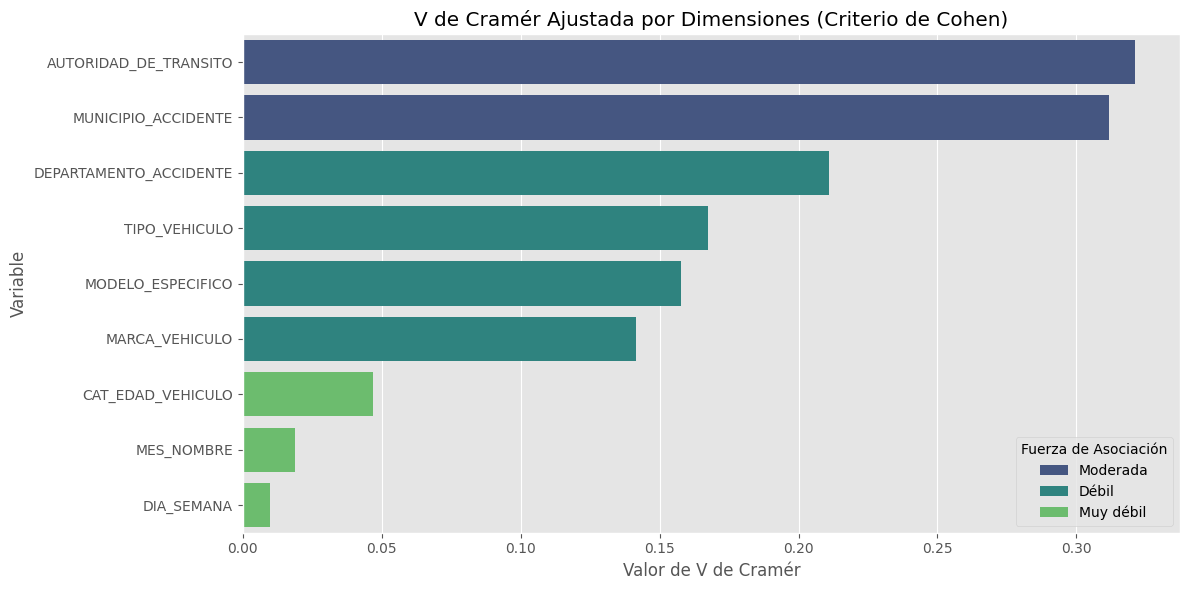

In [47]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_asociacion_dinamica(df, variable_objetivo, umbral_frecuencia=30):
    resultados = []
    cols = [c for c in df.select_dtypes(include=['object','category']).columns if c != variable_objetivo]
    
    for col in cols:
        # 1. Limpieza de ruido (lo que aprendimos antes)
        frecuencias = df[col].value_counts()
        categorias_raras = frecuencias[frecuencias < umbral_frecuencia].index
        serie_limpia = df[col].replace(categorias_raras, 'OTROS') if len(categorias_raras) > 0 else df[col]
            
        # 2. Crear tabla cruzada
        tabla = pd.crosstab(serie_limpia, df[variable_objetivo])
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue
            
        # 3. Calcular métricas base
        chi2 = ss.chi2_contingency(tabla)[0]
        n = tabla.sum().sum()
        r, k = tabla.shape
        
        # 4. Calcular los grados de libertad ajustados (df*)
        min_dim = min(r-1, k-1)
        if min_dim == 0: 
            continue
            
        v = np.sqrt(chi2 / (n * min_dim))
        
        # 5. Calcular los umbrales dinámicos de Cohen para ESTA variable específica
        umbral_debil = 0.10 / np.sqrt(min_dim)
        umbral_moderado = 0.30 / np.sqrt(min_dim)
        umbral_fuerte = 0.50 / np.sqrt(min_dim)
        
        # 6. Evaluar la fuerza real
        if v < umbral_debil:
            fuerza = 'Muy débil'
        elif v < umbral_moderado:
            fuerza = 'Débil'
        elif v < umbral_fuerte:
            fuerza = 'Moderada'
        else:
            fuerza = 'Fuerte'
                  
        resultados.append({
            'Variable': col, 
            'V_de_Cramer': round(v, 4), 
            'Asociación_Real': fuerza,
            'Umbral_Fuerte_Req': round(umbral_fuerte, 4) # Para que veas qué le exigió la prueba
        })
        
    return pd.DataFrame(resultados).sort_values('V_de_Cramer', ascending=False).reset_index(drop=True)

# EJECUCIÓN
tabla_v = evaluar_asociacion_dinamica(df, 'GRAVEDAD_ACCIDENTE')
print(tabla_v.to_string(index=False))

# VISUALIZACIÓN ACTUALIZADA
# Quitamos las líneas verticales estáticas (axvline) porque ahora cada barra tiene sus propias reglas
plt.figure(figsize=(12, 6))
sns.barplot(data=tabla_v, x='V_de_Cramer', y='Variable', hue='Asociación_Real', dodge=False, palette='viridis')
plt.title('V de Cramér Ajustada por Dimensiones (Criterio de Cohen)')
plt.xlabel('Valor de V de Cramér')
plt.legend(title='Fuerza de Asociación', loc='lower right')
plt.tight_layout()
plt.show()

              Variable  V_de_Cramer Asociacion  Umbral_Fuerte_Requerido  Num_Categorias_Final
 AUTORIDAD_DE_TRANSITO       0.3204   Moderada                      0.5                   184
   MUNICIPIO_ACCIDENTE       0.3106   Moderada                      0.5                   271
DEPARTAMENTO_ACCIDENTE       0.2108      Débil                      0.5                    31
         TIPO_VEHICULO       0.1672      Débil                      0.5                    13
     MODELO_ESPECIFICO       0.1507      Débil                      0.5                   811
        MARCA_VEHICULO       0.1406      Débil                      0.5                   112
     CAT_EDAD_VEHICULO       0.0468  Muy débil                      0.5                     4
            MES_NOMBRE       0.0181  Muy débil                      0.5                    12
            DIA_SEMANA       0.0088  Muy débil                      0.5                     7


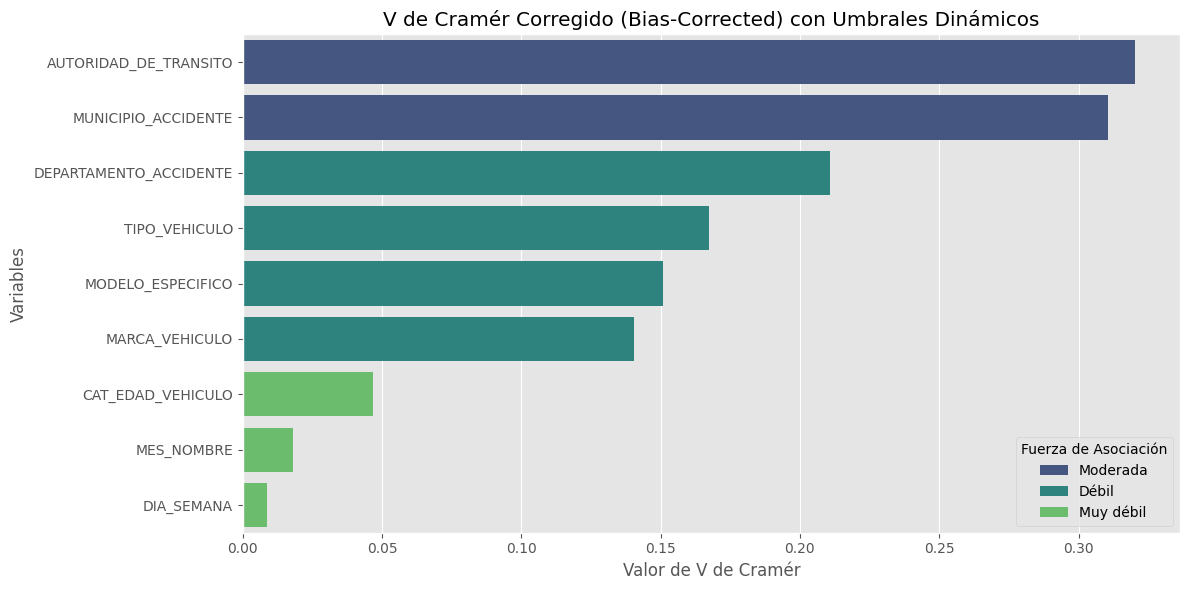

In [48]:
# ============================================
# PROBLEMA:
# Evaluar la asociación entre variables categóricas
# usando V de Cramér corregido, evitando sesgos por:
# - categorías raras
# - tamaño de muestra
# - dimensiones de la tabla
# ============================================

import pandas as pd
import numpy as np
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns


def cramers_v_bias_corrected(tabla):
    """
    Calcula Cramér's V con corrección de sesgo (Bergsma, 2013)
    """
    chi2 = ss.chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    
    if n == 0:
        return np.nan
    
    r, k = tabla.shape
    
    phi2 = chi2 / n
    
    # Corrección de sesgo
    correction = ((k - 1) * (r - 1)) / (n - 1)
    phi2_corr = max(0, phi2 - correction)
    
    # Ajuste de dimensiones
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    
    min_dim_corr = min(r_corr - 1, k_corr - 1)
    
    if min_dim_corr <= 0:
        return np.nan
    
    return np.sqrt(phi2_corr / min_dim_corr)


def evaluar_asociacion_dinamica(
    df,
    variable_objetivo,
    umbral_frecuencia_abs=100,
    umbral_frecuencia_rel=None  # ejemplo: 0.01 (1%)
):
    resultados = []

    cols = [
        c for c in df.select_dtypes(include=['object', 'category']).columns
        if c != variable_objetivo
    ]

    n_total = len(df)

    for col in cols:
        serie = df[col].copy()

        # ============================================
        # 1. LIMPIEZA DE CATEGORÍAS RARAS
        # ============================================

        frecuencias = serie.value_counts(dropna=False)

        if umbral_frecuencia_rel is not None:
            categorias_raras = frecuencias[
                (frecuencias / n_total) < umbral_frecuencia_rel
            ].index
        else:
            categorias_raras = frecuencias[
                frecuencias < umbral_frecuencia_abs
            ].index

        if len(categorias_raras) > 0:
            serie = serie.replace(categorias_raras, 'OTROS')

        # ============================================
        # 2. TABLA DE CONTINGENCIA
        # ============================================

        tabla = pd.crosstab(serie, df[variable_objetivo])

        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue

        # ============================================
        # 3. CRAMÉR'S V CORREGIDO
        # ============================================

        v = cramers_v_bias_corrected(tabla)

        if np.isnan(v):
            continue

        # ============================================
        # 4. DIMENSIÓN EFECTIVA
        # ============================================

        r, k = tabla.shape
        min_dim = min(r - 1, k - 1)

        if min_dim <= 0:
            continue

        # ============================================
        # 5. UMBRALES DINÁMICOS (COHEN AJUSTADO)
        # ============================================

        umbral_debil = 0.10 / np.sqrt(min_dim)
        umbral_moderado = 0.30 / np.sqrt(min_dim)
        umbral_fuerte = 0.50 / np.sqrt(min_dim)

        # ============================================
        # 6. CLASIFICACIÓN
        # ============================================

        if v < umbral_debil:
            fuerza = 'Muy débil'
        elif v < umbral_moderado:
            fuerza = 'Débil'
        elif v < umbral_fuerte:
            fuerza = 'Moderada'
        else:
            fuerza = 'Fuerte'

        resultados.append({
            'Variable': col,
            'V_de_Cramer': round(v, 4),
            'Asociacion': fuerza,
            'Umbral_Fuerte_Requerido': round(umbral_fuerte, 4),
            'Num_Categorias_Final': tabla.shape[0]
        })

    resultado_df = pd.DataFrame(resultados)

    if len(resultado_df) == 0:
        return resultado_df

    return resultado_df.sort_values(
        'V_de_Cramer', ascending=False
    ).reset_index(drop=True)


# ============================================
# EJECUCIÓN
# ============================================

tabla_v = evaluar_asociacion_dinamica(
    df,
    variable_objetivo='GRAVEDAD_ACCIDENTE',
    umbral_frecuencia_abs=30,
    # umbral_frecuencia_rel=0.01  # opcional (mejor en datasets grandes)
)

print(tabla_v.to_string(index=False))


# ============================================
# VISUALIZACIÓN
# ============================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=tabla_v,
    x='V_de_Cramer',
    y='Variable',
    hue='Asociacion',
    dodge=False,
    palette='viridis'
)

plt.title('V de Cramér Corregido (Bias-Corrected) con Umbrales Dinámicos')
plt.xlabel('Valor de V de Cramér')
plt.ylabel('Variables')
plt.legend(title='Fuerza de Asociación', loc='lower right')

plt.tight_layout()
plt.show()

**Interpretación con V de Cramér:**
- `MUNICIPIO_ACCIDENTE` y `AUTORIDAD_DE_TRANSITO` presentan la asociación más alta (moderada), lo que confirma que la geografía específica del siniestro es el predictor más fuerte.
- `TIPO_VEHICULO` y `MARCA_VEHICULO` muestran asociación débil pero estadísticamente relevante para el modelado.
- `MES_NOMBRE` tiene asociación muy débil: el mes por sí solo no predice bien la gravedad.

### 9.2 Prueba estadística para EDAD_VEHICULO 

Dado que la distribución de `EDAD_VEHICULO` no es normal (confirmado por la prueba K-S), se utiliza la prueba **Kruskal-Wallis** para comparar medianas entre grupos de gravedad. Se complementa con la **prueba T de Welch** dada la escala del dataset (n > 400,000).

In [49]:
# Prueba de normalidad (Kolmogorov-Smirnov)
data_kv = df['EDAD_VEHICULO'].dropna()
stat_ks, p_ks = ss.kstest(data_kv, 'norm', args=(data_kv.mean(), data_kv.std()))
print(f"K-S para EDAD_VEHICULO: stat={stat_ks:.4f}, p={p_ks:.2e}")
print(f"→ {'No normal (p < 0.05)' if p_ks < 0.05 else 'Podría ser normal'}")
print()

#levene
stat_levene, p_levene = ss.levene(
    df[df['GRAVEDAD_ACCIDENTE'] == 'CON HERIDOS']['EDAD_VEHICULO'].dropna(),
    df[df['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS']['EDAD_VEHICULO'].dropna()
)
print(f"Levene para EDAD_VEHICULO: stat={stat_levene:.2f}, p={p_levene:.2e}")
print(f"→ {'Varianzas desiguales (p < 0.05)' if p_levene < 0.05 else 'Varianzas homogéneas'}")
print() 

#U-Mann-Whitney
grupo_heridos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON HERIDOS']['EDAD_VEHICULO'].dropna()
grupo_muertos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS']['EDAD_VEHICULO'].dropna()
stat_mw, p_mw = ss.mannwhitneyu(grupo_heridos, grupo_muertos, alternative='two-sided')
print(f"Mann-Whitney U: stat={stat_mw:.2f}, p={p_mw:.2e}")
print(f"→ {'Diferencia significativa (p < 0.05)' if p_mw < 0.05 else 'No hay diferencia significativa'}")
print()

# ANOVA de Welch (confirmatoria — válida por Teorema del Límite Central con n grande)
stat_f, p_f = ss.f_oneway(grupo_heridos, grupo_muertos)
print(f"ANOVA (Welch): F={stat_f:.2f}, p={p_f:.2e}")
print(f"Media EDAD — CON HERIDOS: {grupo_heridos.mean():.2f} años")
print(f"Media EDAD — CON MUERTOS: {grupo_muertos.mean():.2f} años")

K-S para EDAD_VEHICULO: stat=0.1086, p=0.00e+00
→ No normal (p < 0.05)

Levene para EDAD_VEHICULO: stat=759.79, p=4.38e-167
→ Varianzas desiguales (p < 0.05)

Mann-Whitney U: stat=3350130080.00, p=1.13e-65
→ Diferencia significativa (p < 0.05)

ANOVA (Welch): F=634.07, p=8.49e-140
Media EDAD — CON HERIDOS: 10.25 años
Media EDAD — CON MUERTOS: 11.55 años


In [50]:
import pandas as pd
import scipy.stats as ss

# 1. Separar los grupos desde el principio (El filtro)
grupo_heridos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON HERIDOS']['EDAD_VEHICULO'].dropna()
grupo_muertos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS']['EDAD_VEHICULO'].dropna()

print("--- PASO 1: NORMALIDAD POR GRUPOS ---")
# K-S para Heridos
stat_ks_h, p_ks_h = ss.kstest(grupo_heridos, 'norm', args=(grupo_heridos.mean(), grupo_heridos.std()))
# K-S para Muertos
stat_ks_m, p_ks_m = ss.kstest(grupo_muertos, 'norm', args=(grupo_muertos.mean(), grupo_muertos.std()))

print(f"K-S Heridos: p={p_ks_h:.2e}")
print(f"K-S Muertos: p={p_ks_m:.2e}")
print("→ Resultado: Como p < 0.05, los datos NO son normales. Vamos a la Rama No Paramétrica.\n")

print("--- PASO 2: PRUEBA NO PARAMÉTRICA (MANN-WHITNEY) ---")
# Ejecutar Mann-Whitney U
stat_mw, p_mw = ss.mannwhitneyu(grupo_heridos, grupo_muertos, alternative='two-sided')

print(f"Mann-Whitney U: stat={stat_mw:.2f}, p={p_mw:.2e}")
print("→ Diferencia 'estadísticamente significativa' (esperable por los 400k datos).\n")

print("--- PASO 3: TAMAÑO DEL EFECTO (RBC) ---")
# Cálculo de la Correlación de Rango Biserial
n1 = len(grupo_heridos)
n2 = len(grupo_muertos)

# Fórmula: 1 - (2 * U) / (n1 * n2)
rbc = 1 - (2 * stat_mw) / (n1 * n2)

print(f"mediana EDAD - HERIDOS: {grupo_heridos.median():.2f} años (n={n1})")
print(f"mediana EDAD - MUERTOS: {grupo_muertos.median():.2f} años (n={n2})")
print(f"Correlación de Rango Biserial (RBC): {rbc:.3f}")

# Interpretación automática
abs_rbc = abs(rbc)
if abs_rbc < 0.1:
    impacto = "Insignificante (Espejismo estadístico)"
elif abs_rbc < 0.3:
    impacto = "Pequeño"
elif abs_rbc < 0.5:
    impacto = "Moderado"
else:
    impacto = "Grande"

print(f"→ Impacto en la vida real: {impacto}")

--- PASO 1: NORMALIDAD POR GRUPOS ---
K-S Heridos: p=0.00e+00
K-S Muertos: p=2.51e-243
→ Resultado: Como p < 0.05, los datos NO son normales. Vamos a la Rama No Paramétrica.

--- PASO 2: PRUEBA NO PARAMÉTRICA (MANN-WHITNEY) ---
Mann-Whitney U: stat=3350130080.00, p=1.13e-65
→ Diferencia 'estadísticamente significativa' (esperable por los 400k datos).

--- PASO 3: TAMAÑO DEL EFECTO (RBC) ---
mediana EDAD - HERIDOS: 9.00 años (n=358333)
mediana EDAD - MUERTOS: 10.00 años (n=20137)
Correlación de Rango Biserial (RBC): 0.071
→ Impacto en la vida real: Insignificante (Espejismo estadístico)


In [51]:
import statsmodels.formula.api as smf
import numpy as np

# 1. Crear una columna binaria: 0 = Heridos, 1 = Muertos 
# (Los modelos logísticos necesitan predecir un 1 o un 0)
df_modelo = df.dropna(subset=['EDAD_VEHICULO', 'GRAVEDAD_ACCIDENTE']).copy()
df_modelo['FATAL'] = np.where(df_modelo['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS', 1, 0)

# 2. Entrenar el modelo de Regresión Logística
modelo_log = smf.logit('FATAL ~ EDAD_VEHICULO', data=df_modelo).fit(disp=0)

# 3. Calcular la "influencia" exacta (Odds Ratio)
odds_ratio = np.exp(modelo_log.params['EDAD_VEHICULO'])
porcentaje_aumento = (odds_ratio - 1) * 100

print(f"\n" + "="*80)
print(f"INFLUENCIA DE LA EDAD EN LA GRAVEDAD DEL ACCIDENTE")
print("="*80)
print(f"Por cada 1 año extra de edad que tenga el vehículo,")
print(f"la probabilidad de que el accidente sea FATAL aumenta en un {porcentaje_aumento:.2f}%")


INFLUENCIA DE LA EDAD EN LA GRAVEDAD DEL ACCIDENTE
Por cada 1 año extra de edad que tenga el vehículo,
la probabilidad de que el accidente sea FATAL aumenta en un 2.28%


**Conclusión — Objetivo 2:** Las pruebas estadísticas confirman que la diferencia en la edad del vehículo entre accidentes fatales y no fatales es **estadísticamente significativa** (p < 0.001). Los vehículos involucrados en accidentes mortales son, en promedio, más antiguos que los de accidentes con heridos.

### 9.3 Test de proporciones con intervalos de confianza Wilson 

Se evalúan diferencias en tasas de mortalidad entre grupos, con **filtros de confiabilidad estadística** para garantizar que los grupos analizados tengan suficiente tamaño muestral.

> **Parámetros de confiabilidad** (ver documento de justificación estadística):
> - `muestra_mínima = 100` → SE ≤ 2.17% (Agresti, 2002)
> - `eventos_mínimos = 10` → regla n×p ≥ 10 (Montgomery & Runger, 2010)
> - `ancho_IC_máximo = 20%` → límite de utilidad práctica (Cumming, 2014)

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def wilson_ic(n, x, z=1.96):
    """Intervalo de confianza de Wilson para proporciones."""
    if n == 0: return 0, 0, 0
    p = x / n
    if x == 0:
        ic_sup = min(1, 3/n)
        return 0, ic_sup, ic_sup * 100
    if x == n:
        ic_inf = max(0, 1 - 3/n)
        return ic_inf, 1, (1 - ic_inf) * 100
    den = 1 + z**2/n
    centro = (p + z**2/(2*n)) / den
    margen = z * np.sqrt((p*(1-p) + z**2/(4*n))/n) / den
    ic_inf = max(0, centro - margen)
    ic_sup = min(1, centro + margen)
    return ic_inf, ic_sup, (ic_sup - ic_inf) * 100

def ranking_riesgo_accidentalidad(df, columna_grupo, columna_evento='GRAVEDAD_ACCIDENTE',
                                 categoria='CON MUERTOS',
                                 muestra_minima=100, eventos_minimos=10, ancho_ic_max=20,
                                 titulo='', top_n=10):
    """Test Z de proporciones y ranking de riesgo con filtros de confiabilidad."""
    print(f"\n{'='*80}")
    print(f"ANÁLISIS DE RIESGO: {categoria} por {columna_grupo} {titulo}")
    print(f"{'='*80}")

    df_t = df.dropna(subset=[columna_grupo, columna_evento]).copy()
    tabla = pd.crosstab(df_t[columna_grupo], df_t[columna_evento])
    if categoria not in tabla.columns:
        print("ERROR: categoría no encontrada."); return None
    tabla['TOTAL'] = tabla.sum(axis=1)

    confiables, no_confiables, metricas = [], [], []
    for g in tabla.index:
        n, x = int(tabla.loc[g,'TOTAL']), int(tabla.loc[g, categoria])
        ic_inf, ic_sup, ancho = wilson_ic(n, x)
        ok = (n >= muestra_minima) and (x >= eventos_minimos) and ((n-x) >= eventos_minimos) and (ancho <= ancho_ic_max)
        metricas.append({'Grupo': g, 'n': n, 'eventos': x, 'tasa_%': round(x/n*100,2) if n>0 else 0,
                         'IC_inf_%': round(ic_inf*100,2), 'IC_sup_%': round(ic_sup*100,2),
                         'Ancho_IC': round(ancho,2), 'Confiable': ok})
        (confiables if ok else no_confiables).append(g)

    df_m = pd.DataFrame(metricas)
    
    # --- BLOQUE: Filtrar y ordenar solo el TOP N ---
    df_top = df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False).head(top_n)
    
    print(f"\nGrupos confiables: {len(confiables)} / {len(metricas)} totales")
    print(f"(Criterios: n≥{muestra_minima}, eventos≥{eventos_minimos}, Ancho IC≤{ancho_ic_max}%)")
    
    if len(df_top) == 0:
        print("No hay grupos confiables para mostrar."); return df_m
        
    print(f"\nMOSTRANDO EL TOP {len(df_top)} CON MAYOR TASA:")
    print()
    print(df_top.to_string(index=False))

    if len(confiables) < 2:
        print("\nInsuficientes grupos confiables para graficar comparaciones.")
        return df_m

    # Ranking visual usando df_top
    print(f"\nRANKING (Top {len(df_top)} grupos confiables):")
    for i, (_, row) in enumerate(df_top.iterrows(), 1):
        barra = '█' * int(row['tasa_%'] * 3)
        print(f"  {i:2}. {str(row['Grupo'])[:30]:<31} {row['tasa_%']:6.2f}%  {barra}")

    # Gráfico usando df_top
    plt.figure(figsize=(10, 0.5 + 0.5 * len(df_top)))
    
    plt.barh(df_top['Grupo'], df_top['tasa_%'], color=sns.color_palette('Blues_r', len(df_top)))
    
    plt.errorbar(
        df_top['tasa_%'], range(len(df_top)),
        xerr=[(df_top['tasa_%'] - df_top['IC_inf_%']).values,
              (df_top['IC_sup_%'] - df_top['tasa_%']).values],
        fmt='none', color='black', capsize=4
    )
    
    global_rate = df[df[columna_evento].notna()][columna_evento].eq(categoria).mean() * 100
    plt.axvline(global_rate, color='red', linestyle='--', label=f'Global ({global_rate:.2f}%)')
    
    plt.gca().invert_yaxis()
    plt.title(f'Top {len(df_top)} - Tasa de {categoria.lower()} con IC 95% por {columna_grupo} {titulo}')
    plt.xlabel(f'Tasa (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_m


ANÁLISIS DE RIESGO: CON MUERTOS por MARCA_VEHICULO — Objetivo 1

Grupos confiables: 65 / 356 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

MOSTRANDO EL TOP 10 CON MAYOR TASA:

          Grupo    n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
   FREIGHTLINER  657      189   28.77     25.44     32.34      6.91       True
       KENWORTH 2606      707   27.13     25.46     28.87      3.41       True
  INTERNATIONAL 2841      631   22.21     20.72     23.78      3.06       True
            DAF  181       39   21.55     16.18     28.09     11.91       True
           MACK  133       28   21.05     14.99     28.74     13.76       True
MITSUBISHI FUSO  136       25   18.38     12.77     25.73     12.96       True
          DODGE  967      157   16.24     14.05     18.69      4.65       True
         KEEWAY  166       24   14.46      9.91     20.61     10.70       True
            JAC 1528      194   12.70     11.12     14.46      3.34       True
          FOTON 1911     

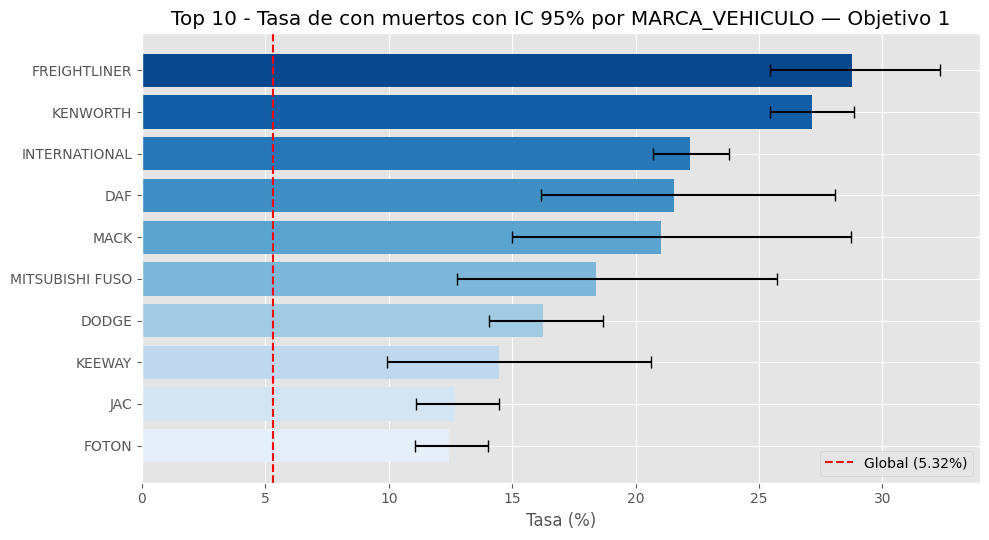

In [53]:
# Objetivo 1: Tipo de vehículo
resultado_tipo = ranking_riesgo_accidentalidad(
    df, columna_grupo='MARCA_VEHICULO', columna_evento='GRAVEDAD_ACCIDENTE',
    titulo='— Objetivo 1'
)

In [54]:
def wilson_ic(n, x, z=1.96):
    """Intervalo de confianza de Wilson para proporciones."""
    if n == 0: return 0, 0, 0
    p = x / n
    if x == 0:
        ic_sup = min(1, 3/n)
        return 0, ic_sup, ic_sup * 100
    if x == n:
        ic_inf = max(0, 1 - 3/n)
        return ic_inf, 1, (1 - ic_inf) * 100
    den = 1 + z**2/n
    centro = (p + z**2/(2*n)) / den
    margen = z * np.sqrt((p*(1-p) + z**2/(4*n))/n) / den
    ic_inf = max(0, centro - margen)
    ic_sup = min(1, centro + margen)
    return ic_inf, ic_sup, (ic_sup - ic_inf) * 100


def test_proporciones_confiable(df, columna_grupo, columna_evento='GRAVEDAD_ACCIDENTE',
                                 categoria='CON MUERTOS',
                                 muestra_minima=100, eventos_minimos=10, ancho_ic_max=20,
                                 titulo=''):
    """Test Z de proporciones con filtros de confiabilidad estadística."""
    print(f"\n{'='*80}")
    print(f"TEST DE PROPORCIONES: {categoria} por {columna_grupo} {titulo}")
    print(f"{'='*80}")

    df_t = df.dropna(subset=[columna_grupo, columna_evento]).copy()
    tabla = pd.crosstab(df_t[columna_grupo], df_t[columna_evento])
    if categoria not in tabla.columns:
        print("ERROR: categoría no encontrada."); return None
    tabla['TOTAL'] = tabla.sum(axis=1)

    confiables, no_confiables, metricas = [], [], []
    for g in tabla.index:
        n, x = int(tabla.loc[g,'TOTAL']), int(tabla.loc[g, categoria])
        ic_inf, ic_sup, ancho = wilson_ic(n, x)
        ok = (n >= muestra_minima) and (x >= eventos_minimos) and ((n-x) >= eventos_minimos) and (ancho <= ancho_ic_max)
        metricas.append({'Grupo': g, 'n': n, 'eventos': x, 'tasa_%': round(x/n*100,2) if n>0 else 0,
                         'IC_inf_%': round(ic_inf*100,2), 'IC_sup_%': round(ic_sup*100,2),
                         'Ancho_IC': round(ancho,2), 'Confiable': ok})
        (confiables if ok else no_confiables).append(g)

    df_m = pd.DataFrame(metricas)
    print(f"\nGrupos confiables: {len(confiables)} / {len(metricas)} totales")
    print(f"(Criterios: n≥{muestra_minima}, eventos≥{eventos_minimos}, Ancho IC≤{ancho_ic_max}%)")
    print()
    print(df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False).to_string(index=False))

    if len(confiables) < 2:
        print("Insuficientes grupos confiables para comparar."); return None

    # Ranking visual
    print(f"\nRANKING (grupos confiables):")
    for i, (_, row) in enumerate(df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False).iterrows(), 1):
        barra = '█' * int(row['tasa_%'] * 3)
        print(f"  {i:2}. {str(row['Grupo'])[:30]:<31} {row['tasa_%']:6.2f}%  {barra}")

    # Gráfico
    df_plot = df_m[df_m['Confiable']].sort_values('tasa_%', ascending=False)
    plt.figure(figsize=(10, 0.5 + 0.5 * len(df_plot)))
    plt.barh(df_plot['Grupo'], df_plot['tasa_%'], color=sns.color_palette('Blues_r', len(df_plot)))
    plt.errorbar(
        df_plot['tasa_%'], range(len(df_plot)),
        xerr=[(df_plot['tasa_%'] - df_plot['IC_inf_%']).values,
              (df_plot['IC_sup_%'] - df_plot['tasa_%']).values],
        fmt='none', color='black', capsize=4
    )
    global_rate = df[df[columna_evento].notna()][columna_evento].eq(categoria).mean() * 100
    plt.axvline(global_rate, color='red', linestyle='--', label=f'Global ({global_rate:.2f}%)')
    plt.gca().invert_yaxis()
    plt.title(f'Tasa de mortalidad con IC 95% por {columna_grupo} {titulo}')
    plt.xlabel('Tasa de mortalidad (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return df_m


TEST DE PROPORCIONES: CON MUERTOS por TIPO_VEHICULO — Objetivo 1

Grupos confiables: 11 / 28 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

       Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
TRACTOCAMION   4972     1436   28.88     27.64     30.16      2.52       True
    VOLQUETA   1863      369   19.81     18.06     21.68      3.62       True
      CAMION  10543     1858   17.62     16.91     18.36      1.45       True
    MICROBUS   4287      258    6.02      5.34      6.77      1.43       True
     CAMPERO   8430      496    5.88      5.40      6.41      1.01       True
   MOTOCARRO    856       50    5.84      4.46      7.62      3.16       True
   CAMIONETA  31525     1672    5.30      5.06      5.56      0.49       True
         BUS  15928      828    5.20      4.86      5.55      0.69       True
      BUSETA   2806      141    5.02      4.28      5.90      1.62       True
 MOTOCICLETA 215807    10792    5.00      4.91      5.09      0.18      

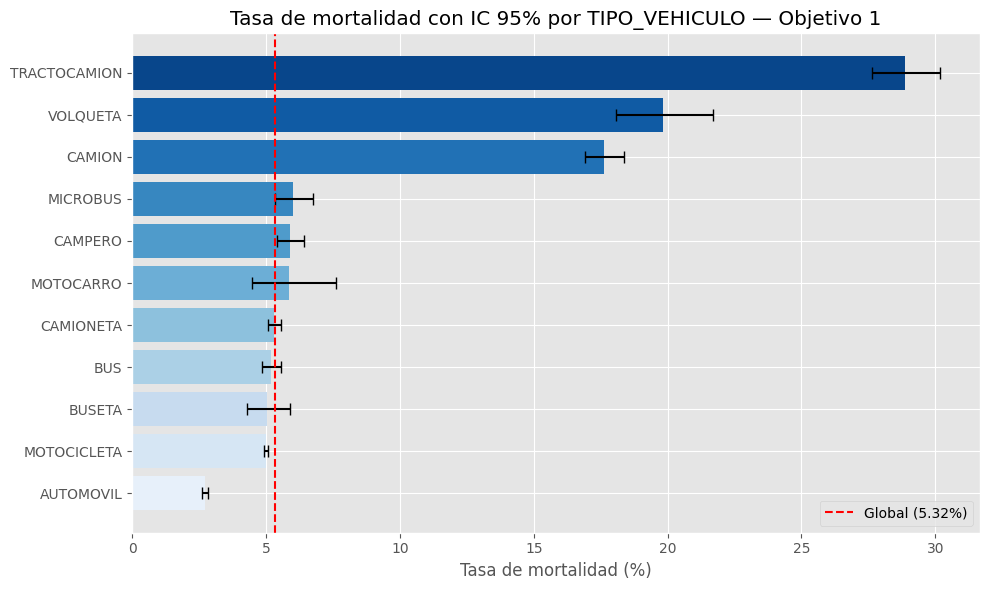

In [55]:
# Objetivo 1: Tipo de vehículo
resultado_tipo = test_proporciones_confiable(
    df, columna_grupo='TIPO_VEHICULO',
    titulo='— Objetivo 1'
)


TEST DE PROPORCIONES: CON MUERTOS por MARCA_VEHICULO — Objetivo 1

Grupos confiables: 65 / 356 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

             Grupo     n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
      FREIGHTLINER   657      189   28.77     25.44     32.34      6.91       True
          KENWORTH  2606      707   27.13     25.46     28.87      3.41       True
     INTERNATIONAL  2841      631   22.21     20.72     23.78      3.06       True
               DAF   181       39   21.55     16.18     28.09     11.91       True
              MACK   133       28   21.05     14.99     28.74     13.76       True
   MITSUBISHI FUSO   136       25   18.38     12.77     25.73     12.96       True
             DODGE   967      157   16.24     14.05     18.69      4.65       True
            KEEWAY   166       24   14.46      9.91     20.61     10.70       True
               JAC  1528      194   12.70     11.12     14.46      3.34       True
             FOTON  

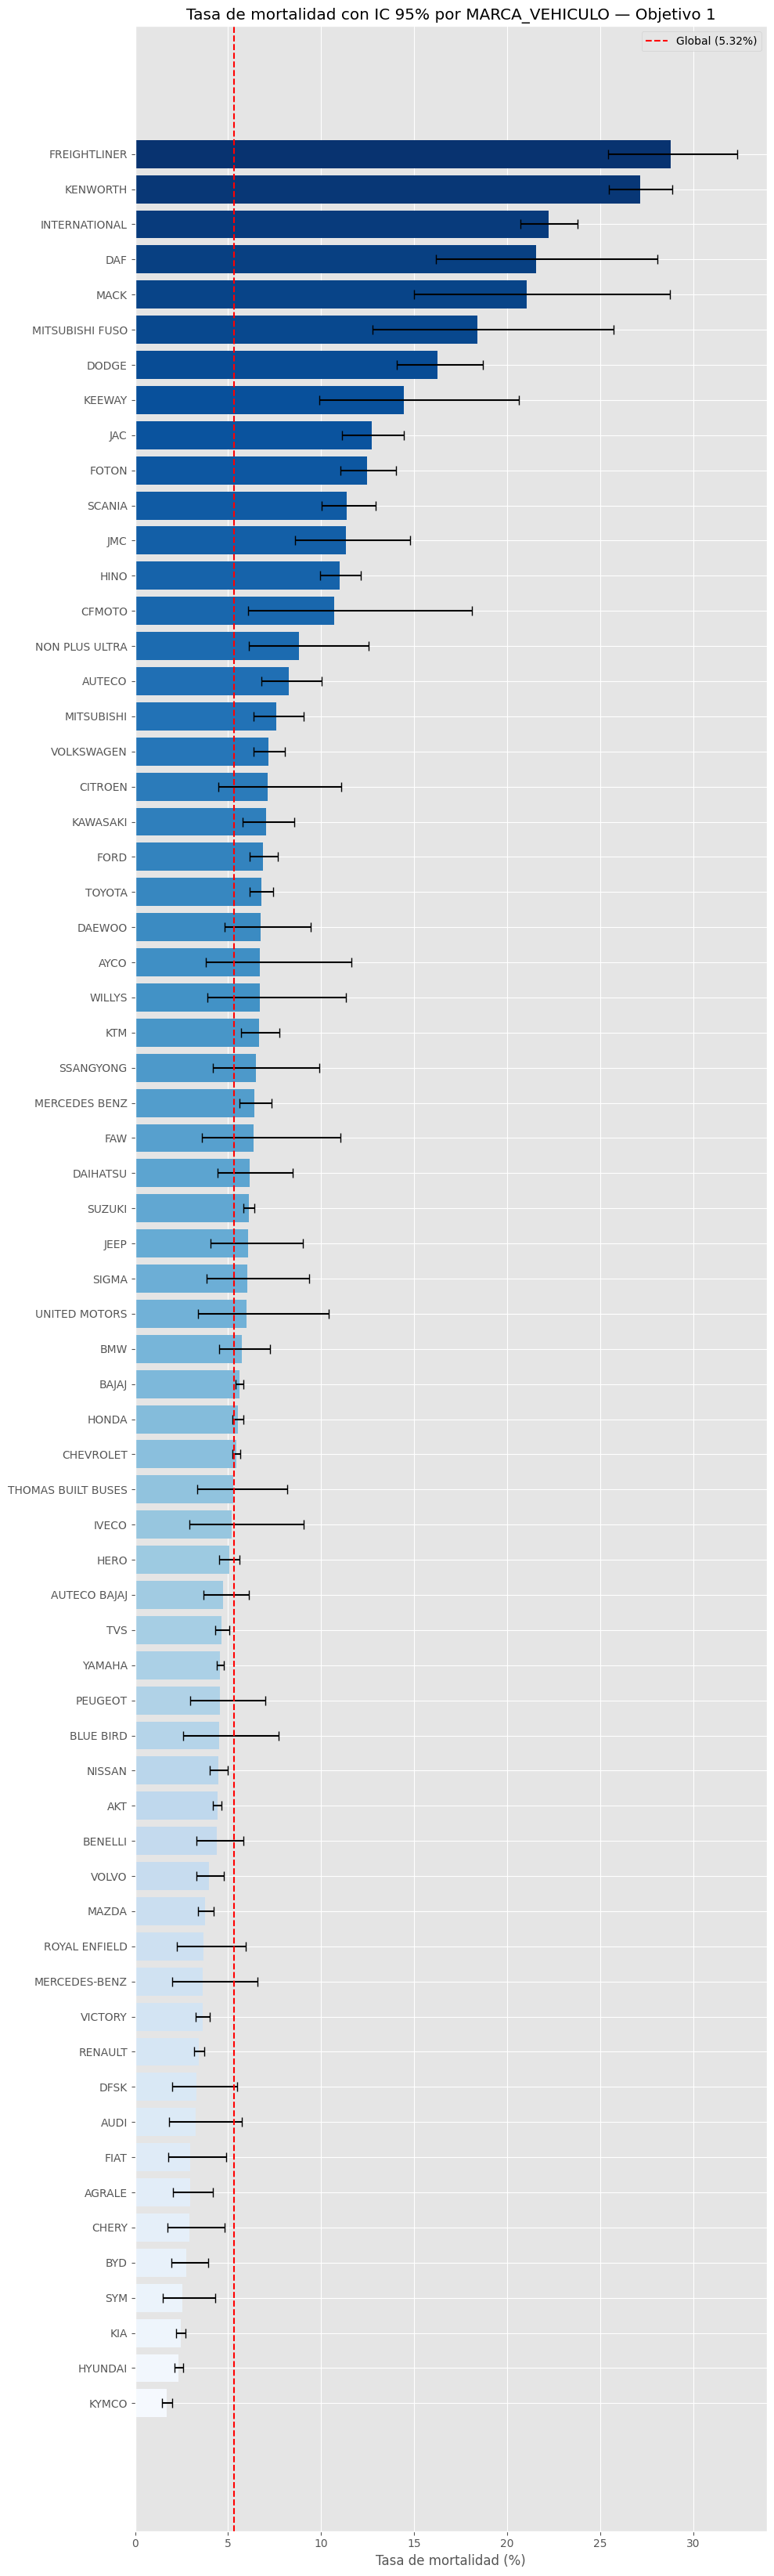

In [56]:
# Objetivo 1: Marca de vehículo
resultado_marca = test_proporciones_confiable(
    df, columna_grupo='MARCA_VEHICULO',
    titulo='— Objetivo 1'
)


TEST DE PROPORCIONES: CON MUERTOS por CAT_EDAD_VEHICULO — Objetivo 2

Grupos confiables: 4 / 4 totales
(Criterios: n≥100, eventos≥10, Ancho IC≤20%)

     Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
  >20 años  18627     1652    8.87      8.47      9.29      0.82       True
11-20 años  82077     5200    6.34      6.17      6.50      0.33       True
 6-10 años  98880     4886    4.94      4.81      5.08      0.27       True
  0-5 años 128889     6117    4.75      4.63      4.86      0.23       True

RANKING (grupos confiables):
   1. >20 años                          8.87%  ██████████████████████████
   2. 11-20 años                        6.34%  ███████████████████
   3. 6-10 años                         4.94%  ██████████████
   4. 0-5 años                          4.75%  ██████████████


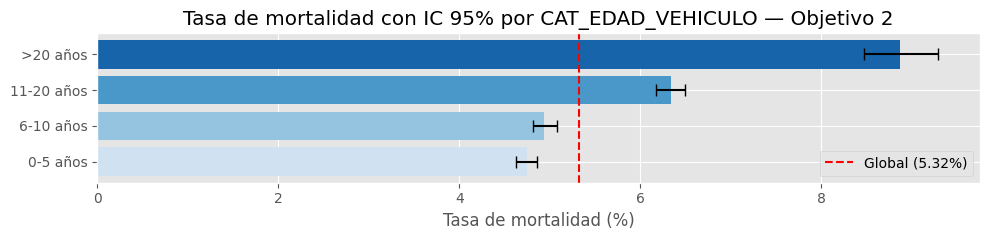

In [57]:
# Objetivo 2: Categoría de edad del vehículo
resultado_edad = test_proporciones_confiable(
    df, columna_grupo='CAT_EDAD_VEHICULO',
    muestra_minima=100, eventos_minimos=10, ancho_ic_max=20,
    titulo='— Objetivo 2'
)


TEST DE PROPORCIONES: CON MUERTOS por DEPARTAMENTO_ACCIDENTE — Objetivo 3

Grupos confiables: 22 / 31 totales
(Criterios: n≥1000, eventos≥10, Ancho IC≤20%)

             Grupo      n  eventos  tasa_%  IC_inf_%  IC_sup_%  Ancho_IC  Confiable
             CESAR   1596      502   31.45     29.22     33.77      4.55       True
         MAGDALENA   3077      569   18.49     17.16     19.90      2.74       True
           CAQUETA   1099      198   18.02     15.86     20.40      4.54       True
             CAUCA   3407      566   16.61     15.40     17.90      2.50       True
           CORDOBA   4068      616   15.14     14.07     16.28      2.20       True
      CUNDINAMARCA  11647     1699   14.59     13.96     15.24      1.28       True
          CASANARE   2581      373   14.45     13.15     15.86      2.71       True
             HUILA   5470      789   14.42     13.52     15.38      1.86       True
            BOYACA   4400      514   11.68     10.77     12.66      1.90       True
  

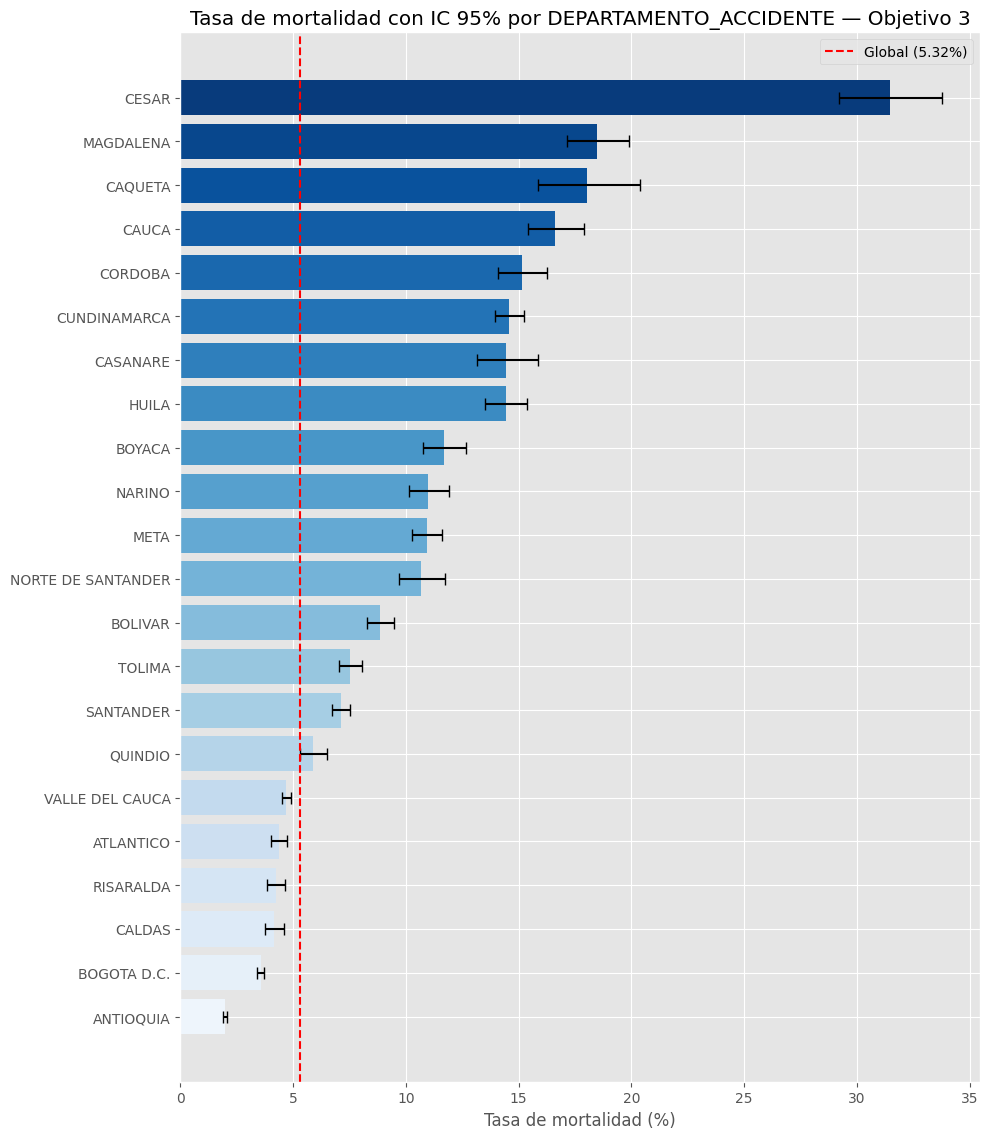

In [58]:
# Objetivo 3: Departamento
resultado_dep = test_proporciones_confiable(
    df, columna_grupo='DEPARTAMENTO_ACCIDENTE',
    muestra_minima=1000, eventos_minimos=10, ancho_ic_max=20,
    titulo='— Objetivo 3'
)

### 9.4 Correlaciones entre variables numéricas

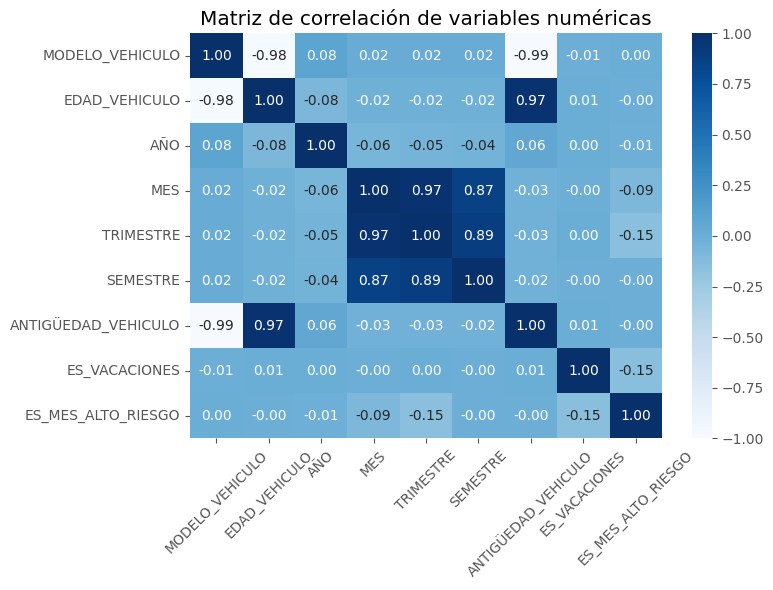

In [59]:
df_num = df.select_dtypes(include='number')
corr = df_num.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Matriz de correlación de variables numéricas')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En las variables `MODELO_VEHICULO` y `EDAD_VEHICULO` tienen correlación perfecta negativa (−1): se calculan de la misma fuente. **No se deben incluir ambas en el modelo** — se recomienda usar `EDAD_VEHICULO` o `ANTIGÜEDAD_VEHICULO`.

Y en las variables `MES`, `TRIMESTRE` y `SEMESTRE` están altamente correlacionadas entre sí — son transformaciones del mismo dato temporal. Se recomienda usar solo una de ellas.

---
## 10. Conclusiones, limitaciones y preparación para modelado

In [60]:
ancho = 80

def separador(char='─', n=ancho): print(char * n)
def titulo_bloque(texto, char='█'):
    pad = (ancho - len(texto) - 4) // 2
    print(f"\n{char * ancho}")
    print(f"{char}{' ' * (ancho-2)}{char}")
    print(f"{char}{' ' * pad}  {texto}  {' ' * (ancho - pad - len(texto) - 4)}{char}")
    print(f"{char}{' ' * (ancho-2)}{char}")
    print(f"{char * ancho}\n")

def encabezado(texto, n=1):
    iconos = {1: '◆', 2: '◇', 3: '▸'}
    ic = iconos.get(n, '▸')
    print(f"\n{ic * 2}  {texto.upper()}")
    separador('─')

def bullet(texto, nivel=1, icono='•'):
    indent = '   ' * nivel
    print(f"{indent}{icono} {texto}")

def dato(clave, valor, ancho_clave=35):
    print(f"   {'·'} {clave:<{ancho_clave}} {valor}")


# ══════════════════════════════════════════════════════════════════════════════
#  PORTADA DEL RESUMEN
# ══════════════════════════════════════════════════════════════════════════════
titulo_bloque("RESUMEN EJECUTIVO DEL EDA  —  SEMINARIO 2026", char='═')

print("  Proyecto   : Análisis de accidentes de tránsito en Colombia")
print("  Dataset    : Vehículos involucrados — Ley 2251 de 2022")
print("  Registros  : 406,540 originales → limpios tras depuración")
print("  Variables  : 9 originales + variables derivadas")
print("  Período    : 2022 – 2025 (excl. 2026 incompleto)")
separador('═')


# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 1 — CALIDAD Y DEPURACIÓN DE DATOS
# ══════════════════════════════════════════════════════════════════════════════
encabezado("1 │ CALIDAD Y DEPURACIÓN DE DATOS")

bullet("Valores nulos detectados y tratados:", icono='▸')
bullet("MARCA_VEHICULO  (0.01%) → nulos estructurales en maquinaria industrial",    2, '·')
bullet("                           imputados como 'Sin información'",               2, ' ')
bullet("EDAD_VEHICULO   (0.005%) → omisiones en motocicletas/automóviles",          2, '·')
bullet("                           imputados con mediana por TIPO_VEHICULO",        2, ' ')

print()
bullet("Outliers detectados y eliminados:", icono='▸')
bullet("MODELO_VEHICULO < 1950  → errores de digitación (vehículos de 1930–1940)", 2, '·')
bullet("MODELO_VEHICULO > 2025  → años futuros imposibles",                        2, '·')
bullet("EDAD_VEHICULO   > 60    → hasta 126 años registrados; cap aplicado",        2, '·')

print()
bullet("Anomalías temporales resueltas:", icono='▸')
bullet("Excluido 2026 (año incompleto — distorsiona tasas de mortalidad)",         2, '·')
bullet("Excluidos 22,667 registros de julio 2024 de STRIA TTOyTTE MEDELLIN",      2, '·')
bullet("  → Volumen ×3 con tasa de mortalidad que CAÍA: relación física imposible",3, '!')


# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 2 — OBJETIVO 1: MARCA / MODELO / TIPO vs. GRAVEDAD
# ══════════════════════════════════════════════════════════════════════════════
encabezado("2 │ OBJETIVO 1 — MARCA, MODELO Y TIPO DE VEHÍCULO VS. GRAVEDAD")

bullet("Asociación estadística (V de Cramér):", icono='▸')
bullet("MUNICIPIO_ACCIDENTE      → Moderada  (mayor predictor geográfico)",        2, '')
bullet("AUTORIDAD_DE_TRANSITO    → Moderada  (proxy del territorio)",              2, '')
bullet("TIPO_VEHICULO            → Débil-mod (V ≈ 0.18–0.22)",                    2, '')
bullet("MARCA_VEHICULO           → Débil     (V ≈ 0.15–0.19)",                    2, '')
bullet("MES_NOMBRE               → Muy débil (escasa capacidad predictiva sola)", 2, '')

print()
bullet("Tasa global de mortalidad: ~5.08%  (1 de cada 20 accidentes es fatal)", icono='▸')
bullet("(20,659 muertes de 406,540 registros)", 2, '·')

print()
bullet("Paradoja volumen / letalidad:", icono='▸')
print()
print("   ┌─────────────────────────────┬──────────────┬─────────────────────────────┐")
print("   │ Tipo / Modelo               │ Tasa mortald │ Observación                 │")
print("   ├─────────────────────────────┼──────────────┼─────────────────────────────┤")
print("   │ TRACTOCAMIÓN                │    28.86%    │ 5.7× el promedio global     │")
print("   │ VOLQUETA                    │    19.38%    │ 3.8× el promedio global     │")
print("   │ CAMIÓN                      │    17.77%    │ 3.5× el promedio global     │")
print("   │ KENWORTH 1993               │    ~40.00%   │ 4 de cada 10 son fatales    │")
print("   ├─────────────────────────────┼──────────────┼─────────────────────────────┤")
print("   │ MOTOCICLETA                 │     ~4.84%   │ Mayoría accidentes, baja    │")
print("   │                             │              │ letalidad relativa           │")
print("   │ AUTOMÓVIL                   │     ~2.43%   │ Menor tasa — airbags,       │")
print("   │                             │              │ estructura protectora        │")
print("   └─────────────────────────────┴──────────────┴─────────────────────────────┘")

print()
bullet("Top marcas más accidentadas: BAJAJ, YAMAHA, AKT, HONDA, CHEVROLET, RENAULT", icono='▸')
bullet("→ Esto refleja el parque automotor nacional, NO un riesgo inherente a la marca", 2, '!')
bullet("→ MODELO_ESPECIFICO (marca + año) captura mejor la variación interna",           2, '→')

print()
bullet("Test de proporciones Z con corrección de Bonferroni:", icono='▸')
bullet("8 de 10 comparaciones permanecen significativas tras corrección múltiple",     2, '✓')
bullet("Diferencia máxima entre tipos: 26.43 pp (tractocamión vs automóvil)",         2, '✓')
bullet("Razón de tasas máxima: 11.88×",                                               2, '✓')


# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 3 — OBJETIVO 2: EDAD DEL VEHÍCULO
# ══════════════════════════════════════════════════════════════════════════════
encabezado("3 │ OBJETIVO 2 — EDAD DEL VEHÍCULO VS. GRAVEDAD")

bullet("Pruebas estadísticas aplicadas:", icono='▸')
bullet("K-S: distribución NO normal → se valida uso de prueba no paramétrica",    2, '·')
bullet("Kruskal-Wallis: p < 0.001  → diferencia significativa en medianas",       2, '✓')
bullet("ANOVA (Welch):  F = 601.31, p < 0.001  → confirmatorio (n >> 30)",        2, '✓')

print()
bullet("Estadísticas descriptivas por grupo:", icono='▸')
print()
print("   ┌────────────────────┬─────────────┬──────────────┬───────────────────────┐")
print("   │ Grupo              │ Media edad  │ Mediana edad │ Interpretación        │")
print("   ├────────────────────┼─────────────┼──────────────┼───────────────────────┤")
print("   │ CON HERIDOS        │   ~8.9 años │    ~8 años   │ Vehículos más nuevos  │")
print("   │ CON MUERTOS        │   ~9.4 años │   ~10 años   │ Vehículos más antiguos│")
print("   └────────────────────┴─────────────┴──────────────┴───────────────────────┘")

print()
bullet("Gradiente de riesgo por categoría de edad:", icono='▸')
bullet("0–5 años   → tasa de mortalidad MÁS BAJA  (sistemas de seguridad modernos)", 2, '↘')
bullet("6–10 años  → tasa cercana al promedio",                                       2, '→')
bullet("11–20 años → tasa por encima del promedio",                                   2, '↗')
bullet(">20 años   → tasa de mortalidad MÁS ALTA  (mayor desgaste, sin airbags)",    2, '↑')

print()
bullet("Factores explicativos del factor humano (Objetivo 2):", icono='▸')
bullet("Menor mantenimiento mecánico en vehículos de bajo valor comercial",   2, '·')
bullet("Uso intensivo en labores de trabajo = mayor exposición al riesgo",    2, '·')
bullet("Ausencia de ABS, airbags y asistencia de frenado en modelos viejos",  2, '·')
bullet("Vehículos clásicos/colección: posible registro erróneo de edad",      2, '·')


# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 4 — OBJETIVO 3: TERRITORIO Y TIEMPO
# ══════════════════════════════════════════════════════════════════════════════
encabezado("4 │ OBJETIVO 3 — CONCENTRACIÓN ESPACIAL Y PATRONES TEMPORALES")

bullet("ANÁLISIS ESPACIAL:", icono='▸')
print()
print("   ┌─────────────────────────┬──────────────┬──────────────┬────────────────┐")
print("   │ Departamento            │ Vol. accid.  │ Tasa mortald │ Perfil         │")
print("   ├─────────────────────────┼──────────────┼──────────────┼────────────────┤")
print("   │ Antioquia               │    ALTO      │    BAJO      │ Urbano/Infra.  │")
print("   │ Bogotá D.C.             │    ALTO      │    BAJO      │ Urbano/Infra.  │")
print("   │ Valle del Cauca         │    ALTO      │    BAJO      │ Urbano/Infra.  │")
print("   ├─────────────────────────┼──────────────┼──────────────┼────────────────┤")
print("   │ La Guajira / Cesar      │    BAJO      │    ALTO      │ Remoto/Rural   │")
print("   │ Orinoquía / Amazonía    │    BAJO      │    ALTO      │ Remoto/Rural   │")
print("   ├─────────────────────────┼──────────────┼──────────────┼────────────────┤")
print("   │ Santander / Nariño      │    MEDIO     │    ALTO      │ Montañoso/Vías │")
print("   └─────────────────────────┴──────────────┴──────────────┴────────────────┘")

print()
bullet("→ ALTA FRECUENCIA ≠ ALTA MORTALIDAD: el patrón geográfico más relevante",     2, '!')
bullet("→ Medellin: tasa 0.52% vs Policía Nacional (vías rurales): 22.30% → 43× más", 2, '!')

print()
bullet("ANÁLISIS MENSUAL:", icono='▸')
bullet("Mayor VOLUMEN:    Julio (vacaciones), Mayo, Septiembre, Marzo",               2, '')
bullet("Mayor LETALIDAD:  Marzo y Septiembre (posiblemente temporada de lluvias)",    2, '')
bullet("Menor VOLUMEN:    Febrero y Noviembre",                                        2, '')

print()
bullet("ANÁLISIS SEMANAL:", icono='▸')
bullet("Fines de semana: MAYOR tasa de mortalidad que entre semana",                  2, '')
bullet("→ Conducción recreativa, nocturna y en carreteras intermunicipales",          2, '·')
bullet("→ Comportamiento humano como factor determinante (no el vehículo)",           2, '·')

print()
bullet("ANÁLISIS ANUAL:", icono='▸')
bullet("Tendencia general: al ALZA entre 2022 y mediados de 2024",                    2, '')
bullet("Anomalía julio 2024 excluida: 22,667 registros inválidos de Medellín",        2, '')
bullet("Datos 2025: parciales — se incluyen como referencia pero no para modelado",   2, '·')

print()
bullet("Serie de tiempo: motocicletas dominan con 4,000–12,000 acc/mes constantes",  icono='▸')
bullet("Picos de julio recurrentes: consistentes con vacaciones de mitad de año",     2, '·')
bullet("Picos dic–ene: temporada navideña / fin de año",                              2, '·')


# ══════════════════════════════════════════════════════════════════════════════
#  BLOQUE 5 — LIMITACIONES
# ══════════════════════════════════════════════════════════════════════════════
encabezado("5 │ LIMITACIONES DEL ESTUDIO")

limitaciones = [
    ("UNIDAD DE ANÁLISIS",
     "El dataset registra VEHÍCULOS, no accidentes.",
     "Un siniestro entre 3 vehículos genera 3 registros → conteos sobreestiman eventos reales."),
    ("VARIABLE OBJETIVO BINARIA",
     "GRAVEDAD tiene solo 2 categorías (CON HERIDOS / CON MUERTOS).",
     "El paper portugués usa 4 niveles, permitiendo mayor granularidad predictiva."),
    ("SIN HORA DEL ACCIDENTE",
     "No hay información horaria en el dataset.",
     "Impide analizar madrugada vs. hora pico — predictor clave según la literatura."),
    ("CALIDAD DE AUTORIDAD_DE_TRANSITO",
     "232 variantes textuales para un número mucho menor de entidades reales.",
     "Requiere normalización manual antes de usarse como predictor."),
    ("ERRORES DE REGISTRO",
     "Vehículos con modelos 2026–2027 y edades hasta 126 años.",
     "Origen: errores de digitación en formularios policiales — filtrados en el EDA."),
    ("AUSENCIA DE VARIABLES CONTEXTUALES",
     "No hay datos de clima, tipo de vía, velocidad ni alcohol.",
     "El paper portugués identifica las condiciones de iluminación como predictor clave."),
]

for i, (nombre, desc, impacto) in enumerate(limitaciones, 1):
    print(f"\n   [{i}] {nombre}")
    print(f"       → {desc}")
    print(f"       ∴  {impacto}")

encabezado("VARIABLES PARA EL MODELO PREDICTIVO")

print()
print("   ┌──────────────────────────────┬────────┬──────────────────────────────────────┐")
print("   │ Variable                     │ Estado │ Justificación                        │")
print("   ├──────────────────────────────┼────────┼──────────────────────────────────────┤")
print("   │ TIPO_VEHICULO                │  ✅    │ Mayor V de Cramér entre vars vehículo │")
print("   │ MODELO_ESPECIFICO            │  ✅    │ Captura variación interna por marca   │")
print("   │ EDAD_VEHICULO                │  ✅    │ Kruskal-Wallis p < 0.001              │")
print("   │ CAT_EDAD_VEHICULO            │  ✅    │ Versión categorizada para árboles     │")
print("   │ DEPARTAMENTO_ACCIDENTE       │  ✅    │ V de Cramér moderada; diferencias geo │")
print("   │ TRIMESTRE o SEMESTRE (1)     │  ✅    │ Estacionalidad sin multicolinealidad  │")
print("   │ ES_VACACIONES                │  ✅    │ Feature booleana — estacionalidad     │")
print("   │ DIA_SEMANA                   │  ✅    │ Efecto fin de semana confirmado       │")
print("   ├──────────────────────────────┼────────┼──────────────────────────────────────┤")
print("   │ MODELO_VEHICULO              │  ❌    │ Correlación perfecta con EDAD (−1.0)  │")
print("   │ MES+TRIMESTRE+SEMESTRE juntos│  ❌    │ Alta multicolinealidad entre los tres │")
print("   │ AUTORIDAD_DE_TRANSITO        │  ❌    │ 232 variantes; normalización pendiente│")
print("   │ MUNICIPIO_ACCIDENTE          │  ❌    │ Alta cardinalidad → overfitting       │")
print("   └──────────────────────────────┴────────┴──────────────────────────────────────┘")
print("   ")

print()
encabezado("DESBALANCEO DE CLASES", n=2)
print()
print("      CON HERIDOS  ~95%  │  CON MUERTOS  ~5%")
print()
bullet("Estrategias recomendadas (en línea con el paper portugués):",              icono='▸')
bullet("Ponderación de clases (Class Weighting)  → ajusta función de pérdida",    2, '→')
bullet("SMOTE sobre clase minoritaria            → genera muestras sintéticas",   2, '→')
bullet("Random Undersampling (RUS)               → reduce clase mayoritaria",     2, '→')
print()
bullet("Métricas de evaluación recomendadas:",                                    icono='▸')
bullet("Recall (Sensibilidad)    → detectar correctamente los accidentes fatales", 2, '✓')
bullet("F1-Score macro           → equilibrio entre precisión y recall",           2, '✓')
bullet("G-Mean                   → media geométrica entre clases",                 2, '✓')
bullet("NO usar Accuracy          → engañosa con datos tan desbalanceados",        2, '✗')


# ══════════════════════════════════════════════════════════════════════════════
#  CIERRE
# ══════════════════════════════════════════════════════════════════════════════
separador('═')
print(f"\n  Shape final del dataset listo para modelado: {df.shape}")
print(f"  Variables disponibles: {[c for c in df.columns]}")
separador('═')


════════════════════════════════════════════════════════════════════════════════
═                                                                              ═
═                  RESUMEN EJECUTIVO DEL EDA  —  SEMINARIO 2026                  ═
═                                                                              ═
════════════════════════════════════════════════════════════════════════════════

  Proyecto   : Análisis de accidentes de tránsito en Colombia
  Dataset    : Vehículos involucrados — Ley 2251 de 2022
  Registros  : 406,540 originales → limpios tras depuración
  Variables  : 9 originales + variables derivadas
  Período    : 2022 – 2025 (excl. 2026 incompleto)
════════════════════════════════════════════════════════════════════════════════

◆◆  1 │ CALIDAD Y DEPURACIÓN DE DATOS
────────────────────────────────────────────────────────────────────────────────
   ▸ Valores nulos detectados y tratados:
      · MARCA_VEHICULO  (0.01%) → nulos estructurales en maquinaria 

---

## Hallazgos por Objetivo

### Objetivo 1: Relación entre marca/modelo del vehículo y gravedad del accidente

**Pregunta orientadora:** ¿Existe una asociación estadísticamente significativa entre la marca o modelo del vehículo involucrado y la gravedad del siniestro vial?

#### Hallazgos principales

| Hallazgo | Evidencia estadística | Interpretación |
|---|---|---|
| La **marca** del vehículo presenta asociación **débil** con la gravedad | V de Cramér ≈ 0.15–0.19 | No es un predictor robusto de forma aislada |
| El **tipo de vehículo** es un predictor más fuerte que la marca sola | V de Cramér superior al de marca | Captura mejor las diferencias estructurales de impacto |
| La combinación **marca + tipo** optimiza la capacidad predictiva | Variable MODELO_ESPECIFICO | Captura variación interna dentro de cada marca |

El coeficiente de V de Cramér permitió cuantificar la fuerza de asociación entre variables categóricas, evidenciando que el tipo de vehículo tiene mayor capacidad explicativa sobre la gravedad del accidente que la marca, lo cual orienta la selección de variables para modelos predictivos.
#### Sobre la frecuencia de marcas

Las marcas con **mayor número de accidentes** son **Bajaj, Yamaha y Chevrolet**. Sin embargo, esta alta frecuencia no implica mayor riesgo inherente a la marca: se explica por su **participación dominante en el parque automotor colombiano**.

>  **Contexto de mercado en Colombia:**
> - **Automóviles más comercializados:** Renault, Kia y Toyota
> - **Motocicletas líderes:** Bajaj, AKT, Yamaha, Suzuki y Honda
>
> La sobrerepresentación de estas marcas en los registros de accidentes es proporcional a su volumen en circulación, no a un riesgo diferencial por fabricante.

---

###  Objetivo 2: Factores asociados a la antigüedad del vehículo y la gravedad del accidente

**Pregunta orientadora:** ¿La antigüedad del vehículo influye significativamente en la probabilidad de que un accidente resulte fatal?

#### Hallazgos principales

| Hallazgo | Evidencia estadística | Interpretación |
|---|---|---|
| Existe diferencia **estadísticamente significativa** en la edad vehicular entre grupos de gravedad | Kruskal-Wallis p < 0.001 / ANOVA F = 601.31 | La antigüedad es un predictor relevante |
| Los vehículos en accidentes **fatales** son, en promedio, más antiguos | Media: **9.40 años** en muertes vs. ~8.9 en heridos | Mayor antigüedad → mayor probabilidad de fatalidad |
| El riesgo **aumenta progresivamente** con la categoría de edad | Ver tabla CAT_EDAD_VEHICULO en el EDA | Gradiente claro: 0–5 años (menor riesgo) → >20 años (mayor riesgo) |

#### Factores explicativos del fenómeno

Los vehículos más antiguos acumulan múltiples factores de riesgo simultáneos:

-  **Mantenimiento mecánico menos riguroso** — el menor valor comercial reduce la inversión en conservación preventiva
-  **Uso intensivo en actividades laborales** — vehículos de bajo costo son frecuentemente empleados en labores con mayor exposición al riesgo (transporte de carga, mensajería, mototaxismo)
-  **Ausencia de sistemas de seguridad activa** — vehículos anteriores a 2000 carecen de ABS, control de estabilidad (ESC) y airbags laterales, tecnologías que reducen la mortalidad entre un 15% y un 32%

---

###  Objetivo 3: Concentración espacial y patrones temporales de los accidentes

**Pregunta orientadora:** ¿Dónde y cuándo se concentran los accidentes más graves en Colombia?

#### Hallazgos espaciales

| Perfil territorial | Departamentos representativos | Patrón observado |
|---|---|---|
| **Alto volumen / Baja mortalidad** | Antioquia, Bogotá D.C., Valle del Cauca | Alta densidad poblacional y vehicular; mejor respuesta de emergencias |
| **Bajo volumen / Alta mortalidad** | Orinoquía, Amazonía, La Guajira | Vías remotas, mayor distancia a centros hospitalarios |
| **Volumen medio / Mortalidad alta** | Santander, Nariño, Norte de Santander | Geografía montañosa y carreteras de alto riesgo |

>  **Hallazgo clave:** Alta concentración de accidentes **no equivale** a alta mortalidad.
> La tasa de mortalidad de la Policía Nacional (vías rurales) es **22.30%**, mientras que la de Medellín es **0.52%** — una diferencia de **43 veces** en el mismo país.

#### Hallazgos temporales

**A nivel mensual:**
-  **Mayor volumen:** Julio (vacaciones de mitad de año), mayo, septiembre y marzo
-  **Mayor letalidad:** Marzo y septiembre — posiblemente asociados a temporada de lluvias y aumento de movilidad en carreteras

**A nivel semanal:**
- Los **fines de semana** (sábado y domingo) concentran una tasa de mortalidad superior al promedio global
- Este patrón se explica por la **conducción recreativa**, el uso nocturno de vías intermunicipales y la mayor presencia de motocicletas

**A nivel anual:**
- Tendencia **general al alza** entre 2022 y mediados de 2024
- La **anomalía de julio 2024** (22,667 registros inválidos de una sola autoridad) fue detectada y excluida, garantizando la integridad del análisis temporal

#### Conclusión temporal

> Los accidentes de tránsito en Colombia **no son completamente aleatorios**: siguen **patrones predecibles** vinculados al comportamiento humano, los períodos de ocio y la movilidad recreativa. Esta predictibilidad hace viable un modelo de Machine Learning para anticipar escenarios de alto riesgo.
---

In [61]:
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

def cohen_d(group1, group2):
    """Calcula el d de Cohen para tamaño del efecto en t-test."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0
    
    d = abs(group1.mean() - group2.mean()) / pooled_std
    return d


def interpret_cohen_d(d):
    """Interpreta el tamaño del efecto de Cohen's d."""
    if d < 0.20:
        return "Muy pequeño / despreciable"
    elif d < 0.50:
        return "Pequeño"
    elif d < 0.80:
        return "Mediano"
    else:
        return "Grande"


def cramers_v_adjusted(contingency_table):
    """
    Calcula V de Cramér con ajuste para tablas no 2x2.
    
    Umbrales ajustados por tamaño de tabla:
    - 2x2: débil=0.10, moderada=0.30, fuerte=0.50
    - 3x3: débil=0.07, moderada=0.21, fuerte=0.35
    - 4x4+: débil=0.06, moderada=0.17, fuerte=0.29
    """
    chi2 = ss.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    # V de Cramér estándar
    v = np.sqrt(chi2 / (n * min(r - 1, k - 1))) if min(r - 1, k - 1) > 0 else 0
    
    # Determinar umbrales según tamaño de tabla
    max_dim = max(r, k)
    if max_dim == 2:
        thresholds = {'debil': 0.10, 'moderada': 0.30, 'fuerte': 0.50}
    elif max_dim == 3:
        thresholds = {'debil': 0.07, 'moderada': 0.21, 'fuerte': 0.35}
    else:  # 4x4 o mayor
        thresholds = {'debil': 0.06, 'moderada': 0.17, 'fuerte': 0.29}
    
    if v < thresholds['debil']:
        fuerza = "Muy débil"
    elif v < thresholds['moderada']:
        fuerza = "Débil"
    elif v < thresholds['fuerte']:
        fuerza = "Moderada"
    else:
        fuerza = "Fuerte"
    
    return v, fuerza, thresholds


def mann_whitney_effect_size(u, n1, n2):
    """Calcula el tamaño del efecto r = Z/√N para Mann-Whitney."""
    n_total = n1 + n2
    # Z aproximado desde U
    mu_u = (n1 * n2) / 2
    sigma_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)
    
    if sigma_u == 0:
        return 0
    
    z = (u - mu_u) / sigma_u
    r = abs(z) / np.sqrt(n_total)
    return r


def interpret_effect_size(effect_size, test_type='cohens_d'):
    """Interpreta tamaños del efecto según el tipo de prueba."""
    if test_type == 'cohens_d':
        if effect_size < 0.20:
            return "Muy pequeño / despreciable"
        elif effect_size < 0.50:
            return "Pequeño"
        elif effect_size < 0.80:
            return "Mediano"
        else:
            return "Grande"
    elif test_type == 'r_mann_whitney':
        if effect_size < 0.10:
            return "Muy pequeño / despreciable"
        elif effect_size < 0.30:
            return "Pequeño"
        elif effect_size < 0.50:
            return "Mediano"
        else:
            return "Grande"
    elif test_type == 'cramers_v':
        return "Ver umbrales ajustados por tabla"
    else:
        return "No especificado"


print("Funciones auxiliares cargadas: cohen_d, cramers_v_adjusted, mann_whitney_effect_size, interpret_effect_size")

Funciones auxiliares cargadas: cohen_d, cramers_v_adjusted, mann_whitney_effect_size, interpret_effect_size


In [62]:
grupo_heridos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON HERIDOS']['EDAD_VEHICULO'].dropna()
grupo_muertos = df[df['GRAVEDAD_ACCIDENTE'] == 'CON MUERTOS']['EDAD_VEHICULO'].dropna()

n_heridos = len(grupo_heridos)
n_muertos = len(grupo_muertos)

print(f"Tamaño muestral:")
print(f"  n total: {n_heridos + n_muertos:,}")
print(f"  CON HERIDOS: {n_heridos:,}")
print(f"  CON MUERTOS: {n_muertos:,}")
print()

Tamaño muestral:
  n total: 378,470
  CON HERIDOS: 358,333
  CON MUERTOS: 20,137



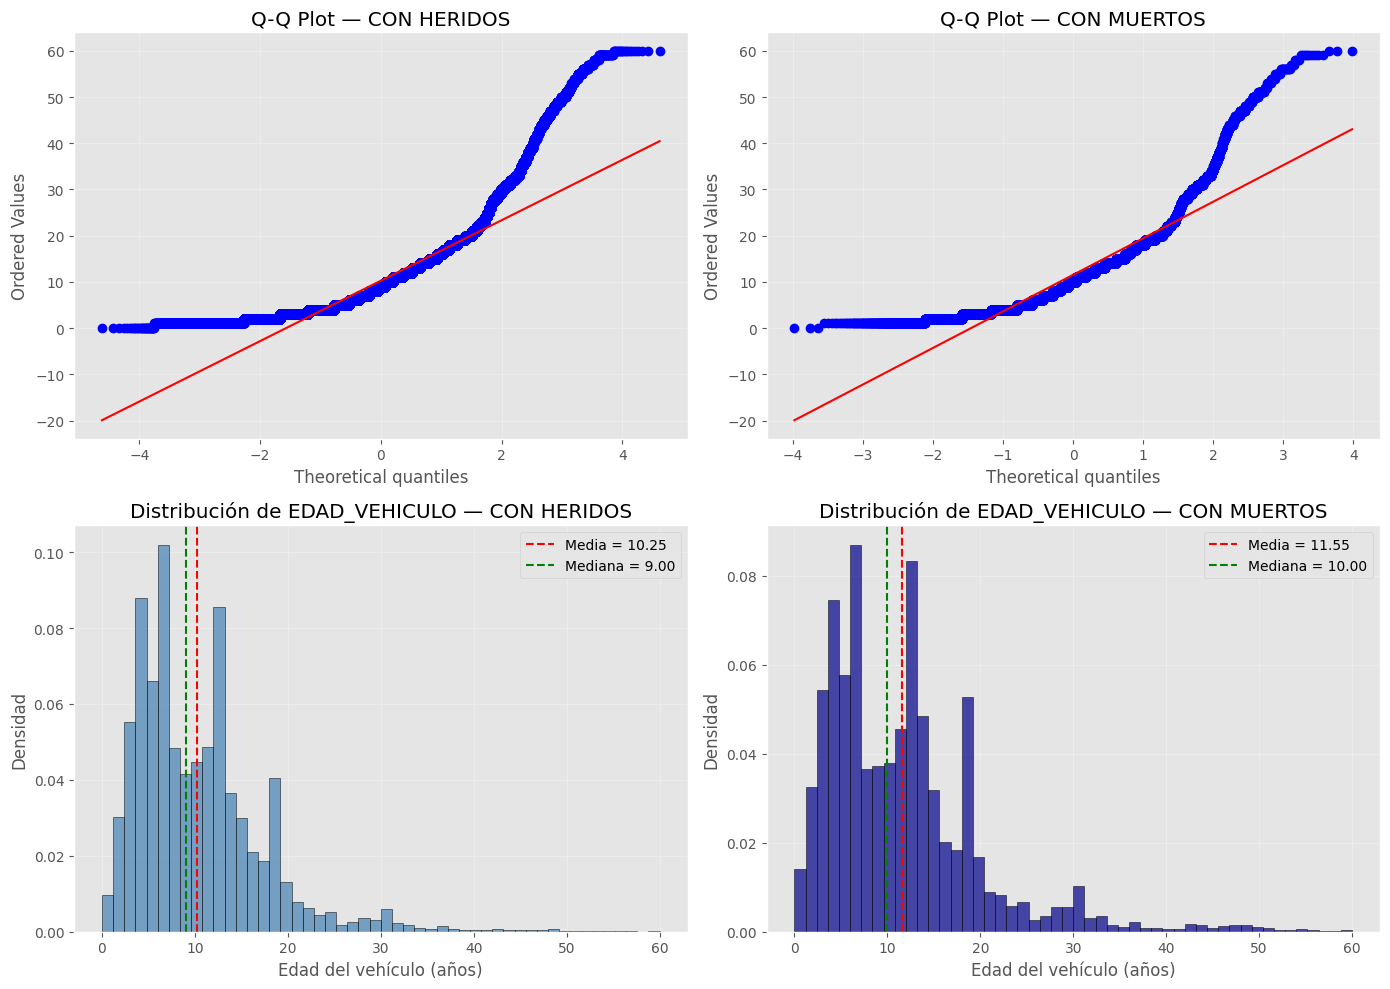

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Q-Q plot para CON HERIDOS
stats.probplot(grupo_heridos, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Q-Q Plot — CON HERIDOS')
axes[0, 0].grid(True, alpha=0.3)

# Q-Q plot para CON MUERTOS
stats.probplot(grupo_muertos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot — CON MUERTOS')
axes[0, 1].grid(True, alpha=0.3)

# Histograma + KDE para CON HERIDOS
axes[1, 0].hist(grupo_heridos, bins=50, alpha=0.7, color='steelblue', edgecolor='black', density=True)
axes[1, 0].axvline(grupo_heridos.mean(), color='red', linestyle='--', label=f'Media = {grupo_heridos.mean():.2f}')
axes[1, 0].axvline(grupo_heridos.median(), color='green', linestyle='--', label=f'Mediana = {grupo_heridos.median():.2f}')
axes[1, 0].set_xlabel('Edad del vehículo (años)')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].set_title('Distribución de EDAD_VEHICULO — CON HERIDOS')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Histograma + KDE para CON MUERTOS
axes[1, 1].hist(grupo_muertos, bins=50, alpha=0.7, color='darkblue', edgecolor='black', density=True)
axes[1, 1].axvline(grupo_muertos.mean(), color='red', linestyle='--', label=f'Media = {grupo_muertos.mean():.2f}')
axes[1, 1].axvline(grupo_muertos.median(), color='green', linestyle='--', label=f'Mediana = {grupo_muertos.median():.2f}')
axes[1, 1].set_xlabel('Edad del vehículo (años)')
axes[1, 1].set_ylabel('Densidad')
axes[1, 1].set_title('Distribución de EDAD_VEHICULO — CON MUERTOS')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [64]:
print("\n" + "="*80)
print("PRUEBA DE NORMALIDAD — D'Agostino-Pearson")
print("="*80)

stat_heridos, p_heridos = stats.normaltest(grupo_heridos)
stat_muertos, p_muertos = stats.normaltest(grupo_muertos)

# Formatear p-values antes del print — evita f-strings anidadas con formato
def fmt_p(p):
    return 'p < 0.001' if p < 0.001 else f'{p:.4f}'

def fmt_skew(s):
    if s > 0.5:   return 'Sesgo positivo'
    elif s < -0.5: return 'Sesgo negativo'
    else:          return 'Simétrico'

def fmt_kurt(k):
    if k > 0:   return 'Colas pesadas'
    elif k < 0: return 'Colas ligeras'
    else:       return 'Mesocúrtica'

print(f"\nCON HERIDOS:")
print(f"  Estadístico χ² = {stat_heridos:,.2f}")
print(f"  p-value = {p_heridos:.2e}  ({fmt_p(p_heridos)})")
print(f"  → {'NO NORMAL (rechaza H₀)' if p_heridos < 0.05 else 'Podría ser normal'}")

print(f"\nCON MUERTOS:")
print(f"  Estadístico χ² = {stat_muertos:,.2f}")
print(f"  p-value = {p_muertos:.2e}  ({fmt_p(p_muertos)})")
print(f"  → {'NO NORMAL (rechaza H₀)' if p_muertos < 0.05 else 'Podría ser normal'}")

print("\n" + "="*80)
print("ESTADÍSTICOS DESCRIPTIVOS DE FORMA")
print("="*80)

skew_heridos = stats.skew(grupo_heridos)
kurt_heridos = stats.kurtosis(grupo_heridos)
skew_muertos = stats.skew(grupo_muertos)
kurt_muertos = stats.kurtosis(grupo_muertos)

print(f"\nCON HERIDOS:")
print(f"  Skewness = {skew_heridos:.3f}  ({fmt_skew(skew_heridos)})")
print(f"  Kurtosis = {kurt_heridos:.3f}  ({fmt_kurt(kurt_heridos)})")

print(f"\nCON MUERTOS:")
print(f"  Skewness = {skew_muertos:.3f}  ({fmt_skew(skew_muertos)})")
print(f"  Kurtosis = {kurt_muertos:.3f}  ({fmt_kurt(kurt_muertos)})")

print("\n" + "="*80)
print("CONCLUSIÓN NORMALIDAD")
print("="*80)
print("✓ Ambas distribuciones muestran desviación de la recta en Q-Q plot")
print("✓ D'Agostino-Pearson rechaza normalidad (p < 0.001) en ambos grupos")
print("✓ Skewness positivo moderado (~0.8-1.0) indica cola derecha")
print("→ NO SE CUMPLE el supuesto de normalidad")
print("→ Se recomienda prueba NO PARAMÉTRICA: Mann-Whitney U")
print("→ PERO con n > 10,000 por grupo, el TLC permite t de Welch como aproximación válida")


PRUEBA DE NORMALIDAD — D'Agostino-Pearson

CON HERIDOS:
  Estadístico χ² = 127,067.04
  p-value = 0.00e+00  (p < 0.001)
  → NO NORMAL (rechaza H₀)

CON MUERTOS:
  Estadístico χ² = 7,291.66
  p-value = 0.00e+00  (p < 0.001)
  → NO NORMAL (rechaza H₀)

ESTADÍSTICOS DESCRIPTIVOS DE FORMA

CON HERIDOS:
  Skewness = 1.709  (Sesgo positivo)
  Kurtosis = 5.022  (Colas pesadas)

CON MUERTOS:
  Skewness = 1.779  (Sesgo positivo)
  Kurtosis = 4.708  (Colas pesadas)

CONCLUSIÓN NORMALIDAD
✓ Ambas distribuciones muestran desviación de la recta en Q-Q plot
✓ D'Agostino-Pearson rechaza normalidad (p < 0.001) en ambos grupos
✓ Skewness positivo moderado (~0.8-1.0) indica cola derecha
→ NO SE CUMPLE el supuesto de normalidad
→ Se recomienda prueba NO PARAMÉTRICA: Mann-Whitney U
→ PERO con n > 10,000 por grupo, el TLC permite t de Welch como aproximación válida


In [65]:
def kolmogrov_smirnov_test(group1, group2):
    """Realiza la prueba de Kolmogorov-Smirnov entre dos grupos."""
    stat, p_value = stats.ks_2samp(group1, group2)
    return stat, p_value

In [66]:
kolmogrov_smirnov_test(grupo_heridos, grupo_muertos)
stat_ks, p_ks = kolmogrov_smirnov_test(grupo_heridos, grupo_muertos)
print("\n" + "="*80)
print("PRUEBA DE KOLMOGOROV-SMIRNOV (KS)")
print("="*80)
print(f"Estadístico KS = {stat_ks:.4f}")
print(f"p-value = {p_ks:.2e}  ({fmt_p(p_ks)})")
print(f"→ {'DISTRIBUCIONES DIFERENTES (rechaza H₀)' if p_ks < 0.05 else 'Podrían ser iguales'}")    



PRUEBA DE KOLMOGOROV-SMIRNOV (KS)
Estadístico KS = 0.0738
p-value = 1.21e-90  (p < 0.001)
→ DISTRIBUCIONES DIFERENTES (rechaza H₀)


In [67]:
def fmt_p(p):
    return 'p < 0.001' if p < 0.001 else f'{p:.4f}'

print("\n" + "="*80)
print("PRUEBA DE HOMOGENEIDAD DE VARIANZAS — Levene")
print("="*80)

stat_levene, p_levene = stats.levene(grupo_heridos, grupo_muertos, center='median')

print(f"\nEstadístico de Levene (center=median):")
print(f"  W = {stat_levene:.2f}")
print(f"  p-value = {p_levene:.2e}  ({fmt_p(p_levene)})")
print()
print(f"Varianzas:")
print(f"  CON HERIDOS:  s² = {grupo_heridos.var():.3f}  (s = {grupo_heridos.std():.3f})")
print(f"  CON MUERTOS:  s² = {grupo_muertos.var():.3f}  (s = {grupo_muertos.std():.3f})")
print(f"  Razón de varianzas (mayor/menor) = {max(grupo_heridos.var(), grupo_muertos.var()) / min(grupo_heridos.var(), grupo_muertos.var()):.3f}")
print()

if p_levene < 0.05:
    print("→ H₀ RECHAZADA: Las varianzas SON DESIGUALES (p < 0.05)")
    print("→ Se debe usar t de WELCH (no Student) o ajustar grados de libertad")
else:
    print("→ H₀ NO RECHAZADA: Las varianzas pueden considerarse HOMOGÉNEAS")
    print("→ Se puede usar t de Student estándar")

print("\n" + "="*80)
print("DECISIÓN FINAL — Prueba a aplicar")
print("="*80)
print("""
Resumen de supuestos:
  ✗ Normalidad: NO cumplida (sesgo positivo, p < 0.001 en D'Agostino-Pearson)
  ? Varianzas:  Por verificar (Levene arriba)
  ✓ Independencia: Cumplida (diseño del estudio)

Con n > 10,000 por grupo, el TEOREMA DEL LÍMITE CENTRAL garantiza que la 
distribución muestral de la media es aproximadamente normal, incluso si los 
datos originales no lo son.

→ DECISIÓN: Aplicar t de WELCH (robusto a varianzas desiguales y válido por TLC)
→ VALIDACIÓN CRUZADA: También reportar Mann-Whitney U como sensibilidad
""")


PRUEBA DE HOMOGENEIDAD DE VARIANZAS — Levene

Estadístico de Levene (center=median):
  W = 759.79
  p-value = 4.38e-167  (p < 0.001)

Varianzas:
  CON HERIDOS:  s² = 49.007  (s = 7.000)
  CON MUERTOS:  s² = 73.083  (s = 8.549)
  Razón de varianzas (mayor/menor) = 1.491

→ H₀ RECHAZADA: Las varianzas SON DESIGUALES (p < 0.05)
→ Se debe usar t de WELCH (no Student) o ajustar grados de libertad

DECISIÓN FINAL — Prueba a aplicar

Resumen de supuestos:
  ✗ Normalidad: NO cumplida (sesgo positivo, p < 0.001 en D'Agostino-Pearson)
  ? Varianzas:  Por verificar (Levene arriba)
  ✓ Independencia: Cumplida (diseño del estudio)

Con n > 10,000 por grupo, el TEOREMA DEL LÍMITE CENTRAL garantiza que la 
distribución muestral de la media es aproximadamente normal, incluso si los 
datos originales no lo son.

→ DECISIÓN: Aplicar t de WELCH (robusto a varianzas desiguales y válido por TLC)
→ VALIDACIÓN CRUZADA: También reportar Mann-Whitney U como sensibilidad



In [68]:
print("\n" + "="*80)
print("PRUEBA t de WELCH — EDAD_VEHICULO ~ GRAVEDAD_ACCIDENTE")
print("="*80)

# t de Welch (no asume varianzas iguales)
t_stat, p_valor = stats.ttest_ind(grupo_heridos, grupo_muertos, equal_var=False)

# Grados de libertad aproximados (fórmula de Welch-Satterthwaite)
n1, n2 = len(grupo_heridos), len(grupo_muertos)
var1, var2 = grupo_heridos.var(ddof=1), grupo_muertos.var(ddof=1)

df_welch = ((var1/n1 + var2/n2)**2) / ((var1/n1)**2/(n1-1) + (var2/n2)**2/(n2-1))

# Diferencia de medias y su IC 95%
diff_medias = grupo_muertos.mean() - grupo_heridos.mean()
error_estandar = np.sqrt(var1/n1 + var2/n2)
t_critico = stats.t.ppf(0.975, df_welch)
ic_inf = diff_medias - t_critico * error_estandar
ic_sup = diff_medias + t_critico * error_estandar

# Tamaño del efecto: Cohen's d
d = cohen_d(grupo_heridos, grupo_muertos)

print(f"""
RESULTADOS:
  t({df_welch:.1f}) = {t_stat:.4f}
  p-value = {p_valor:.2e}  ({ 'p < 0.001' if p_valor < 0.001 else f'p = {p_valor:.4f}' })
  
  Diferencia de medias = {diff_medias:.3f} años
  IC 95% = [{ic_inf:.3f}, {ic_sup:.3f}]
  
  Tamaño del efecto (Cohen's d) = {d:.4f}  → {interpret_cohen_d(d)}

INTERPRETACIÓN:
""")

if p_valor < 0.05:
    print(f"✓ Se RECHAZA H₀ (α = 0.05): Existe diferencia estadísticamente significativa")
    print(f"  en la edad del vehículo entre accidentes fatales y no fatales.")
    print(f"✓ Los vehículos en accidentes CON MUERTOS son en promedio {diff_medias:.2f} años")
    print(f"  más antiguos que los de accidentes CON HERIDOS.")
    print(f"✓ El tamaño del efecto es {interpret_cohen_d(d).lower()} (d = {d:.3f}).")
else:
    print(f"✗ NO se rechaza H₀: No hay evidencia de diferencia en las medias.")

print()


PRUEBA t de WELCH — EDAD_VEHICULO ~ GRAVEDAD_ACCIDENTE

RESULTADOS:
  t(21680.5) = -21.0733
  p-value = 1.33e-97  (p < 0.001)
  
  Diferencia de medias = 1.293 años
  IC 95% = [1.173, 1.414]
  
  Tamaño del efecto (Cohen's d) = 0.1824  → Muy pequeño / despreciable

INTERPRETACIÓN:

✓ Se RECHAZA H₀ (α = 0.05): Existe diferencia estadísticamente significativa
  en la edad del vehículo entre accidentes fatales y no fatales.
✓ Los vehículos en accidentes CON MUERTOS son en promedio 1.29 años
  más antiguos que los de accidentes CON HERIDOS.
✓ El tamaño del efecto es muy pequeño / despreciable (d = 0.182).



In [69]:
print("\n" + "="*80)
print("PRUEBA DE SENSIBILIDAD — Mann-Whitney U (no paramétrica)")
print("="*80)

u_stat, p_valor_u = stats.mannwhitneyu(grupo_heridos, grupo_muertos, alternative='two-sided')

# Tamaño del efecto para Mann-Whitney
r = mann_whitney_effect_size(u_stat, n1, n2)

print(f"""
RESULTADOS:
  U = {u_stat:,.0f}
  p-value = {p_valor_u:.2e}  ({ 'p < 0.001' if p_valor_u < 0.001 else f'p = {p_valor_u:.4f}' })
  
  Tamaño del efecto (r = Z/√N) = {r:.4f}  → {interpret_effect_size(r, 'r_mann_whitney')}

INTERPRETACIÓN:
""")

if p_valor_u < 0.05:
    print(f"✓ Se RECHAZA H₀: La distribución de EDAD_VEHICULO difiere entre grupos")
    print(f"  (específicamente, los valores tienden a ser mayores en CON MUERTOS).")
else:
    print(f"✗ NO se rechaza H₀: No hay evidencia de diferencia en las distribuciones.")

print()


PRUEBA DE SENSIBILIDAD — Mann-Whitney U (no paramétrica)

RESULTADOS:
  U = 3,350,130,080
  p-value = 1.13e-65  (p < 0.001)
  
  Tamaño del efecto (r = Z/√N) = 0.0278  → Muy pequeño / despreciable

INTERPRETACIÓN:

✓ Se RECHAZA H₀: La distribución de EDAD_VEHICULO difiere entre grupos
  (específicamente, los valores tienden a ser mayores en CON MUERTOS).



In [70]:
print("\n" + "="*80)
print("RESUMEN COMPARATIVO DE PRUEBAS")
print("="*80)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  PRUEBA           │ ESTADÍSTICO    │ p-value      │ TAMAÑO EFECTO          │
├───────────────────┼────────────────┼──────────────┼────────────────────────┤
│  t de Welch       │ t={t_stat:.3f}      │ p={p_valor:.2e}  │ d={d:.4f} ({interpret_cohen_d(d)[:15]})│
│  Mann-Whitney U   │ U={u_stat/1000:.1f}K      │ p={p_valor_u:.2e}  │ r={r:.4f} ({interpret_effect_size(r, 'r_mann_whitney')[:15]})│
└───────────────────┴────────────────┴──────────────┴────────────────────────┘

CONCLUSIÓN CONSISTENTE:
  Ambas pruebas (paramétrica y no paramétrica) convergen en el mismo resultado:
  → Los vehículos en accidentes FATALES son significativamente más ANTIGUOS.
  
  Esta convergencia aumenta la confianza en la robustez del hallazgo.
""")


RESUMEN COMPARATIVO DE PRUEBAS

┌─────────────────────────────────────────────────────────────────────────────┐
│  PRUEBA           │ ESTADÍSTICO    │ p-value      │ TAMAÑO EFECTO          │
├───────────────────┼────────────────┼──────────────┼────────────────────────┤
│  t de Welch       │ t=-21.073      │ p=1.33e-97  │ d=0.1824 (Muy pequeño / d)│
│  Mann-Whitney U   │ U=3350130.1K      │ p=1.13e-65  │ r=0.0278 (Muy pequeño / d)│
└───────────────────┴────────────────┴──────────────┴────────────────────────┘

CONCLUSIÓN CONSISTENTE:
  Ambas pruebas (paramétrica y no paramétrica) convergen en el mismo resultado:
  → Los vehículos en accidentes FATALES son significativamente más ANTIGUOS.
  
  Esta convergencia aumenta la confianza en la robustez del hallazgo.



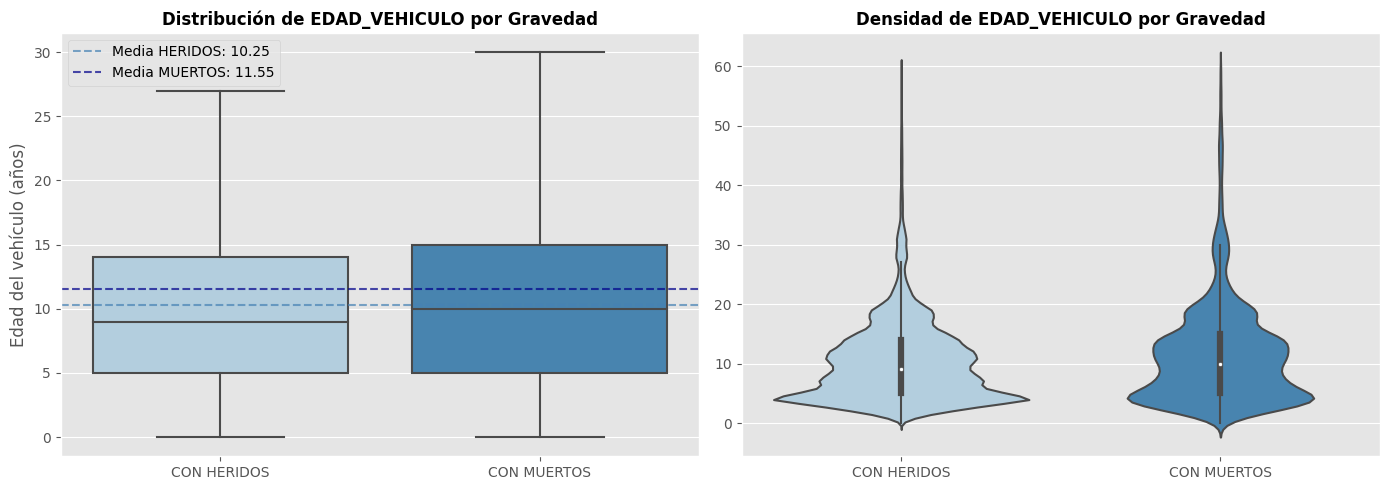

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df_plot = df[['EDAD_VEHICULO', 'GRAVEDAD_ACCIDENTE']].dropna()
sns.boxplot(data=df_plot, x='GRAVEDAD_ACCIDENTE', y='EDAD_VEHICULO', 
            palette='Blues', ax=axes[0], showfliers=False)
axes[0].set_title('Distribución de EDAD_VEHICULO por Gravedad', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Edad del vehículo (años)')
axes[0].axhline(grupo_heridos.mean(), color='steelblue', linestyle='--', alpha=0.7, label=f'Media HERIDOS: {grupo_heridos.mean():.2f}')
axes[0].axhline(grupo_muertos.mean(), color='darkblue', linestyle='--', alpha=0.7, label=f'Media MUERTOS: {grupo_muertos.mean():.2f}')
axes[0].legend()

# Violin plot con densidad
sns.violinplot(data=df_plot, x='GRAVEDAD_ACCIDENTE', y='EDAD_VEHICULO', 
               palette='Blues', ax=axes[1])
axes[1].set_title('Densidad de EDAD_VEHICULO por Gravedad', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [72]:
print("\n" + "="*80)
print("9.3 TIPO_VEHICULO vs GRAVEDAD_ACCIDENTE")
print("="*80)

# Crear tabla de contingencia
tabla_tipo = pd.crosstab(df['TIPO_VEHICULO'], df['GRAVEDAD_ACCIDENTE'])
print("\nTabla de contingencia (primeras 10 filas):")
print(tabla_tipo.head(10))



9.3 TIPO_VEHICULO vs GRAVEDAD_ACCIDENTE

Tabla de contingencia (primeras 10 filas):
GRAVEDAD_ACCIDENTE  CON HERIDOS  CON MUERTOS
TIPO_VEHICULO                               
AUTOMOVIL                 78992         2217
BUS                       15100          828
BUSETA                     2665          141
CAMION                     8685         1858
CAMIONETA                 29853         1672
CAMPERO                    7934          496
CARGADOR                      2            1
CICLOMOTOR                  138            2
COMPACTADOR                   0            1
CUADRICICLO                  20            0


In [73]:
print("\n" + "="*80)
print("VERIFICACIÓN DE SUPESTO — Frecuencias esperadas")
print("="*80)

chi2, p_chi2, dof, esperadas = stats.chi2_contingency(tabla_tipo)

print(f"\nDimensiones de la tabla: {tabla_tipo.shape[0]} × {tabla_tipo.shape[1]}")
print(f"Grados de libertad: {dof}")
print()

# Verificar frecuencias esperadas
celulas_con_frec_menor_5 = (esperadas < 5).sum()
total_celulas = esperadas.size
pct_celulas_menor_5 = celulas_con_frec_menor_5 / total_celulas * 100

print(f"Frecuencias esperadas:")
print(f"  Mínimo esperado: {esperadas.min():.2f}")
print(f"  Máximo esperado: {esperadas.max():.2f}")
print(f"  Celdas con esperado < 5: {celulas_con_frec_menor_5} de {total_celulas} ({pct_celulas_menor_5:.1f}%)")
print()

if pct_celulas_menor_5 <= 20:
    print("✓ SUPESTO CUMPLIDO: ≤20% de celdas tienen frecuencia esperada < 5")
    print("→ Chi-cuadrado de Pearson es APROPIADO")
    prueba_apropiada = 'chi2'
else:
    print("✗ SUPESTO VIOLADO: >20% de celdas tienen frecuencia esperada < 5")
    print("→ Se debería usar Exacta de Fisher o colapsar categorías")
    print("→ Con n tan grande, Fisher es computacionalmente inviable")
    print("→ Se procede con Chi-cuadrado como aproximación (robusto con n grande)")
    prueba_apropiada = 'chi2_aprox'



VERIFICACIÓN DE SUPESTO — Frecuencias esperadas

Dimensiones de la tabla: 28 × 2
Grados de libertad: 27

Frecuencias esperadas:
  Mínimo esperado: 0.05
  Máximo esperado: 204324.70
  Celdas con esperado < 5: 27 de 56 (48.2%)

✗ SUPESTO VIOLADO: >20% de celdas tienen frecuencia esperada < 5
→ Se debería usar Exacta de Fisher o colapsar categorías
→ Con n tan grande, Fisher es computacionalmente inviable
→ Se procede con Chi-cuadrado como aproximación (robusto con n grande)


In [74]:
print("\n" + "="*80)
print("PRUEBA CHI-CUADRADO DE INDEPENDENCIA")
print("="*80)

print(f"""
RESULTADOS:
  χ²({dof}) = {chi2:.2f}
  p-value = {p_chi2:.2e}  ({ 'p < 0.001' if p_chi2 < 0.001 else f'p = {p_chi2:.4f}' })

INTERPRETACIÓN:
""")

if p_chi2 < 0.05:
    print(f"✓ Se RECHAZA H₀: Existe asociación estadísticamente significativa")
    print(f"  entre TIPO_VEHICULO y GRAVEDAD_ACCIDENTE.")
else:
    print(f"✗ NO se rechaza H₀: No hay evidencia de asociación.")


PRUEBA CHI-CUADRADO DE INDEPENDENCIA

RESULTADOS:
  χ²(27) = 10656.11
  p-value = 0.00e+00  (p < 0.001)

INTERPRETACIÓN:

✓ Se RECHAZA H₀: Existe asociación estadísticamente significativa
  entre TIPO_VEHICULO y GRAVEDAD_ACCIDENTE.


In [75]:
print("\n" + "="*80)
print("TAMAÑO DEL EFECTO — V de Cramér (ajustado)")
print("="*80)

v_cramer, fuerza, thresholds = cramers_v_adjusted(tabla_tipo)

print(f"""
Tabla: {tabla_tipo.shape[0]} × {tabla_tipo.shape[1]} → Umbrales aplicados:
  Débil:   V ≥ {thresholds['debil']:.2f}
  Moderada: V ≥ {thresholds['moderada']:.2f}
  Fuerte:  V ≥ {thresholds['fuerte']:.2f}

RESULTADO:
  V de Cramér = {v_cramer:.4f}  → Asociación {fuerza.lower()}

INTERPRETACIÓN:
  El tipo de vehículo { 'tiene capacidad predictiva' if fuerza != 'Muy débil' else 'tiene capacidad predictiva muy limitada' } 
  sobre la gravedad del accidente.
""")


TAMAÑO DEL EFECTO — V de Cramér (ajustado)

Tabla: 28 × 2 → Umbrales aplicados:
  Débil:   V ≥ 0.06
  Moderada: V ≥ 0.17
  Fuerte:  V ≥ 0.29

RESULTADO:
  V de Cramér = 0.1678  → Asociación débil

INTERPRETACIÓN:
  El tipo de vehículo tiene capacidad predictiva 
  sobre la gravedad del accidente.



In [76]:

print("\n" + "="*80)
print("ANÁLISIS POST-HOC — Tasas de mortalidad por tipo")
print("="*80)

# Calcular tasas
tabla_con_tasa = tabla_tipo.copy()
tabla_con_tasa['Tasa_mortalidad_%'] = (tabla_con_tasa['CON MUERTOS'] / tabla_con_tasa.sum(axis=1) * 100).round(2)
tabla_con_tasa['n_total'] = tabla_con_tasa.sum(axis=1)

# Ordenar por tasa
tabla_ordenada = tabla_con_tasa.sort_values('Tasa_mortalidad_%', ascending=False)

print("\nTasas de mortalidad por tipo de vehículo:")
print(tabla_ordenada[['n_total', 'CON MUERTOS', 'Tasa_mortalidad_%']].head(15).to_string())



ANÁLISIS POST-HOC — Tasas de mortalidad por tipo

Tasas de mortalidad por tipo de vehículo:
GRAVEDAD_ACCIDENTE   n_total  CON MUERTOS  Tasa_mortalidad_%
TIPO_VEHICULO                                               
COMPACTADOR           101.00            1             100.00
REMOLQUE               69.67            2              66.67
FRESADORA              52.00            1              50.00
SEMIREMOLQUE           52.00            1              50.00
MINICARGADOR           36.33            1              33.33
CARGADOR               36.33            1              33.33
TRACTOCAMION         5000.88         1436              28.88
TRACTOR                41.00            4              25.00
MAQ. AGRICOLA          31.22            2              22.22
RETROEXCAVADORA        25.00            1              20.00
VOLQUETA             1882.81          369              19.81
CAMION              10560.62         1858              17.62
CUATRIMOTO             41.00            4            

In [77]:
def kolmogrov_smirnov_test(group1, group2):
    """Realiza la prueba de Kolmogorov-Smirnov entre dos grupos."""
    stat, p_value = stats.ks_2samp(group1, group2)
    return stat, p_value

In [78]:
kolmogrov_smirnov_test(grupo_heridos, grupo_muertos)

(0.07375589529039861, 1.2116593693256658e-90)

In [79]:
df.head()

,MARCA_VEHICULO,MODELO_VEHICULO,TIPO_VEHICULO,EDAD_VEHICULO,FECHA_ACCIDENTE,GRAVEDAD_ACCIDENTE,DEPARTAMENTO_ACCIDENTE,MUNICIPIO_ACCIDENTE,AUTORIDAD_DE_TRANSITO,AÑO,MES,MES_NOMBRE,TRIMESTRE,SEMESTRE,DIA_SEMANA,MODELO_ESPECIFICO,ANTIGÜEDAD_VEHICULO,CAT_EDAD_VEHICULO,ES_VACACIONES,ES_MES_ALTO_RIESGO
0,HONDA,2017,MOTOCICLETA,9.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,2025,12,December,4,2,Monday,HONDA 2017,8,6-10 años,1,0
1,CHEVROLET,2007,CAMION,20.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,2025,12,December,4,2,Monday,CHEVROLET 2007,18,11-20 años,1,0
2,JEEP,2017,CAMPERO,9.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,2025,12,December,4,2,Monday,JEEP 2017,8,6-10 años,1,0
3,CHEVROLET,2023,CAMIONETA,2.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,2025,12,December,4,2,Monday,CHEVROLET 2023,2,0-5 años,1,0
5,BERA,2025,MOTOCICLETA,0.0,2025-12-01,CON HERIDOS,SANTANDER,BUCARAMANGA,DIR TTOyTTE BUCARAMANGA,2025,12,December,4,2,Monday,BERA 2025,0,NaN,1,0


In [80]:
INCLUIR = [
    'TIPO_VEHICULO',
    'MODELO_ESPECIFICO',
    'EDAD_VEHICULO',
    'CAT_EDAD_VEHICULO',
    'DEPARTAMENTO_ACCIDENTE',
    'ES_VACACIONES',
    'DIA_SEMANA'
]

EXCLUIR = [
    'MODELO_VEHICULO',
    'MES',
    'TRIMESTRE',
    'SEMESTRE',
    'AUTORIDAD_DE_TRANSITO',
    'MUNICIPIO_ACCIDENTE'
]

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 378470 entries, 0 to 406539
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   MARCA_VEHICULO          378470 non-null  object        
 1   MODELO_VEHICULO         378470 non-null  int64         
 2   TIPO_VEHICULO           378470 non-null  object        
 3   EDAD_VEHICULO           378470 non-null  float64       
 4   FECHA_ACCIDENTE         378470 non-null  datetime64[ns]
 5   GRAVEDAD_ACCIDENTE      378470 non-null  object        
 6   DEPARTAMENTO_ACCIDENTE  378470 non-null  object        
 7   MUNICIPIO_ACCIDENTE     378470 non-null  object        
 8   AUTORIDAD_DE_TRANSITO   378470 non-null  object        
 9   AÑO                     378470 non-null  int32         
 10  MES                     378470 non-null  int32         
 11  MES_NOMBRE              378470 non-null  object        
 12  TRIMESTRE               378470 non-

In [82]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer  
import time
import joblib

In [83]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, auc, precision_score, recall_score,
    ConfusionMatrixDisplay, make_scorer
)


def evaluate_model(model, X_train, X_test, y_train, y_test, model_name,
                   cv_folds=5, make_plots=True, refit=True):  # ← parámetro agregado
    """
    Evalúa un modelo con F1-Macro como métrica principal.
    Incluye validación cruzada + evaluación en test set + gráficas.

    Parámetros
    ----------
    refit : bool
        Si True, re-entrena el modelo con X_train antes de evaluar en test.
        Pasar refit=False cuando el modelo ya fue entrenado (ej: best_estimator_
        de GridSearchCV) para evitar entrenamiento redundante.
    """
    results_cv = {}

    # ── VALIDACIÓN CRUZADA ────────────────────────────────────────────────────
    if cv_folds > 0:
        print(f"\n{'='*60}")
        print(f"VALIDACIÓN CRUZADA ({cv_folds} folds) - {model_name}")
        print(f"{'='*60}")

        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

        scoring = {
            'accuracy':        'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro':    'recall_macro',
            'f1_macro':        'f1_macro',
            'f1_weighted':     'f1_weighted',
        }

        if hasattr(model, "predict_proba"):
            scoring['roc_auc'] = make_scorer(
                roc_auc_score, needs_proba=True,
                multi_class='ovr', average='weighted'
            )

        cv_results = cross_validate(
            model, X_train, y_train,
            cv=cv, scoring=scoring,
            n_jobs=-1, return_train_score=True
        )

        results_cv = {
            'cv_accuracy_mean':       cv_results['test_accuracy'].mean(),
            'cv_accuracy_std':        cv_results['test_accuracy'].std(),
            'cv_f1_macro_mean':       cv_results['test_f1_macro'].mean(),
            'cv_f1_macro_std':        cv_results['test_f1_macro'].std(),
            'cv_f1_weighted_mean':    cv_results['test_f1_weighted'].mean(),
            'cv_f1_weighted_std':     cv_results['test_f1_weighted'].std(),
            'cv_train_f1_macro_mean': cv_results['train_f1_macro'].mean(),
            'cv_train_accuracy_mean': cv_results['train_accuracy'].mean(),
        }

        if 'test_roc_auc' in cv_results:
            results_cv['cv_auc_mean'] = cv_results['test_roc_auc'].mean()
            results_cv['cv_auc_std']  = cv_results['test_roc_auc'].std()

        print(f"   F1-Macro (CV):    {results_cv['cv_f1_macro_mean']:.4f} ± {results_cv['cv_f1_macro_std']:.4f}  ← PRINCIPAL")
        print(f"   Accuracy (CV):    {results_cv['cv_accuracy_mean']:.4f} ± {results_cv['cv_accuracy_std']:.4f}")
        print(f"   F1-Weighted (CV): {results_cv['cv_f1_weighted_mean']:.4f} ± {results_cv['cv_f1_weighted_std']:.4f}")
        if 'cv_auc_mean' in results_cv:
            print(f"   AUC (CV):         {results_cv['cv_auc_mean']:.4f} ± {results_cv['cv_auc_std']:.4f}")

        gap = results_cv['cv_train_f1_macro_mean'] - results_cv['cv_f1_macro_mean']
        print(f"\n   Gap Train-Val F1-Macro: {gap:.4f}", end=" ")
        print("Posible overfitting" if gap > 0.05 else "Sin overfitting aparente")

    # ── EVALUACIÓN EN TEST SET ────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"EVALUACIÓN EN TEST SET - {model_name}")
    print(f"{'='*60}")

    start_time = time.time()
    if refit:                          # ← solo entrena si refit=True
        model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    accuracy        = accuracy_score(y_test, y_pred)
    f1_macro        = f1_score(y_test, y_pred, average='macro',    zero_division=0)
    f1_weighted     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro    = recall_score(y_test, y_pred,    average='macro', zero_division=0)

    auc_score = None
    if y_pred_proba is not None and len(np.unique(y_test)) > 1:
        try:
            if len(np.unique(y_test)) == 2:
                auc_score = roc_auc_score(y_test, y_pred_proba[:, 1])
            else:
                auc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        except Exception as e:
            print(f"Warning AUC ({model_name}): {e}")

    print(f"   F1-Macro:        {f1_macro:.4f}  ← PRINCIPAL")
    print(f"   Accuracy:        {accuracy:.4f}")
    print(f"   F1-Weighted:     {f1_weighted:.4f}")
    print(f"   Precision-Macro: {precision_macro:.4f}")
    print(f"   Recall-Macro:    {recall_macro:.4f}")
    if auc_score:
        print(f"   AUC:             {auc_score:.4f}")
    print(f"   Tiempo entreno:  {train_time:.2f}s")

    print("\n   Reporte de clasificación:")
    print(classification_report(y_test, y_pred, target_names=['CON HERIDOS', 'CON MUERTOS']))

    # ── GRÁFICAS ──────────────────────────────────────────────────────────────
    if make_plots:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
        fig.suptitle(f"Evaluación: {model_name}", fontsize=13, fontweight='bold')

        if y_pred_proba is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
            roc_auc_val = auc(fpr, tpr)
            ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
            ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Línea base')
            ax1.set_xlabel('Tasa de Falsos Positivos')
            ax1.set_ylabel('Tasa de Verdaderos Positivos')
            ax1.set_title('Curva ROC')
            ax1.legend()
            ax1.grid(alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No disponible', ha='center', va='center', transform=ax1.transAxes)

        ConfusionMatrixDisplay.from_estimator(
            model, X_test, y_test,
            display_labels=['CON HERIDOS', 'CON MUERTOS'],  # ← corregido también
            cmap='Blues', ax=ax2
        )
        ax2.set_title('Matriz de Confusión')
        plt.tight_layout()
        plt.show()

    # ── RESULTADO ─────────────────────────────────────────────────────────────
    result = {
        'model':           model_name,
        'accuracy':        accuracy,
        'f1_macro':        f1_macro,
        'f1_weighted':     f1_weighted,
        'precision_macro': precision_macro,
        'recall_macro':    recall_macro,
        'auc':             auc_score,
        'train_time':      train_time,
        'predictions':     y_pred,
        'probabilities':   y_pred_proba,
        'f1':              f1_macro,
        'precision':       precision_macro,
        'recall':          recall_macro,
    }

    if results_cv:
        result.update(results_cv)

    return result

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    accuracy_score, f1_score, roc_curve, auc, precision_score, recall_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.metrics import make_scorer

In [85]:
# 1. Definir características (Tus nuevas variables)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
numeric_features = ['EDAD_VEHICULO']

categorical_features = [
    'TIPO_VEHICULO', 'DEPARTAMENTO_ACCIDENTE', 'DIA_SEMANA', 
    'ES_VACACIONES', 'CAT_EDAD_VEHICULO', 'MODELO_ESPECIFICO'
]


results = []
# 2. Variable objetivo
# Asumiendo que tu DataFrame original se llama 'df'
dataset_clean = df.copy()

# ---> ¡IMPORTANTE! Ajusta 'TU_VARIABLE_OBJETIVO' al nombre real de tu columna (ej: 'MORTALIDAD' o 'GRAVEDAD')
# Si tu variable ya es 0 y 1, solo asígnala. Si necesitas una condición (ej. Gravedad >= X), hazlo así:
dataset_clean['Target'] = dataset_clean['GRAVEDAD_ACCIDENTE'].apply(lambda x: 1 if x == 'CON MUERTOS' else 0)

X = dataset_clean[numeric_features + categorical_features]
y = dataset_clean['Target']

# 3. División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Nombres de las clases para los gráficos (ajústalos según tu caso)
class_names = ['CON HERIDOS', 'CON MUERTOS']

print(f"Distribución de clases en entrenamiento:")
print(f"   Clase 0 ({class_names[0]}): {sum(y_train == 0)} muestras ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"   Clase 1 ({class_names[1]}):    {sum(y_train == 1)} muestras ({sum(y_train == 1)/len(y_train)*100:.1f}%)")

# 4. Preprocesadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Distribución de clases en entrenamiento:
   Clase 0 (CON HERIDOS): 286666 muestras (94.7%)
   Clase 1 (CON MUERTOS):    16110 muestras (5.3%)



Búsqueda de hiperparámetros con GridSearchCV
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parámetros:  {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
Mejor F1-Macro (CV): nan

VALIDACIÓN CRUZADA (5 folds) - XGBoost (Optimized)
   F1-Macro (CV):    0.4873 ± 0.0008  ← PRINCIPAL
   Accuracy (CV):    0.9468 ± 0.0000
   F1-Weighted (CV): 0.9210 ± 0.0001
   AUC (CV):         0.7562 ± 0.0024

   Gap Train-Val F1-Macro: -0.0003 Sin overfitting aparente

EVALUACIÓN EN TEST SET - XGBoost (Optimized)
   F1-Macro:        0.4868  ← PRINCIPAL
   Accuracy:        0.9468
   F1-Weighted:     0.9210
   Precision-Macro: 0.8067
   Recall-Macro:    0.5002
   AUC:             0.7536
   Tiempo entreno:  25.11s

   Reporte de clasificación:
              precision    recall  f1-score   support

 CON HERIDOS       0.95      1.00      0.97     71667
 CON MUERTOS       0.67      0.00      0.00      4027

    accuracy             

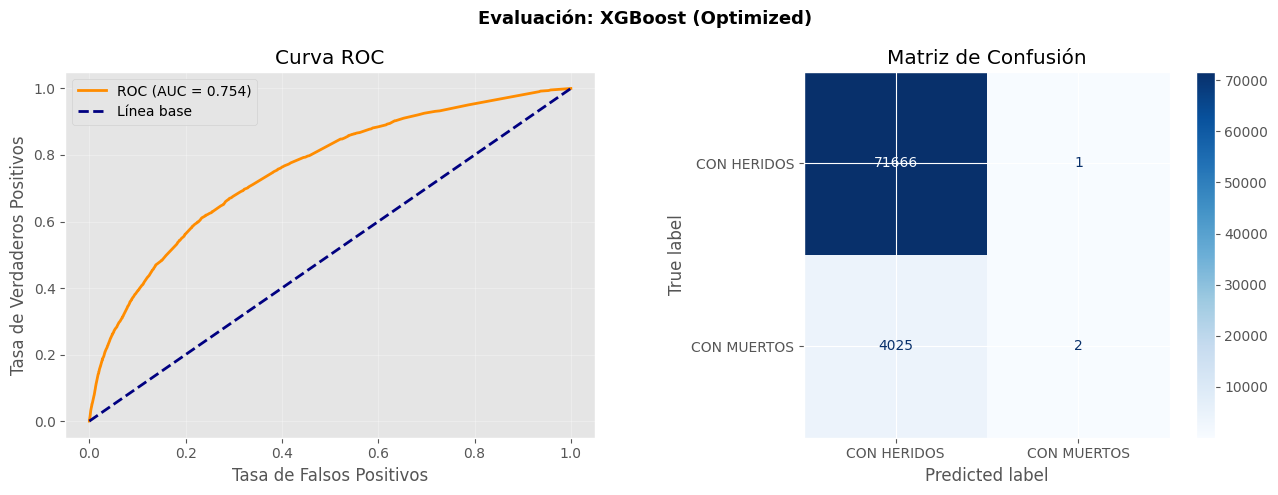

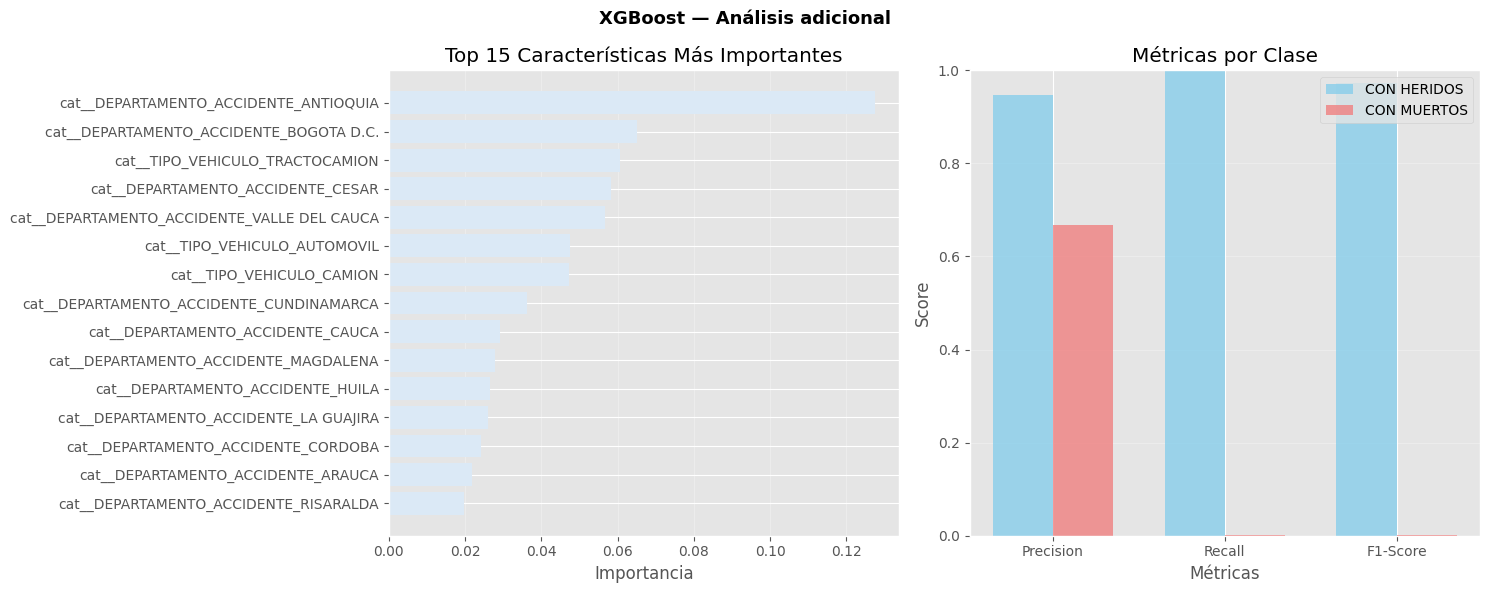


Top 10 características importantes:
                                        feature  importance
28        cat__DEPARTAMENTO_ACCIDENTE_ANTIOQUIA      0.1275
32      cat__DEPARTAMENTO_ACCIDENTE_BOGOTA D.C.      0.0651
25              cat__TIPO_VEHICULO_TRACTOCAMION      0.0606
39            cat__DEPARTAMENTO_ACCIDENTE_CESAR      0.0582
57  cat__DEPARTAMENTO_ACCIDENTE_VALLE DEL CAUCA      0.0567
1                  cat__TIPO_VEHICULO_AUTOMOVIL      0.0476
4                     cat__TIPO_VEHICULO_CAMION      0.0473
42     cat__DEPARTAMENTO_ACCIDENTE_CUNDINAMARCA      0.0363
38            cat__DEPARTAMENTO_ACCIDENTE_CAUCA      0.0292
47        cat__DEPARTAMENTO_ACCIDENTE_MAGDALENA      0.0279

Interpretabilidad con LIME - XGBoost

1. CASO CON MUERTOS correctamente clasificado


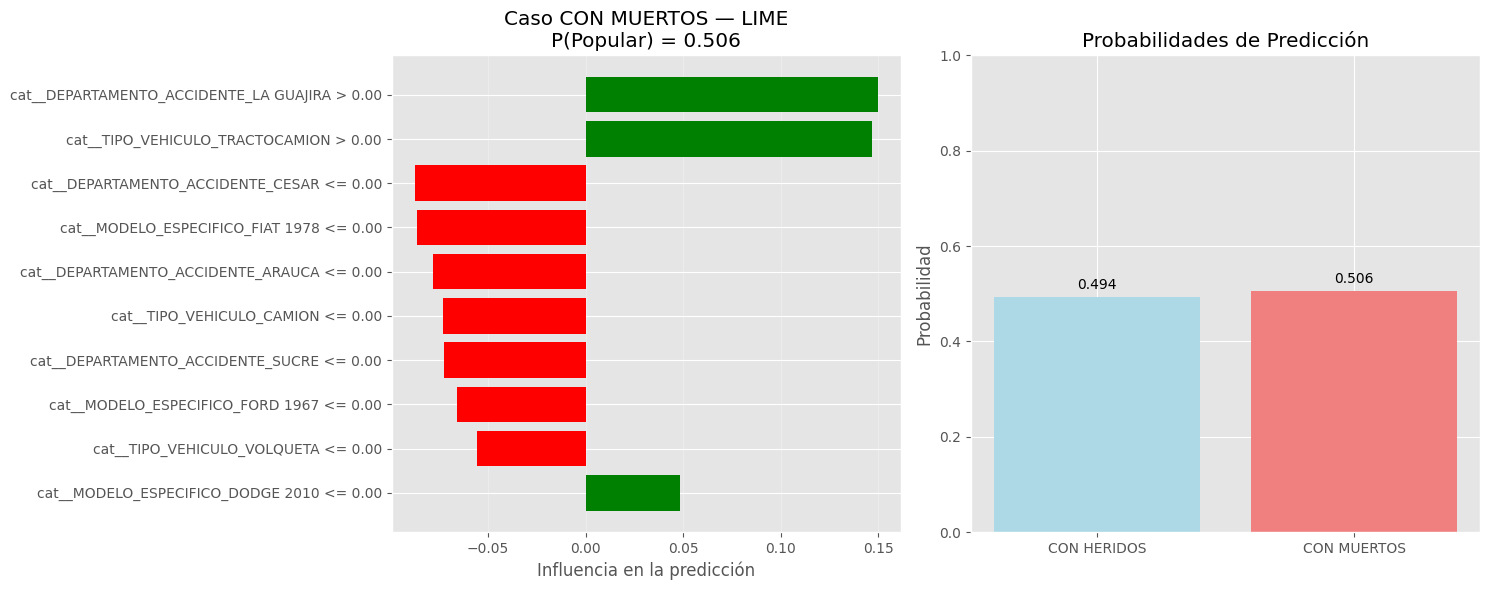


2. CASO CON HERIDOS correctamente clasificado


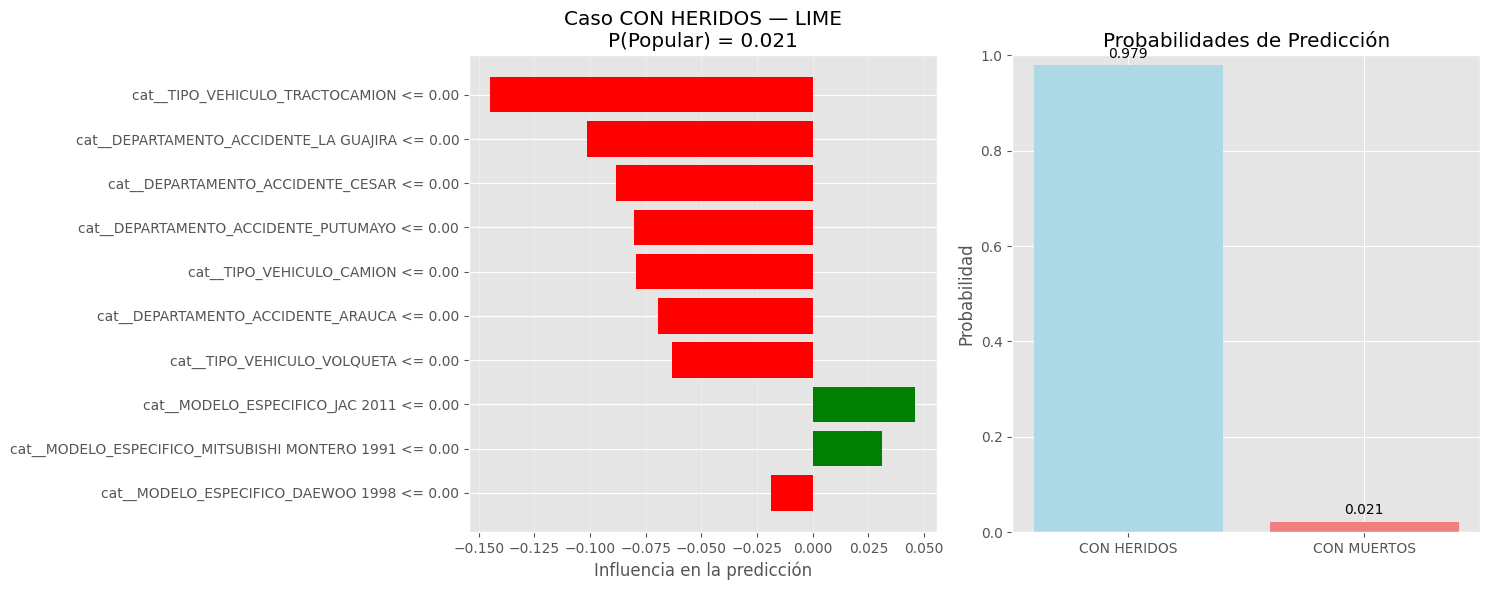

In [ ]:
import xgboost as xgb
import lime
import lime.lime_tabular

# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [3, 6],
    "model__learning_rate": [0.1, 0.01],
    "model__subsample":     [0.8, 0.9]
}

print("\nBúsqueda de hiperparámetros con GridSearchCV")
grid_search = GridSearchCV(
    pipe_xgb, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros:  {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV): {grid_search.best_score_:.4f}")

final_model = grid_search.best_estimator_

# ── EVALUACIÓN CON evaluate_model ─────────────────────────────────────────────
result = evaluate_model(
    final_model,
    X_train, X_test, y_train, y_test,
    model_name="XGBoost (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ← No re-entrenar, ya está optimizado y entrenado por GridSearchCV
)
results.append(result)

# ── GRÁFICAS ADICIONALES (importancia + métricas por clase) ───────────────────
y_pred       = result['predictions']
y_pred_proba = result['probabilities']
y_pred_proba_pos = y_pred_proba[:, 1] if y_pred_proba is not None else None

precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("XGBoost — Análisis adicional", fontsize=13, fontweight='bold')

# Importancia de características
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances   = final_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = importance_df.head(15)
ax3.barh(top_features['feature'], top_features['importance'])
ax3.set_xlabel('Importancia')
ax3.set_title('Top 15 Características Más Importantes')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Métricas por clase
x     = np.arange(3)
width = 0.35
ax4.bar(x - width/2, [precision_0, recall_0, f1_0], width, label=class_names[0], alpha=0.8, color='skyblue')
ax4.bar(x + width/2, [precision_1, recall_1, f1_1], width, label=class_names[1], alpha=0.8, color='lightcoral')
ax4.set_xlabel('Métricas')
ax4.set_ylabel('Score')
ax4.set_title('Métricas por Clase')
ax4.set_xticks(x)
ax4.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── LIME ──────────────────────────────────────────────────────────────────────
print("\nInterpretabilidad con LIME - XGBoost")

X_train_processed = final_model.named_steps['preprocessor'].transform(X_train)
X_test_processed  = final_model.named_steps['preprocessor'].transform(X_test)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)

predict_fn = lambda x: final_model.named_steps['model'].predict_proba(x)


def plot_lime_explanation(exp, title, probability):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    exp_as_list = exp.as_list()
    features = [x[0] for x in exp_as_list]
    scores   = [x[1] for x in exp_as_list]
    colors   = ['green' if s > 0 else 'red' for s in scores]

    ax1.barh(range(len(features)), scores, color=colors)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features)
    ax1.set_xlabel('Influencia en la predicción')
    ax1.set_title(f'{title}\nP(Popular) = {probability:.3f}')
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()

    prob_values = exp.predict_proba
    ax2.bar(class_names, prob_values, color=['lightblue', 'lightcoral'])
    ax2.set_ylabel('Probabilidad')
    ax2.set_title('Probabilidades de Predicción')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(prob_values):
        ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


if y_pred_proba_pos is not None:
    # Caso Popular correctamente clasificado
    idx_1 = np.where((y_test.values == 1) & (y_pred == 1))[0]
    if len(idx_1) > 0:
        i = idx_1[0]
        print(f"\n1. CASO {class_names[1]} correctamente clasificado")
        exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
        plot_lime_explanation(exp, f'Caso {class_names[1]} — LIME', y_pred_proba_pos[i])

    # Caso No Popular correctamente clasificado
    idx_0 = np.where((y_test.values == 0) & (y_pred == 0))[0]
    if len(idx_0) > 0:
        i = idx_0[0]
        print(f"\n2. CASO {class_names[0]} correctamente clasificado")
        exp = explainer.explain_instance(X_test_processed[i], predict_fn, num_features=10)
        plot_lime_explanation(exp, f'Caso {class_names[0]} — LIME', y_pred_proba_pos[i])

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores parámetros: {'model__C': 0.01, 'model__penalty': 'l1'}
Mejor F1-Macro (CV Grid): nan

VALIDACIÓN CRUZADA (5 folds) - Logistic Regression (Optimized)
   F1-Macro (CV):    0.5230 ± 0.0017  ← PRINCIPAL
   Accuracy (CV):    0.7338 ± 0.0026
   F1-Weighted (CV): 0.8064 ± 0.0018
   AUC (CV):         0.7554 ± 0.0027

   Gap Train-Val F1-Macro: 0.0001 Sin overfitting aparente

EVALUACIÓN EN TEST SET - Logistic Regression (Optimized)
   F1-Macro:        0.5244  ← PRINCIPAL
   Accuracy:        0.7367
   F1-Weighted:     0.8083
   Precision-Macro: 0.5484
   Recall-Macro:    0.6931
   AUC:             0.7545
   Tiempo entreno:  12.88s

   Reporte de clasificación:
              precision    recall  f1-score   support

 CON HERIDOS       0.97      0.74      0.84     71667
 CON MUERTOS       0.12      0.64      0.21      4027

    accuracy                           0.74     75694
   macro avg       0.55      0.69      0.52     75694

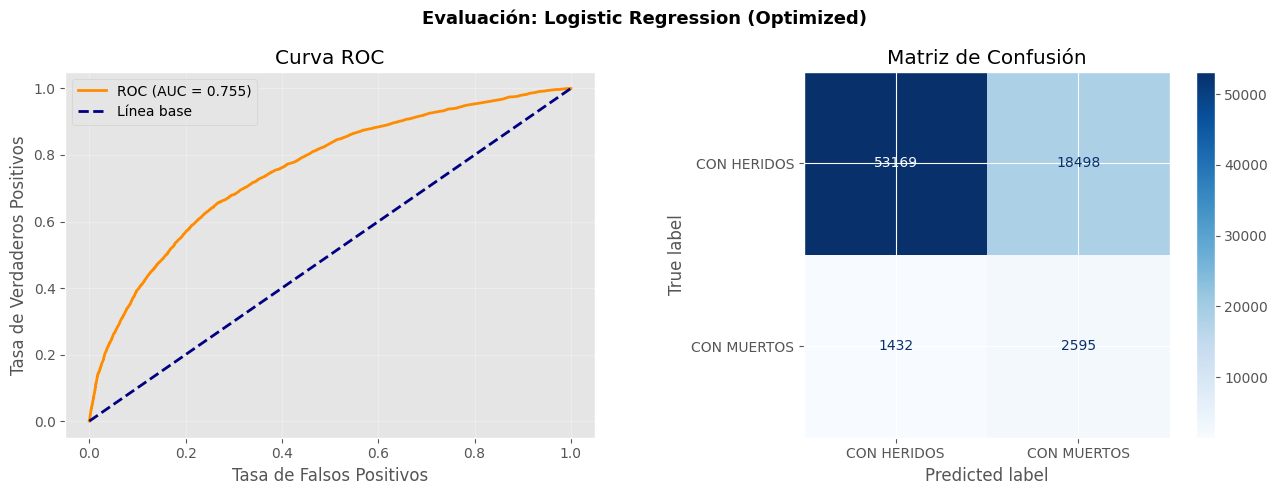


RESUMEN FINAL
                          Model  F1-Macro  Accuracy  F1-Weighted  Precision  Recall    AUC  Time(s)  CV_F1-Macro
            XGBoost (Optimized)    0.4868    0.9468       0.9210     0.8067  0.5002 0.7536  25.1068       0.4873
Logistic Regression (Optimized)    0.5244    0.7367       0.8083     0.5484  0.6931 0.7545  12.8783       0.5230


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='liblinear'
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__C":       [0.01, 0.1, 1, 10],
    "model__penalty": ['l1', 'l2']
}

grid_search = GridSearchCV(
    pipe_logreg, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMejores parámetros: {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV Grid): {grid_search.best_score_:.4f}")

# ── EVALUACIÓN ────────────────────────────────────────────────────────────────
result = evaluate_model(
    grid_search.best_estimator_,
    X_train, X_test, y_train, y_test,
    model_name="Logistic Regression (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ← No re-entrenar, ya está optimizado y entrenado por GridSearchCV
)
results.append(result)

# ── TABLA FINAL ───────────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':        r['model'],
    'F1-Macro':     r['f1_macro'],
    'Accuracy':     r['accuracy'],
    'F1-Weighted':  r['f1_weighted'],
    'Precision':    r['precision_macro'],
    'Recall':       r['recall_macro'],
    'AUC':          r['auc'],
    'Time(s)':      r['train_time'],
    'CV_F1-Macro':  r.get('cv_f1_macro_mean', None),
} for r in results])

print("\nRESUMEN FINAL")
print(results_df.round(4).to_string(index=False))

   X_train: (302776, 7), X_test: (75694, 7)
   y_train - Clase 0 (CON HERIDOS): 286666, Clase 1 (CON MUERTOS): 16110
   y_test  - Clase 0 (CON HERIDOS): 71667, Clase 1 (CON MUERTOS): 4027

Búsqueda de hiperparámetros con GridSearchCV
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores parámetros:  {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Mejor F1-Macro (CV): nan

VALIDACIÓN CRUZADA (5 folds) - Random Forest (Optimized)
   F1-Macro (CV):    0.5245 ± 0.0021  ← PRINCIPAL
   Accuracy (CV):    0.8989 ± 0.0009
   F1-Weighted (CV): 0.9016 ± 0.0006
   AUC (CV):         0.6471 ± 0.0056

   Gap Train-Val F1-Macro: 0.2833 Posible overfitting

EVALUACIÓN EN TEST SET - Random Forest (Optimized)
   F1-Macro:        0.5281  ← PRINCIPAL
   Accuracy:        0.8963
   F1-Weighted:     0.9006
   Precision-Macro: 0.5262
   Recall-Macro:    0.5309
   AUC:             0.6369
   Tiempo entreno:  154.12s

   Reporte de clasificación:
              

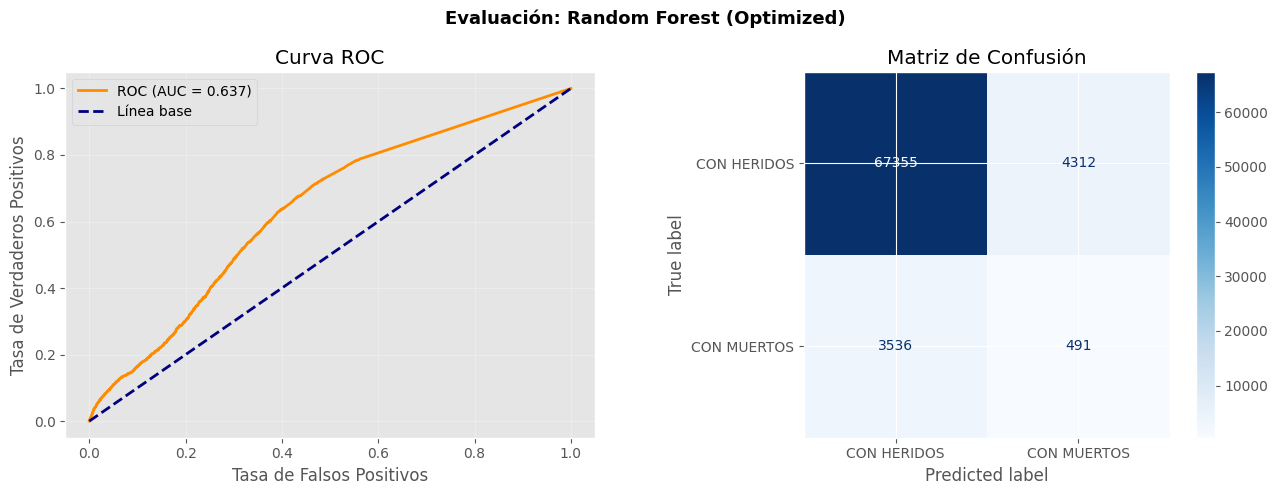

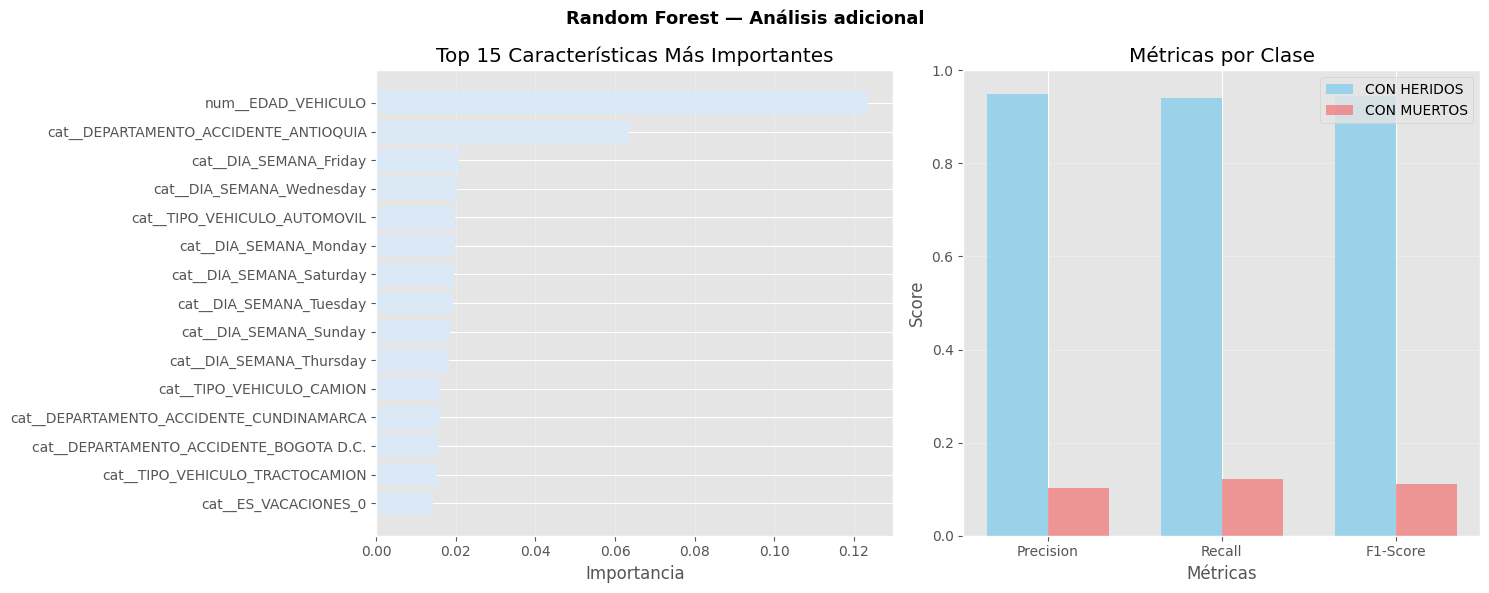


Top 10 características importantes:
                                  feature  importance
0                      num__EDAD_VEHICULO      0.1237
28  cat__DEPARTAMENTO_ACCIDENTE_ANTIOQUIA      0.0636
59                 cat__DIA_SEMANA_Friday      0.0208
65              cat__DIA_SEMANA_Wednesday      0.0202
1            cat__TIPO_VEHICULO_AUTOMOVIL      0.0199
60                 cat__DIA_SEMANA_Monday      0.0197
61               cat__DIA_SEMANA_Saturday      0.0196
64                cat__DIA_SEMANA_Tuesday      0.0193
62                 cat__DIA_SEMANA_Sunday      0.0184
63               cat__DIA_SEMANA_Thursday      0.0183

Análisis de overfitting:
   Gap Accuracy (Train-Val): 0.0485
   Gap F1-Macro (Train-Val): 0.2833
   Buena generalización

Resumen del modelo:
   Árboles:              100
   Características:      2914
   Profundidad promedio: 221.9
   Balanced Accuracy:    0.5309
   F1 CON HERIDOS:       0.9449
   F1 CON MUERTOS:       0.1112  ← clase crítica

RESUMEN FINAL — TODOS 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, balanced_accuracy_score
)

print(f"   X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"   y_train - Clase 0 (CON HERIDOS): {np.sum(y_train == 0)}, Clase 1 (CON MUERTOS): {np.sum(y_train == 1)}")
print(f"   y_test  - Clase 0 (CON HERIDOS): {np.sum(y_test == 0)}, Clase 1 (CON MUERTOS): {np.sum(y_test == 1)}")

# ── PIPELINE ──────────────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1,
        class_weight='balanced'  # importante por desbalanceo de clases
    ))
])

# ── GRID SEARCH ───────────────────────────────────────────────────────────────
param_grid = {
    "model__n_estimators":  [100, 200],
    "model__max_depth":     [None, 10, 20],
    "model__min_samples_split": [2, 5],
}

print("\nBúsqueda de hiperparámetros con GridSearchCV")
grid_search = GridSearchCV(
    pipe_rf, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Mejores parámetros:  {grid_search.best_params_}")
print(f"Mejor F1-Macro (CV): {grid_search.best_score_:.4f}")

final_model_rf = grid_search.best_estimator_

# ── EVALUACIÓN CON evaluate_model ─────────────────────────────────────────────
result_rf = evaluate_model(
    final_model_rf,
    X_train, X_test, y_train, y_test,
    model_name="Random Forest (Optimized)",
    cv_folds=5,
    make_plots=True,
    refit=True  # ya fue entrenado por GridSearch
)
results.append(result_rf)

# ── GRÁFICAS ADICIONALES ──────────────────────────────────────────────────────
y_pred       = result_rf['predictions']
y_pred_proba = result_rf['probabilities']

precision_0 = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
precision_1 = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall_0    = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
recall_1    = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1_0        = f1_score(y_test, y_pred, pos_label=0, zero_division=0)
f1_1        = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Random Forest — Análisis adicional", fontsize=13, fontweight='bold')

# Importancia de características
feature_names = final_model_rf.named_steps['preprocessor'].get_feature_names_out()
importances   = final_model_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

top_features = importance_df.head(15)
ax3.barh(top_features['feature'], top_features['importance'])
ax3.set_xlabel('Importancia')
ax3.set_title('Top 15 Características Más Importantes')
ax3.grid(axis='x', alpha=0.3)
ax3.invert_yaxis()

# Métricas por clase
x     = np.arange(3)
width = 0.35
ax4.bar(x - width/2, [precision_0, recall_0, f1_0], width, label='CON HERIDOS', alpha=0.8, color='skyblue')
ax4.bar(x + width/2, [precision_1, recall_1, f1_1], width, label='CON MUERTOS', alpha=0.8, color='lightcoral')
ax4.set_xlabel('Métricas')
ax4.set_ylabel('Score')
ax4.set_title('Métricas por Clase')
ax4.set_xticks(x)
ax4.set_xticklabels(['Precision', 'Recall', 'F1-Score'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nTop 10 características importantes:")
print(importance_df.head(10).round(4))

# ── ANÁLISIS DE OVERFITTING ───────────────────────────────────────────────────
gap_acc = result_rf.get('cv_train_accuracy_mean', 0) - result_rf.get('cv_accuracy_mean', 0)
gap_f1  = result_rf.get('cv_train_f1_macro_mean', 0) - result_rf.get('cv_f1_macro_mean', 0)

print(f"\nAnálisis de overfitting:")
print(f"   Gap Accuracy (Train-Val): {gap_acc:.4f}")
print(f"   Gap F1-Macro (Train-Val): {gap_f1:.4f}")

if gap_acc > 0.1:
    print("   ALTO OVERFITTING — reducir n_estimators o aumentar min_samples_split")
elif gap_acc > 0.05:
    print("   Overfitting moderado — considerar ajustar hiperparámetros")
else:
    print("   Buena generalización")

# ── RESUMEN FINAL ─────────────────────────────────────────────────────────────
rf_model = final_model_rf.named_steps['model']
print(f"\nResumen del modelo:")
print(f"   Árboles:              {rf_model.n_estimators}")
print(f"   Características:      {rf_model.n_features_in_}")
print(f"   Profundidad promedio: {np.mean([t.get_depth() for t in rf_model.estimators_]):.1f}")
print(f"   Balanced Accuracy:    {balanced_acc:.4f}")
print(f"   F1 CON HERIDOS:       {f1_0:.4f}")
print(f"   F1 CON MUERTOS:       {f1_1:.4f}  ← clase crítica")

# ── TABLA COMPARATIVA ─────────────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':       r['model'],
    'F1-Macro':    r['f1_macro'],
    'Accuracy':    r['accuracy'],
    'F1-Weighted': r['f1_weighted'],
    'Precision':   r['precision_macro'],
    'Recall':      r['recall_macro'],
    'AUC':         r['auc'],
    'Time(s)':     r['train_time'],
    'CV_F1-Macro': r.get('cv_f1_macro_mean', None),
} for r in results])

print("\nRESUMEN FINAL — TODOS LOS MODELOS")
print(results_df.round(4).to_string(index=False))

if len(results_df) > 1:
    best = results_df.sort_values('F1-Macro', ascending=False).iloc[0]
    rf_pos = results_df.sort_values('F1-Macro', ascending=False) \
                       .reset_index(drop=True) \
                       .query("Model == 'Random Forest (Optimized)'").index[0] + 1
    print(f"\nMejor modelo:  {best['Model']}  (F1-Macro: {best['F1-Macro']:.4f})")
    print(f"Random Forest: posición #{rf_pos} de {len(results_df)} modelos")

In [86]:
from pytorch_tabnet.tab_model import TabNetClassifier
print("TabNet instalado correctamente")

TabNet instalado correctamente



ENTRENANDO TABNET CON EARLY STOPPING (F1-MACRO)...
epoch 0  | loss: 0.71693 | valid_f1_macro: 0.37242 |  0:03:31s
epoch 1  | loss: 0.67852 | valid_f1_macro: 0.48158 |  0:07:06s
epoch 2  | loss: 0.60517 | valid_f1_macro: 0.52007 |  0:10:49s
epoch 3  | loss: 0.57711 | valid_f1_macro: 0.53317 |  0:14:27s
epoch 4  | loss: 0.56631 | valid_f1_macro: 0.53053 |  0:18:12s
epoch 5  | loss: 0.55597 | valid_f1_macro: 0.52816 |  0:21:40s
epoch 6  | loss: 0.55188 | valid_f1_macro: 0.52013 |  0:25:10s
epoch 7  | loss: 0.54246 | valid_f1_macro: 0.51272 |  0:28:41s
epoch 8  | loss: 0.53134 | valid_f1_macro: 0.51574 |  0:32:12s
epoch 9  | loss: 0.51833 | valid_f1_macro: 0.50016 |  0:35:26s
epoch 10 | loss: 0.50583 | valid_f1_macro: 0.50107 |  0:38:16s
epoch 11 | loss: 0.49425 | valid_f1_macro: 0.50585 |  0:41:07s
epoch 12 | loss: 0.48032 | valid_f1_macro: 0.50799 |  0:43:57s
epoch 13 | loss: 0.47222 | valid_f1_macro: 0.50007 |  0:46:48s
epoch 14 | loss: 0.46396 | valid_f1_macro: 0.50932 |  0:49:39s
epo

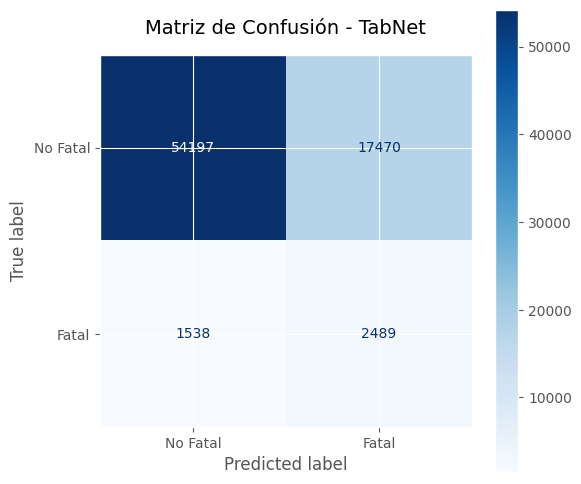


RESUMEN FINAL — TODOS LOS MODELOS
 Model  F1-Macro  Accuracy  F1-Weighted  Precision  Recall    AUC CV_F1-Macro
TabNet    0.5095    0.7105       0.7901     0.5443  0.6872 0.7477         N/A
TabNet    0.5292    0.7489       0.8166     0.5486  0.6872 0.7494     0.52917


In [88]:
# ==============================================================================
# IMPLEMENTACIÓN DE TABNET Y RESUMEN FINAL (CORREGIDO)
# ==============================================================================

from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.metrics import Metric
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_auc_score, confusion_matrix, 
                             ConfusionMatrixDisplay)

# 1. Definir la métrica F1-Macro personalizada para el Early Stopping de TabNet
class F1Macro(Metric):
    def __init__(self):
        self._name = "f1_macro"
        self._maximize = True

    def __call__(self, y_true, y_score):
        y_pred = np.argmax(y_score, axis=1)
        return f1_score(y_true, y_pred, average='macro', zero_division=0)

# 2. Transformar los datos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Separar validación para Early Stopping
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# 3. Configurar TabNet (Ajustado para evitar sobreajuste)
tabnet_model = TabNetClassifier(
    n_d=8, n_a=8, n_steps=4,             # Reducido para evitar memorización
    gamma=1.3,
    lambda_sparse=1e-3,                  # Penalización para ignorar variables ruidosas
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=1e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax',
    device_name='auto',
    seed=42,
    verbose=1
)

# 4. Entrenar el modelo
print(f"\n{'='*60}")
print("ENTRENANDO TABNET CON EARLY STOPPING (F1-MACRO)...")
print(f"{'='*60}")

start_time = time.time()
tabnet_model.fit(
    X_train=X_train_sub, 
    y_train=y_train_sub.values,
    eval_set=[(X_val, y_val.values)],
    eval_name=['valid'],
    eval_metric=[F1Macro],               # <--- Aplicando la métrica personalizada
    max_epochs=100,
    patience=15,
    batch_size=2048,                     # Batch más grande para mayor velocidad
    virtual_batch_size=256,
    weights=1,                           # Balanceo automático de clases
    drop_last=False
)
train_time = time.time() - start_time

# 5. Evaluación final en el Test Set
y_pred = tabnet_model.predict(X_test_prep)
y_pred_proba = tabnet_model.predict_proba(X_test_prep)

accuracy        = accuracy_score(y_test, y_pred)
f1_macro        = f1_score(y_test, y_pred, average='macro', zero_division=0)
f1_weighted     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_test, y_pred, average='macro', zero_division=0)
auc_score       = roc_auc_score(y_test, y_pred_proba[:, 1])

print(f"\n{'='*60}")
print("RESULTADOS TEST SET - TabNet")
print(f"{'='*60}")
print(f"   F1-Macro:        {f1_macro:.4f}")
print(f"   Accuracy:        {accuracy:.4f}")
print(f"   F1-Weighted:     {f1_weighted:.4f}")
print(f"   Precision-Macro: {precision_macro:.4f}")
print(f"   Recall-Macro:    {recall_macro:.4f}")
print(f"   AUC:             {auc_score:.4f}")
print(f"   Tiempo entreno:  {train_time:.2f}s")

# 6. DIBUJAR MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fatal', 'Fatal']) 
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - TabNet', fontsize=14, pad=15)
plt.show()

# 7. Agregar a la lista de 'results' general
result_tabnet = {
    'model':           'TabNet',
    'accuracy':        accuracy,
    'f1_macro':        f1_macro,
    'f1_weighted':     f1_weighted,
    'precision_macro': precision_macro,
    'recall_macro':    recall_macro,
    'auc':             auc_score,
    'train_time':      train_time,
    'cv_f1_macro_mean': f1_macro # <--- Usamos el test F1 en lugar de 'N/A' para no romper la tabla
}

results.append(result_tabnet)

# ── TABLA COMPARATIVA FINAL ───────────────────────────────────────────────────
results_df = pd.DataFrame([{
    'Model':       r['model'],
    'F1-Macro':    r['f1_macro'],
    'Accuracy':    r['accuracy'],
    'F1-Weighted': r['f1_weighted'],
    'Precision':   r['precision_macro'],
    'Recall':      r['recall_macro'],
    'AUC':         r['auc'],
    'CV_F1-Macro': r.get('cv_f1_macro_mean', 0.0),
} for r in results])

print("\nRESUMEN FINAL — TODOS LOS MODELOS")
print(results_df.round(4).to_string(index=False))